# Predicting Crop Yield and Revenue for Data-Driven Agricultural Planning in Canada

## Project Overview

Canadian agricultural producers must make planting decisions before knowing exactly how much a crop will yield or what price it will receive after harvest. Yield varies with crop type, geography, climate, and long-term agricultural trends, while crop prices fluctuate over time due to changing market conditions.

This project develops a two-stage machine learning decision-support system:

1. Predict **crop yield (kg/hectare)** using historical agricultural and climate information.
2. Predict **average farm price ($/tonne)** using historical price information and other variables available before the prediction year.
3. Combine the two predictions to estimate **expected gross revenue per hectare**.
4. Evaluate historical variability to provide a measure of **risk** alongside expected revenue.

The intended stakeholder is a Canadian agricultural producer or farm manager making crop-selection and land-allocation decisions.

The project focuses on **gross revenue rather than profit** because crop-specific production-cost data such as labor, fertilizer, seed, fuel, machinery, and transportation are not available.

## Analytical Objectives

The analysis will address the following questions:

- How accurately can historical agricultural and climate data predict crop yield?
- How accurately can historical information predict average farm price?
- How do yield and price change over time for different crops?
- What relationship exists between historical yield and price?
- Can predicted yield and price be combined to produce useful estimates of gross revenue per hectare?
- How does expected revenue compare with historical risk across crops?
- Which variables contribute most strongly to yield and price predictions?

### Modeling Targets

**Yield Model**
- Target: Average yield (kg/hectare)

**Price Model**
- Target: Average farm price ($/tonne)
- Historical prices will be evaluated for inflation effects before the final target representation is selected.

**Combined Business Metric**

Expected gross revenue per hectare will be calculated from predicted yield and predicted price after converting yield from kilograms to metric tonnes per hectare.

## Methodological Considerations

Several issues identified during project planning will be explicitly evaluated during the analysis:

1. **Inflation:** Historical farm prices may be converted to constant dollars using Canadian CPI data. Alternatively, price changes may be modeled if this provides a more appropriate forecasting target.

2. **Yield Trend:** Agricultural yields may contain a strong long-term technological/productivity trend. The analysis will test whether candidate models can capture this trend under chronological validation. If necessary, yield will be modeled relative to an estimated historical trend.

3. **Yield–Price Dependence:** Historical correlation between yield and price will be examined by crop before combining separate yield and price predictions into expected revenue.

4. **Risk:** Risk will be defined quantitatively and calculated using detrended historical data so that long-term growth does not incorrectly appear as volatility.

5. **Crop-Level Evaluation:** Prediction errors will be reported separately by crop in addition to overall metrics so that crops with larger yield scales do not dominate model evaluation.

6. **Temporal Validation:** Training and evaluation will preserve chronological order so that future observations are never used to predict the past.

7. **Data Leakage:** Variables that contain information unavailable at planting time, particularly realized production and total farm value, will not be used as predictors when doing so would leak information about the target.

In [1]:
# ============================================================
# Imports and Project Configuration
# ============================================================

# Core data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Project environment initialized.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Project environment initialized.
Pandas version: 3.0.5
NumPy version: 2.4.6


In [2]:
DATA_DIR = Path("data")

FARM_DATA_PATH = DATA_DIR / "farm_production_dataset.csv"
CLIMATE_DATA_PATH = DATA_DIR / "Canadian_climate_history.csv"
CPI_DATA_PATH = DATA_DIR / "canadian_cpi.csv"

farm_df = pd.read_csv(FARM_DATA_PATH)
climate_df = pd.read_csv(CLIMATE_DATA_PATH)
cpi_df = pd.read_csv(CPI_DATA_PATH)

In [3]:
# ============================================================
# Environment Verification
# ============================================================

import sklearn
import scipy
import sys

environment_info = pd.DataFrame({
    "Package": [
        "Python",
        "Pandas",
        "NumPy",
        "SciPy",
        "scikit-learn"
    ],
    "Version": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        scipy.__version__,
        sklearn.__version__
    ]
})

environment_info

,Package,Version
0,Python,3.13.14
1,Pandas,3.0.5
2,NumPy,2.4.6
3,SciPy,1.18.0
4,scikit-learn,1.9.0


# 2. Initial Data Audit

Before preprocessing or feature engineering, both datasets are examined to understand their structure, coverage, completeness, and potential data-quality issues.

This section evaluates:

- Dataset dimensions and column structure
- Data types
- Example observations
- Missing values
- Duplicate records
- Agricultural crop, province, and year coverage
- Climate location and year coverage
- Numerical summary statistics
- Potential data-quality concerns

No observations are removed or modified during this stage. Findings from the audit will guide subsequent cleaning and preprocessing decisions.

In [4]:
# ============================================================
# Dataset Dimensions
# ============================================================

print("FARM DATASET")
print(f"Rows:    {farm_df.shape[0]:,}")
print(f"Columns: {farm_df.shape[1]}")

print("\nCLIMATE DATASET")
print(f"Rows:    {climate_df.shape[0]:,}")
print(f"Columns: {climate_df.shape[1]}")

FARM DATASET
Rows:    10,273
Columns: 9

CLIMATE DATASET
Rows:    29,221
Columns: 27


In [5]:
# ============================================================
# Column Structure
# ============================================================

print("FARM DATASET COLUMNS")
for i, column in enumerate(farm_df.columns, start=1):
    print(f"{i:>2}. {column}")

print("\nCLIMATE DATASET COLUMNS")
for i, column in enumerate(climate_df.columns, start=1):
    print(f"{i:>2}. {column}")

FARM DATASET COLUMNS
 1. REF_DATE
 2. GEO
 3. Type of crop
 4. Average farm price (dollars per tonne)
 5. Average yield (kilograms per hectare)
 6. Production (metric tonnes)
 7. Seeded area (acres)
 8. Seeded area (hectares)
 9. Total farm value (dollars)

CLIMATE DATASET COLUMNS
 1. LOCAL_DATE
 2. MEAN_TEMPERATURE_CALGARY
 3. TOTAL_PRECIPITATION_CALGARY
 4. MEAN_TEMPERATURE_EDMONTON
 5. TOTAL_PRECIPITATION_EDMONTON
 6. MEAN_TEMPERATURE_HALIFAX
 7. TOTAL_PRECIPITATION_HALIFAX
 8. MEAN_TEMPERATURE_MONCTON
 9. TOTAL_PRECIPITATION_MONCTON
10. MEAN_TEMPERATURE_MONTREAL
11. TOTAL_PRECIPITATION_MONTREAL
12. MEAN_TEMPERATURE_OTTAWA
13. TOTAL_PRECIPITATION_OTTAWA
14. MEAN_TEMPERATURE_QUEBEC
15. TOTAL_PRECIPITATION_QUEBEC
16. MEAN_TEMPERATURE_SASKATOON
17. TOTAL_PRECIPITATION_SASKATOON
18. MEAN_TEMPERATURE_STJOHNS
19. TOTAL_PRECIPITATION_STJOHNS
20. MEAN_TEMPERATURE_TORONTO
21. TOTAL_PRECIPITATION_TORONTO
22. MEAN_TEMPERATURE_VANCOUVER
23. TOTAL_PRECIPITATION_VANCOUVER
24. MEAN_TEMPERATURE_WHI

In [6]:
# ============================================================
# Sample Observations
# ============================================================

display(farm_df.head())
display(climate_df.head())

,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
0,1908,AB,Barley,15.00,1585.0,84000.0,129800.0,53000.0,1296
1,1908,AB,Flaxseed,29.00,950.0,1900.0,5900.0,2000.0,56
2,1908,AB,Oats,18.00,1675.0,352000.0,519400.0,210000.0,6316
3,1908,AB,"Rye, all",23.00,1665.0,5000.0,6500.0,3000.0,117
4,1908,AB,Sugar beets,0.55,18100.0,38100.0,5200.0,2100.0,208


,LOCAL_DATE,MEAN_TEMPERATURE_CALGARY,TOTAL_PRECIPITATION_CALGARY,MEAN_TEMPERATURE_EDMONTON,TOTAL_PRECIPITATION_EDMONTON,MEAN_TEMPERATURE_HALIFAX,TOTAL_PRECIPITATION_HALIFAX,MEAN_TEMPERATURE_MONCTON,TOTAL_PRECIPITATION_MONCTON,MEAN_TEMPERATURE_MONTREAL,TOTAL_PRECIPITATION_MONTREAL,MEAN_TEMPERATURE_OTTAWA,TOTAL_PRECIPITATION_OTTAWA,MEAN_TEMPERATURE_QUEBEC,TOTAL_PRECIPITATION_QUEBEC,MEAN_TEMPERATURE_SASKATOON,TOTAL_PRECIPITATION_SASKATOON,MEAN_TEMPERATURE_STJOHNS,TOTAL_PRECIPITATION_STJOHNS,MEAN_TEMPERATURE_TORONTO,TOTAL_PRECIPITATION_TORONTO,MEAN_TEMPERATURE_VANCOUVER,TOTAL_PRECIPITATION_VANCOUVER,MEAN_TEMPERATURE_WHITEHORSE,TOTAL_PRECIPITATION_WHITEHORSE,MEAN_TEMPERATURE_WINNIPEG,TOTAL_PRECIPITATION_WINNIPEG
0,01-Jan-1940 00:00:00,-11.4,0.5,NaN,NaN,NaN,NaN,-8.9,0.0,NaN,NaN,-17.0,0.0,NaN,NaN,-25.6,0.0,NaN,NaN,-8.9,0.0,8.9,5.8,NaN,NaN,-20.9,0.0
1,02-Jan-1940 00:00:00,-12.0,0.5,NaN,NaN,NaN,NaN,-14.5,0.0,NaN,NaN,-16.7,0.5,NaN,NaN,-20.9,0.0,NaN,NaN,-13.1,0.3,9.7,7.1,NaN,NaN,-18.4,0.0
2,03-Jan-1940 00:00:00,-12.0,1.0,NaN,NaN,NaN,NaN,-11.1,0.0,NaN,NaN,-12.3,0.0,NaN,NaN,-26.4,0.0,NaN,NaN,-6.1,0.0,7.8,1.0,NaN,NaN,-22.0,0.0
3,04-Jan-1940 00:00:00,-11.4,0.8,NaN,NaN,NaN,NaN,-11.1,0.3,NaN,NaN,-16.4,0.0,NaN,NaN,-32.5,0.0,NaN,NaN,-6.4,0.5,8.1,0.5,NaN,NaN,-20.3,0.0
4,05-Jan-1940 00:00:00,-13.1,0.5,NaN,NaN,NaN,NaN,-8.1,0.0,NaN,NaN,-19.5,0.0,NaN,NaN,-26.2,0.0,NaN,NaN,-7.2,16.5,7.0,0.8,NaN,NaN,-18.7,0.0


In [7]:
# ============================================================
# Data Types
# ============================================================

farm_types = pd.DataFrame({
    "column": farm_df.columns,
    "dtype": farm_df.dtypes.astype(str).values
})

climate_types = pd.DataFrame({
    "column": climate_df.columns,
    "dtype": climate_df.dtypes.astype(str).values
})

print("Farm data types:")
display(farm_types)

print("Climate data types:")
display(climate_types)

Farm data types:


,column,dtype
0,REF_DATE,int64
1,GEO,str
2,Type of crop,str
3,Average farm price (dollars per tonne),float64
4,Average yield (kilograms per hectare),float64
5,Production (metric tonnes),float64
6,Seeded area (acres),float64
7,Seeded area (hectares),float64
8,Total farm value (dollars),int64


Climate data types:


,column,dtype
0,LOCAL_DATE,str
1,MEAN_TEMPERATURE_CALGARY,float64
2,TOTAL_PRECIPITATION_CALGARY,float64
3,MEAN_TEMPERATURE_EDMONTON,float64
4,TOTAL_PRECIPITATION_EDMONTON,float64
5,MEAN_TEMPERATURE_HALIFAX,float64
6,TOTAL_PRECIPITATION_HALIFAX,float64
7,MEAN_TEMPERATURE_MONCTON,float64
8,TOTAL_PRECIPITATION_MONCTON,float64
9,MEAN_TEMPERATURE_MONTREAL,float64


In [8]:
# ============================================================
# Missing-Value Audit
# ============================================================

def missing_value_summary(df):
    """
    Return a summary of missing values for each column.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset to evaluate.

    Returns
    -------
    pandas.DataFrame
        Column name, missing count, and missing percentage,
        sorted from highest to lowest missingness.
    """
    summary = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean().values * 100)
    })

    return (
        summary
        .sort_values("missing_percent", ascending=False)
        .reset_index(drop=True)
    )


farm_missing = missing_value_summary(farm_df)
climate_missing = missing_value_summary(climate_df)

print("Farm missing values:")
display(farm_missing)

print("Climate missing values:")
display(climate_missing)

Farm missing values:


,column,missing_count,missing_percent
0,Seeded area (hectares),426,4.146793
1,Seeded area (acres),400,3.893702
2,Average farm price (dollars per tonne),30,0.292028
3,Production (metric tonnes),28,0.272559
4,Average yield (kilograms per hectare),27,0.262825
5,Type of crop,1,0.009734
6,REF_DATE,0,0.000000
7,GEO,0,0.000000
8,Total farm value (dollars),0,0.000000


Climate missing values:


,column,missing_count,missing_percent
0,MEAN_TEMPERATURE_EDMONTON,7657,26.203758
1,TOTAL_PRECIPITATION_EDMONTON,7646,26.166113
2,TOTAL_PRECIPITATION_HALIFAX,7226,24.728791
3,MEAN_TEMPERATURE_HALIFAX,7164,24.516615
4,TOTAL_PRECIPITATION_WHITEHORSE,4095,14.013894
5,TOTAL_PRECIPITATION_SASKATOON,3755,12.850347
6,TOTAL_PRECIPITATION_MONCTON,2767,9.469217
7,MEAN_TEMPERATURE_SASKATOON,2473,8.463092
8,MEAN_TEMPERATURE_MONCTON,2336,7.994251
9,MEAN_TEMPERATURE_WHITEHORSE,1691,5.786934


In [9]:
# ============================================================
# Duplicate Records
# ============================================================

farm_duplicates = farm_df.duplicated().sum()
climate_duplicates = climate_df.duplicated().sum()

print(f"Farm duplicate rows:    {farm_duplicates:,}")
print(f"Climate duplicate rows: {climate_duplicates:,}")

Farm duplicate rows:    9
Climate duplicate rows: 0


In [10]:
# ============================================================
# Numerical Summary Statistics
# ============================================================

print("FARM DATASET")
display(farm_df.describe().T)

print("CLIMATE DATASET")
display(climate_df.describe().T)

FARM DATASET


,count,mean,std,min,25%,50%,75%,max
REF_DATE,10273.0,1.947661e+03,2.220452e+01,1908.0,1929.0,1948.0,1967.00,1984.0
Average farm price (dollars per tonne),10243.0,5.963308e+01,9.092055e+01,0.0,21.0,43.0,76.00,6663.3
Average yield (kilograms per hectare),10246.0,3.647442e+03,8.068855e+03,0.0,1055.0,1485.0,2363.75,460305.0
Production (metric tonnes),10245.0,1.010887e+06,3.044681e+06,0.0,8300.0,71950.0,548000.00,133678950.0
Seeded area (acres),9873.0,1.310067e+06,4.881387e+06,0.0,10500.0,83000.0,583100.00,317203482.0
Seeded area (hectares),9847.0,5.316231e+05,1.978043e+06,0.0,4350.0,34000.0,238900.00,128389050.0
Total farm value (dollars),10273.0,5.490084e+04,2.502413e+05,0.0,369.0,3006.0,19541.00,4654194.0


CLIMATE DATASET


,count,mean,std,min,25%,50%,75%,max
MEAN_TEMPERATURE_CALGARY,29032.0,4.038516,11.006215,-37.5,-2.5,5.3,12.900,26.2
TOTAL_PRECIPITATION_CALGARY,29048.0,1.180212,3.846286,0.0,0.0,0.0,0.500,92.6
MEAN_TEMPERATURE_EDMONTON,21564.0,2.311584,12.285520,-40.8,-5.8,4.2,12.600,24.7
TOTAL_PRECIPITATION_EDMONTON,21575.0,1.246239,3.887939,0.0,0.0,0.0,0.600,75.6
MEAN_TEMPERATURE_HALIFAX,22057.0,6.565997,9.627004,-23.5,-0.7,7.0,14.800,27.0
TOTAL_PRECIPITATION_HALIFAX,21995.0,3.976417,9.251793,0.0,0.0,0.0,3.000,218.2
MEAN_TEMPERATURE_MONCTON,26885.0,5.311854,10.550237,-27.4,-2.5,5.8,14.400,27.2
TOTAL_PRECIPITATION_MONCTON,26454.0,3.206377,7.338255,0.0,0.0,0.0,2.675,131.8
MEAN_TEMPERATURE_MONTREAL,28466.0,6.675386,11.940761,-30.9,-2.3,7.5,17.000,30.3
TOTAL_PRECIPITATION_MONTREAL,28491.0,2.656070,6.096109,0.0,0.0,0.0,2.200,93.5


### Initial Data Audit Findings

The agricultural dataset contains 10,273 observations and 9 variables, while the climate dataset contains 29,221 daily observations and 27 variables.

The agricultural data are relatively complete. Missingness in the primary prediction targets is low, with less than 0.3% of observations missing either average yield or average farm price. Seeded-area variables contain approximately 4% missing values and will require further investigation before determining whether they should be retained as predictors.

Climate-data completeness varies substantially by location. Several locations have relatively complete historical records, while Edmonton and Halifax have approximately one-quarter of their daily temperature and precipitation observations missing. Because missingness may be concentrated in particular historical periods, climate observations will not be removed solely on the basis of daily missing values. Coverage will first be evaluated by location and year.

Nine exact duplicate rows were identified in the agricultural dataset and will be investigated before removal.

The agricultural variables also operate on substantially different scales across crops. Extreme yield and price values will therefore be evaluated within crop rather than automatically classified as outliers based on the pooled dataset.

In [11]:
# ============================================================
# Investigate Duplicate Agricultural Records
# ============================================================

farm_duplicate_rows = (
    farm_df[farm_df.duplicated(keep=False)]
    .sort_values(["REF_DATE", "GEO", "Type of crop"])
)

print(f"Rows involved in exact duplicate groups: {len(farm_duplicate_rows):,}")
display(farm_duplicate_rows)

Rows involved in exact duplicate groups: 18


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
5830,1954,AB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
5969,1954,AB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
5840,1954,AB,Sunflower seed,0.0,0.0,0.0,0.0,0.0,0
5979,1954,AB,Sunflower seed,0.0,0.0,0.0,0.0,0.0,0
5895,1954,NB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
6034,1954,NB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
5901,1954,NS,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
6040,1954,NS,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
5904,1954,NS,"Rye, all",0.0,0.0,0.0,0.0,0.0,0
6043,1954,NS,"Rye, all",0.0,0.0,0.0,0.0,0.0,0


In [12]:
# ============================================================
# Investigate Missing Crop Classification
# ============================================================

missing_crop_rows = farm_df[farm_df["Type of crop"].isna()]

print(f"Rows with missing crop type: {len(missing_crop_rows):,}")
display(missing_crop_rows)

Rows with missing crop type: 1


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
5966,1954,SK,NaN,6663.3,460305.0,133678950.0,317203482.0,128389050.0,3311439


In [13]:
# ============================================================
# Agricultural Historical Coverage
# ============================================================

print(f"Earliest farm year: {farm_df['REF_DATE'].min()}")
print(f"Latest farm year:   {farm_df['REF_DATE'].max()}")
print(f"Number of years:    {farm_df['REF_DATE'].nunique()}")

records_by_year = (
    farm_df.groupby("REF_DATE")
    .size()
    .rename("records")
    .reset_index()
)

display(records_by_year)

Earliest farm year: 1908
Latest farm year:   1984
Number of years:    76


,REF_DATE,records
0,1908,102
1,1909,102
2,1910,120
3,1911,120
4,1912,120
5,1913,120
6,1914,120
7,1915,120
8,1916,120
9,1917,120


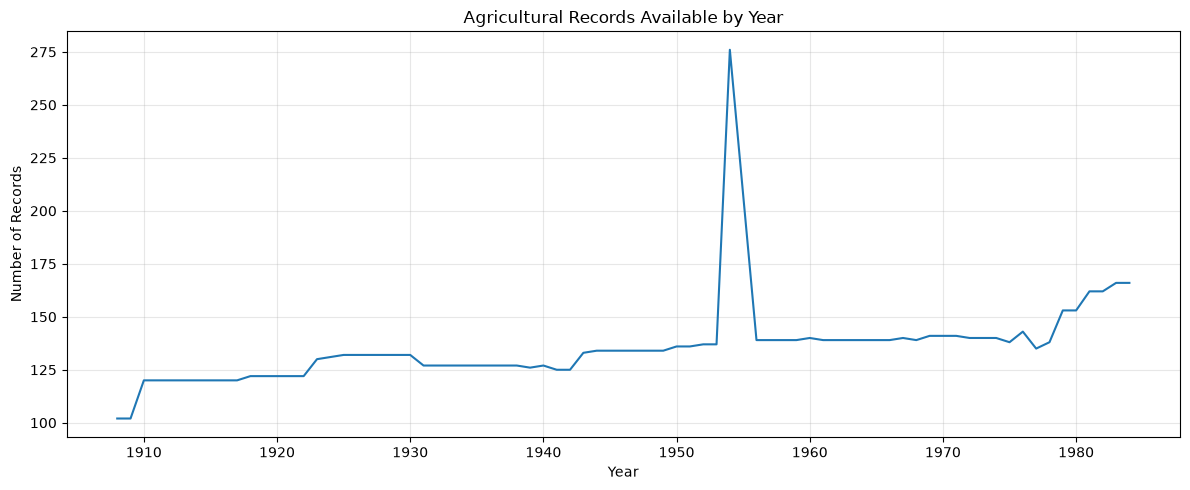

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    records_by_year["REF_DATE"],
    records_by_year["records"]
)

ax.set_title("Agricultural Records Available by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Records")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Province Coverage
# ============================================================

province_summary = (
    farm_df.groupby("GEO")
    .agg(
        records=("REF_DATE", "size"),
        first_year=("REF_DATE", "min"),
        last_year=("REF_DATE", "max"),
        unique_years=("REF_DATE", "nunique"),
        unique_crops=("Type of crop", "nunique")
    )
    .sort_values("records", ascending=False)
)

display(province_summary)

,records,first_year,last_year,unique_years,unique_crops
GEO,,,,,
CA,1305,1908,1984,76,22
ON,1169,1908,1984,76,18
MA,1104,1908,1984,76,22
AB,1045,1908,1984,76,22
SK,957,1908,1984,76,20
QU,952,1908,1984,76,15
PP,845,1908,1984,76,16
BC,714,1908,1984,76,13
NS,630,1908,1984,76,13


In [16]:
# ============================================================
# Crop Coverage
# ============================================================

crop_summary = (
    farm_df.groupby("Type of crop")
    .agg(
        records=("REF_DATE", "size"),
        first_year=("REF_DATE", "min"),
        last_year=("REF_DATE", "max"),
        unique_years=("REF_DATE", "nunique"),
        unique_provinces=("GEO", "nunique")
    )
    .sort_values("records", ascending=False)
)

display(crop_summary)

,records,first_year,last_year,unique_years,unique_provinces
Type of crop,,,,,
Barley,924,1908,1984,76,13
"Wheat, all",924,1908,1984,76,12
Tame hay,924,1908,1984,76,13
Oats,924,1908,1984,76,12
Mixed grains,914,1908,1984,76,12
Corn for silage,832,1908,1984,76,12
"Rye, all",718,1908,1984,76,11
"Peas, dry",655,1908,1984,76,11
Flaxseed,572,1908,1984,76,8


In [17]:
# ============================================================
# Province-Crop Observation Counts
# ============================================================

province_crop_counts = pd.crosstab(
    farm_df["Type of crop"],
    farm_df["GEO"]
)

display(province_crop_counts)

GEO,,AB,BC,CA,MA,MP,NB,NL,NS,ON,PEI,PP,QU,SK
Type of crop,,,,,,,,,,,,,,
Barley,1,77,76,77,77,77,77,0,77,77,77,77,77,77
"Beans, all dry (white and coloured)",0,23,31,77,0,0,33,0,23,77,0,0,67,21
Buckwheat,0,8,0,77,60,0,69,0,33,71,33,0,77,8
Canola (rapeseed),0,30,18,42,42,0,0,0,0,2,0,42,0,42
Corn for grain,0,6,0,77,44,2,0,0,2,77,0,9,77,0
Corn for silage,0,75,75,77,75,8,77,0,77,77,77,75,77,62
Flaxseed,0,77,53,77,77,0,0,0,0,67,0,77,67,77
Lentils,0,4,0,4,4,0,0,0,0,0,0,0,0,4
Mixed grains,0,75,75,77,75,77,77,0,77,77,77,75,77,75


In [18]:
# ============================================================
# Parse Climate Dates
# ============================================================

climate_df["LOCAL_DATE"] = pd.to_datetime(
    climate_df["LOCAL_DATE"],
    errors="coerce"
)

print(f"Invalid dates after conversion: {climate_df['LOCAL_DATE'].isna().sum():,}")
print(f"Earliest climate date: {climate_df['LOCAL_DATE'].min()}")
print(f"Latest climate date:   {climate_df['LOCAL_DATE'].max()}")

climate_df["year"] = climate_df["LOCAL_DATE"].dt.year
climate_df["month"] = climate_df["LOCAL_DATE"].dt.month

Invalid dates after conversion: 0
Earliest climate date: 1940-01-01 00:00:00
Latest climate date:   2020-01-01 00:00:00


In [19]:
# ============================================================
# Climate Data Availability by Year
# ============================================================

climate_variables = [
    col for col in climate_df.columns
    if col not in ["LOCAL_DATE", "year", "month"]
]

climate_coverage_by_year = (
    climate_df
    .groupby("year")[climate_variables]
    .agg(lambda x: x.notna().mean() * 100)
)

display(climate_coverage_by_year.round(1))

,MEAN_TEMPERATURE_CALGARY,TOTAL_PRECIPITATION_CALGARY,MEAN_TEMPERATURE_EDMONTON,TOTAL_PRECIPITATION_EDMONTON,MEAN_TEMPERATURE_HALIFAX,TOTAL_PRECIPITATION_HALIFAX,MEAN_TEMPERATURE_MONCTON,TOTAL_PRECIPITATION_MONCTON,MEAN_TEMPERATURE_MONTREAL,TOTAL_PRECIPITATION_MONTREAL,MEAN_TEMPERATURE_OTTAWA,TOTAL_PRECIPITATION_OTTAWA,MEAN_TEMPERATURE_QUEBEC,TOTAL_PRECIPITATION_QUEBEC,MEAN_TEMPERATURE_SASKATOON,TOTAL_PRECIPITATION_SASKATOON,MEAN_TEMPERATURE_STJOHNS,TOTAL_PRECIPITATION_STJOHNS,MEAN_TEMPERATURE_TORONTO,TOTAL_PRECIPITATION_TORONTO,MEAN_TEMPERATURE_VANCOUVER,TOTAL_PRECIPITATION_VANCOUVER,MEAN_TEMPERATURE_WHITEHORSE,TOTAL_PRECIPITATION_WHITEHORSE,MEAN_TEMPERATURE_WINNIPEG,TOTAL_PRECIPITATION_WINNIPEG
year,,,,,,,,,,,,,,,,,,,,,,,,,,
1940,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,100.0,100.0,0.0,0.0,100.0,100.0,0.0,0.0,99.7,100.0,100.0,100.0,0.0,0.0,100.0,100.0
1941,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,33.4,33.4,100.0,100.0,0.0,0.0,97.3,100.0,0.0,0.0,100.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0
1942,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,95.6,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,99.7,100.0,99.7,100.0,75.3,75.3,100.0,100.0
1943,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,99.7,100.0,100.0,100.0,77.0,77.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1944,100.0,100.0,0.0,0.0,0.0,0.0,100.0,98.9,99.5,100.0,100.0,100.0,98.9,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1945,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,99.2,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1946,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,99.7,100.0,100.0,100.0,99.5,100.0,100.0,100.0,99.7,100.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1947,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,99.7,99.7,100.0,100.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1948,100.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,99.7,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [20]:
# ============================================================
# Climate Coverage by City and Year
# ============================================================

cities = [
    "CALGARY", "EDMONTON", "HALIFAX", "MONCTON",
    "MONTREAL", "OTTAWA", "QUEBEC", "SASKATOON",
    "STJOHNS", "TORONTO", "VANCOUVER",
    "WHITEHORSE", "WINNIPEG"
]

city_coverage = {}

for city in cities:
    temp_col = f"MEAN_TEMPERATURE_{city}"
    precip_col = f"TOTAL_PRECIPITATION_{city}"

    city_coverage[city] = (
        climate_df.groupby("year")[[temp_col, precip_col]]
        .apply(lambda x: x.notna().mean().mean() * 100)
    )

city_coverage_df = pd.DataFrame(city_coverage)

display(city_coverage_df.round(1))

,CALGARY,EDMONTON,HALIFAX,MONCTON,MONTREAL,OTTAWA,QUEBEC,SASKATOON,STJOHNS,TORONTO,VANCOUVER,WHITEHORSE,WINNIPEG
year,,,,,,,,,,,,,
1940,100.0,0.0,0.0,100.0,0.0,100.0,0.0,100.0,0.0,99.9,100.0,0.0,100.0
1941,100.0,0.0,0.0,100.0,33.4,100.0,0.0,98.6,0.0,100.0,100.0,0.0,100.0
1942,100.0,0.0,0.0,100.0,97.8,100.0,0.0,100.0,100.0,99.9,99.9,75.3,100.0
1943,100.0,0.0,0.0,100.0,99.9,100.0,77.0,100.0,100.0,100.0,100.0,100.0,100.0
1944,100.0,0.0,0.0,99.5,99.7,100.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0
1945,100.0,0.0,0.0,100.0,99.6,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1946,100.0,0.0,0.0,100.0,99.9,100.0,99.7,100.0,99.9,99.7,100.0,100.0,100.0
1947,100.0,0.0,0.0,100.0,100.0,100.0,99.7,100.0,99.7,100.0,100.0,100.0,100.0
1948,100.0,0.0,0.0,100.0,100.0,100.0,99.9,100.0,100.0,100.0,100.0,100.0,100.0


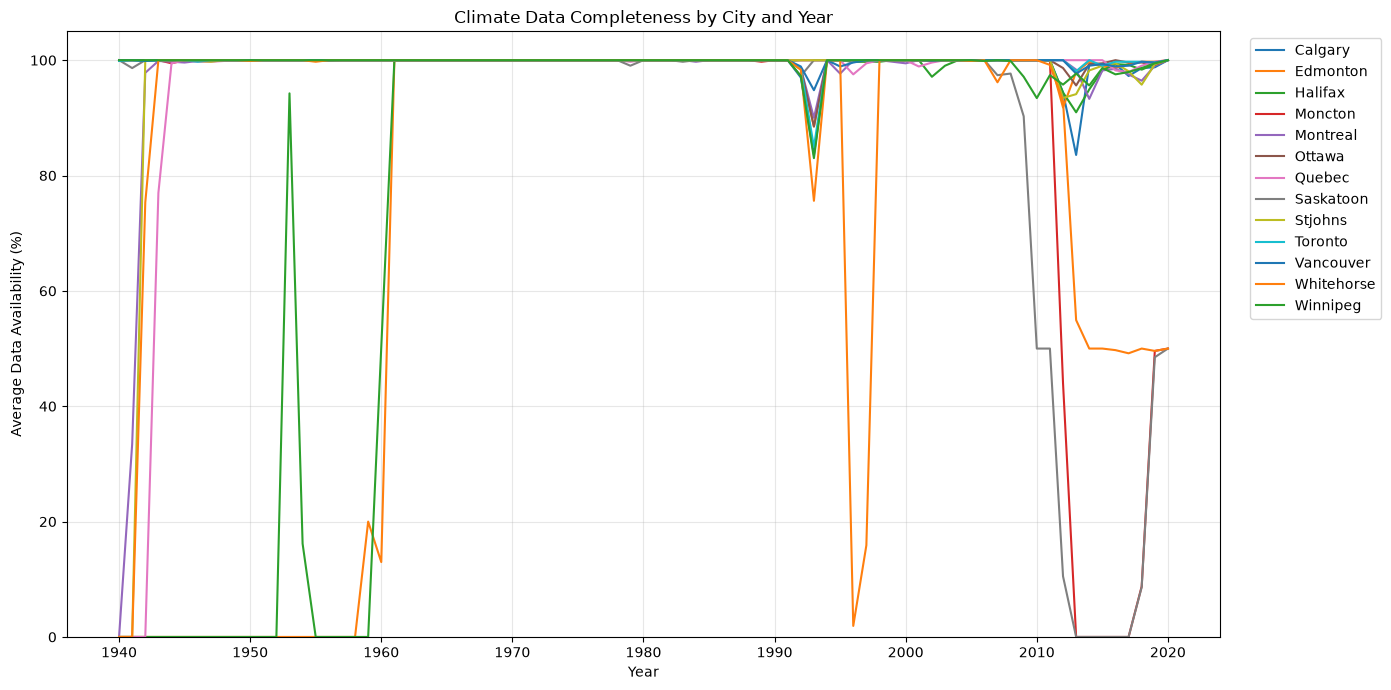

In [21]:
fig, ax = plt.subplots(figsize=(14, 7))

for city in city_coverage_df.columns:
    ax.plot(
        city_coverage_df.index,
        city_coverage_df[city],
        label=city.title()
    )

ax.set_title("Climate Data Completeness by City and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Data Availability (%)")
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Investigate the 1954 Agricultural Records
# ============================================================

farm_1954 = (
    farm_df[farm_df["REF_DATE"] == 1954]
    .sort_values(["GEO", "Type of crop"])
)

print(f"Total 1954 rows: {len(farm_1954):,}")
print(f"Exact duplicate rows to remove: {farm_1954.duplicated().sum():,}")

# Count observations for each province-crop combination
counts_1954 = (
    farm_1954
    .groupby(["GEO", "Type of crop"], dropna=False)
    .size()
    .reset_index(name="row_count")
    .sort_values(["row_count", "GEO", "Type of crop"],
                 ascending=[False, True, True])
)

print("\n1954 province-crop combinations occurring more than once:")
display(counts_1954[counts_1954["row_count"] > 1])

print(
    "\nNumber of province-crop combinations with multiple rows:",
    (counts_1954["row_count"] > 1).sum()
)

Total 1954 rows: 276
Exact duplicate rows to remove: 9

1954 province-crop combinations occurring more than once:


,GEO,Type of crop,row_count
0,AB,Barley,2
2,AB,Corn for silage,2
3,AB,Flaxseed,2
4,AB,Mixed grains,2
5,AB,Mustard seed,2
...,...,...,...
133,SK,"Rye, fall remaining",2
134,SK,"Rye, spring",2
135,SK,Sunflower seed,2
136,SK,Tame hay,2



Number of province-crop combinations with multiple rows: 137


In [23]:
# ============================================================
# Compare Repeated 1954 Province-Crop Records
# ============================================================

repeated_keys = counts_1954[
    counts_1954["row_count"] > 1
][["GEO", "Type of crop"]]

repeated_1954 = farm_1954.merge(
    repeated_keys,
    on=["GEO", "Type of crop"],
    how="inner"
)

display(
    repeated_1954.sort_values(
        ["GEO", "Type of crop"]
    )
)

,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
0,1954,AB,Barley,40.0,1235.0,1524000.0,3053000.0,1236000.0,60900
1,1954,AB,Barley,39.0,1455.0,2177000.0,3702000.0,1498000.0,85000
2,1954,AB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
3,1954,AB,Corn for silage,0.0,0.0,0.0,0.0,0.0,0
4,1954,AB,Flaxseed,96.0,630.0,54600.0,215000.0,87000.0,5268
...,...,...,...,...,...,...,...,...,...
269,1954,SK,Sunflower seed,0.0,0.0,0.0,0.0,0.0,0
270,1954,SK,Tame hay,14.9,4100.0,984000.0,603000.0,240000.0,14648
271,1954,SK,Tame hay,15.2,4100.0,1025000.0,621000.0,250000.0,15538
272,1954,SK,"Wheat, all",44.0,685.0,4599000.0,16600000.0,6718000.0,204490


In [24]:
# ============================================================
# Inspect Geographic Codes
# ============================================================

print("Unique GEO values:")
print(sorted(farm_df["GEO"].astype(str).unique()))

geo_counts = (
    farm_df["GEO"]
    .value_counts(dropna=False)
    .rename_axis("GEO")
    .reset_index(name="records")
)

display(geo_counts)

Unique GEO values:
[' ', 'AB', 'BC', 'CA', 'MA', 'MP', 'NB', 'NL', 'NS', 'ON', 'PEI', 'PP', 'QU', 'SK']


,GEO,records
0,CA,1305
1,ON,1169
2,MA,1104
3,AB,1045
4,SK,957
5,QU,952
6,PP,845
7,BC,714
8,NS,630
9,NB,616


In [25]:
# Inspect suspicious GEO value
display(
    farm_df[
        farm_df["GEO"].astype(str).str.strip() == "1"
    ]
)

,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)


In [26]:
# ============================================================
# Investigate Missing Crop Record
# ============================================================

sk_1954 = (
    farm_df[
        (farm_df["REF_DATE"] == 1954) &
        (farm_df["GEO"] == "SK")
    ]
    .sort_values("Type of crop")
)

display(sk_1954)

,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
5953,1954,SK,Barley,39.0,1235.0,1154000.0,2313000.0,936000.0,45580
6092,1954,SK,Barley,40.0,1455.0,2264000.0,3846000.0,1556000.0,89440
5954,1954,SK,Canola (rapeseed),71.0,785.0,9800.0,31000.0,12500.0,694
6093,1954,SK,Canola (rapeseed),77.0,630.0,31300.0,123000.0,49800.0,2411
5955,1954,SK,Corn for silage,12.0,750.0,3000.0,1100.0,400.0,36
6094,1954,SK,Corn for silage,12.7,750.0,3000.0,1100.0,400.0,38
5956,1954,SK,Flaxseed,98.0,585.0,115600.0,489000.0,198000.0,11330
6095,1954,SK,Flaxseed,109.0,690.0,287000.0,1030000.0,417000.0,31301
5957,1954,SK,Mixed grains,37.0,1005.0,14500.0,35600.0,14400.0,534
6096,1954,SK,Mixed grains,36.0,1515.0,22700.0,37000.0,15000.0,813


In [27]:
# Compare suspicious row with Saskatchewan 1954 totals
numeric_cols = [
    "Average farm price (dollars per tonne)",
    "Average yield (kilograms per hectare)",
    "Production (metric tonnes)",
    "Seeded area (acres)",
    "Seeded area (hectares)",
    "Total farm value (dollars)"
]

print("Sum of numeric values for named SK crops in 1954:")
display(
    sk_1954[
        sk_1954["Type of crop"].notna()
    ][numeric_cols].sum()
)

print("\nSuspicious missing-crop record:")
display(
    sk_1954[
        sk_1954["Type of crop"].isna()
    ][numeric_cols]
)

Sum of numeric values for named SK crops in 1954:


Average farm price (dollars per tonne)        1125.8
Average yield (kilograms per hectare)        31010.0
Production (metric tonnes)                23384950.0
Seeded area (acres)                       47567300.0
Seeded area (hectares)                    19243900.0
Total farm value (dollars)                 1019626.0
dtype: float64


Suspicious missing-crop record:


,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
5966,6663.3,460305.0,133678950.0,317203482.0,128389050.0,3311439


In [28]:
# ============================================================
# Candidate Modeling Period: 1961-1984
# ============================================================

candidate_farm = farm_df[
    farm_df["REF_DATE"].between(1961, 1984)
].copy()

print("Original farm records:")
print(f"{len(farm_df):,}")

print("\nRecords from 1961-1984:")
print(f"{len(candidate_farm):,}")

print("\nPercentage retained:")
print(f"{len(candidate_farm) / len(farm_df) * 100:.2f}%")

print("\nYears retained:")
print(
    candidate_farm["REF_DATE"].min(),
    "-",
    candidate_farm["REF_DATE"].max()
)

print("\nUnique crops retained:")
print(candidate_farm["Type of crop"].nunique())

print("\nUnique GEO codes retained:")
print(candidate_farm["GEO"].nunique())

Original farm records:
10,273

Records from 1961-1984:
3,472

Percentage retained:
33.80%

Years retained:
1961 - 1984

Unique crops retained:
23

Unique GEO codes retained:
13


In [29]:
# Crop representation during candidate modeling period
candidate_crop_summary = (
    candidate_farm
    .groupby("Type of crop")
    .agg(
        records=("REF_DATE", "size"),
        years=("REF_DATE", "nunique"),
        geographies=("GEO", "nunique")
    )
    .sort_values("records", ascending=False)
)

display(candidate_crop_summary)

,records,years,geographies
Type of crop,,,
Tame hay,290,24,13
Barley,288,24,12
Mixed grains,288,24,12
"Wheat, all",288,24,12
Oats,288,24,12
Corn for silage,259,24,12
"Rye, all",220,24,10
"Peas, dry",168,24,8
Flaxseed,168,24,8


In [30]:
# ============================================================
# Geographic Structure During Modeling Period
# ============================================================

geo_model_summary = (
    candidate_farm
    .groupby("GEO")
    .agg(
        records=("REF_DATE", "size"),
        first_year=("REF_DATE", "min"),
        last_year=("REF_DATE", "max"),
        years=("REF_DATE", "nunique"),
        crops=("Type of crop", "nunique")
    )
    .sort_values("records", ascending=False)
)

display(geo_model_summary)

,records,first_year,last_year,years,crops
GEO,,,,,
CA,473,1961,1984,24,22
MA,428,1961,1984,24,21
AB,387,1961,1984,24,21
ON,356,1961,1984,24,18
SK,351,1961,1984,24,19
PP,301,1961,1984,24,16
QU,301,1961,1984,24,15
BC,233,1961,1984,24,12
NS,180,1961,1984,24,10


In [31]:
# ============================================================
# Compare Geographic Codes
# ============================================================

for geo in ["CA", "PP", "MP"]:
    print(f"\n--- {geo} ---")

    display(
        candidate_farm[
            candidate_farm["GEO"] == geo
        ].head(10)
    )


--- CA ---


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
6825,1961,CA,Barley,48.0,1095.0,2451700.0,5529000.0,2237050.0,118810
6826,1961,CA,"Beans, all dry (white and coloured)",143.0,1355.0,36100.0,65700.0,26600.0,5171
6827,1961,CA,Buckwheat,52.0,1135.0,26500.0,57500.0,23300.0,1390
6828,1961,CA,Canola (rapeseed),79.0,885.0,254500.0,710300.0,287500.0,20179
6829,1961,CA,Corn for grain,48.0,4590.0,742100.0,400100.0,161700.0,35334
6830,1961,CA,Corn for silage,6.0,25200.0,3677000.0,360100.0,145900.0,21949
6831,1961,CA,Flaxseed,131.0,435.0,367700.0,2086000.0,844150.0,48131
6832,1961,CA,Mixed grains,44.0,1975.0,1251450.0,1565700.0,633600.0,54775
6833,1961,CA,Mustard seed,79.0,350.0,17100.0,120800.0,48900.0,1355
6834,1961,CA,Oats,49.0,1265.0,4378900.0,8542700.0,3457350.0,212795



--- PP ---


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
6896,1961,PP,Barley,49.0,1065.0,2307000.0,5361000.0,2169000.0,112070
6897,1961,PP,Canola (rapeseed),79.0,885.0,254500.0,710300.0,287500.0,20179
6898,1961,PP,Corn for silage,10.6,8580.0,115000.0,33100.0,13400.0,1222
6899,1961,PP,Flaxseed,131.0,425.0,353000.0,2051000.0,830000.0,46286
6900,1961,PP,Mixed grains,43.0,1180.0,318100.0,667000.0,269900.0,13584
6901,1961,PP,Oats,41.0,960.0,1989000.0,5122000.0,2073000.0,82320
6902,1961,PP,"Peas, dry",79.0,1005.0,23500.0,57700.0,23400.0,1845
6903,1961,PP,"Rye, all",42.0,615.0,122700.0,492700.0,198800.0,5147
6904,1961,PP,Sugar beets,14.9,26300.0,647300.0,60679.0,24600.0,9644
6905,1961,PP,Tame hay,21.4,2350.0,4327000.0,4533000.0,1840000.0,92426



--- MP ---


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
6861,1961,MP,Barley,54.0,1865.0,4200.0,5500.0,2250.0,227
6862,1961,MP,Mixed grains,48.0,2380.0,64750.0,67200.0,27200.0,3132
6863,1961,MP,Oats,56.0,1620.0,157000.0,239200.0,96850.0,8745
6864,1961,MP,Tame hay,15.7,4450.0,1258000.0,700000.0,283000.0,19688
6865,1961,MP,"Wheat, all",62.0,1860.0,5950.0,8000.0,3200.0,367
7000,1962,MP,Barley,49.0,2165.0,8550.0,9800.0,3950.0,422
7001,1962,MP,Mixed grains,44.0,2475.0,65900.0,65900.0,26650.0,2867
7002,1962,MP,Oats,52.0,1815.0,173500.0,236000.0,95500.0,9061
7003,1962,MP,Tame hay,16.8,4260.0,1171000.0,681000.0,275000.0,19697
7004,1962,MP,"Wheat, all",61.0,2050.0,6250.0,7600.0,3050.0,384


In [32]:
# ============================================================
# Candidate Province-Level Modeling Population
# ============================================================

province_codes = [
    "AB", "BC", "MA", "NB", "NS",
    "ON", "PEI", "QU", "SK", "NL"
]

province_farm = candidate_farm[
    candidate_farm["GEO"].isin(province_codes)
].copy()

print(f"1961-1984 records before geography filtering: {len(candidate_farm):,}")
print(f"Province-level records retained:              {len(province_farm):,}")
print(
    f"Percentage retained: "
    f"{len(province_farm) / len(candidate_farm) * 100:.2f}%"
)

print("\nRecords by province:")
display(
    province_farm["GEO"]
    .value_counts()
    .rename("records")
    .to_frame()
)

1961-1984 records before geography filtering: 3,472
Province-level records retained:              2,554
Percentage retained: 73.56%

Records by province:


,records
GEO,
MA,428
AB,387
ON,356
SK,351
QU,301
BC,233
NS,180
NB,166
PEI,150


In [33]:
# ============================================================
# Target Availability in Candidate Modeling Population
# ============================================================

yield_col = "Average yield (kilograms per hectare)"
price_col = "Average farm price (dollars per tonne)"

target_summary = pd.DataFrame({
    "target": [yield_col, price_col],
    "missing_count": [
        province_farm[yield_col].isna().sum(),
        province_farm[price_col].isna().sum()
    ],
    "zero_count": [
        (province_farm[yield_col] == 0).sum(),
        (province_farm[price_col] == 0).sum()
    ]
})

target_summary["missing_percent"] = (
    target_summary["missing_count"] /
    len(province_farm) * 100
)

target_summary["zero_percent"] = (
    target_summary["zero_count"] /
    len(province_farm) * 100
)

display(target_summary)

,target,missing_count,zero_count,missing_percent,zero_percent
0,Average yield (kilograms per hectare),25,105,0.978857,4.111198
1,Average farm price (dollars per tonne),28,106,1.096319,4.150352


In [34]:
# ============================================================
# Crop Representation After Time and Geography Filtering
# ============================================================

final_candidate_crop_summary = (
    province_farm
    .groupby("Type of crop")
    .agg(
        records=("REF_DATE", "size"),
        years=("REF_DATE", "nunique"),
        provinces=("GEO", "nunique"),
        yield_available=(yield_col, lambda x: x.notna().sum()),
        price_available=(price_col, lambda x: x.notna().sum())
    )
    .sort_values("records", ascending=False)
)

display(final_candidate_crop_summary)

,records,years,provinces,yield_available,price_available
Type of crop,,,,,
Tame hay,218,24,10,218,218
Barley,216,24,9,216,216
Mixed grains,216,24,9,216,216
"Wheat, all",216,24,9,216,216
Oats,216,24,9,216,216
Corn for silage,203,24,9,203,203
"Rye, all",168,24,7,168,168
"Peas, dry",120,24,6,118,116
Flaxseed,120,24,6,106,106


### Historical Modeling Period Selection

Although the agricultural dataset spans 1908–1984, the climate dataset begins in 1940 and does not provide consistent coverage across all locations during its earliest years. In particular, Edmonton and Halifax contain substantial gaps before 1961, while climate coverage becomes substantially more complete across the available locations beginning in 1961.

A modeling period of **1961–1984** was therefore selected. This retains 3,472 agricultural observations across 24 consecutive years and 23 crop categories before geographic filtering.

The shorter period sacrifices historical sample size in exchange for greater consistency in climate availability and comparability across regions. This choice also reduces the influence of substantially older agricultural conditions that may be less representative of later production technologies and practices. The cutoff was selected from observed data coverage rather than specified in advance.

In [35]:
# ============================================================
# Investigate Zero Yield and Price Values
# ============================================================

zero_target_rows = province_farm[
    (province_farm[yield_col] == 0) |
    (province_farm[price_col] == 0)
].copy()

print(f"Rows with zero yield or price: {len(zero_target_rows):,}")

print("\nZero-target rows by crop:")
display(
    zero_target_rows["Type of crop"]
    .value_counts()
    .rename("zero_target_records")
    .to_frame()
)

print("\nZero-target rows by province:")
display(
    zero_target_rows["GEO"]
    .value_counts()
    .rename("zero_target_records")
    .to_frame()
)

Rows with zero yield or price: 108

Zero-target rows by crop:


,zero_target_records
Type of crop,
Corn for silage,65
"Rye, all",24
Sunflower seed,9
Corn for grain,5
"Rye, fall remaining",4
"Peas, dry",1



Zero-target rows by province:


,zero_target_records
GEO,
NS,36
AB,20
NB,16
PEI,16
QU,13
SK,6
ON,1


In [36]:
# ============================================================
# Determine Meaning of Zero Target Values
# ============================================================

zero_pattern_summary = pd.DataFrame({
    "Condition": [
        "Zero yield",
        "Zero price",
        "Zero production",
        "Zero seeded hectares",
        "Zero yield AND zero production",
        "Zero price AND zero production",
        "Zero yield AND zero price AND zero production"
    ],
    "Records": [
        (province_farm[yield_col] == 0).sum(),
        (province_farm[price_col] == 0).sum(),
        (province_farm["Production (metric tonnes)"] == 0).sum(),
        (province_farm["Seeded area (hectares)"] == 0).sum(),

        (
            (province_farm[yield_col] == 0) &
            (province_farm["Production (metric tonnes)"] == 0)
        ).sum(),

        (
            (province_farm[price_col] == 0) &
            (province_farm["Production (metric tonnes)"] == 0)
        ).sum(),

        (
            (province_farm[yield_col] == 0) &
            (province_farm[price_col] == 0) &
            (province_farm["Production (metric tonnes)"] == 0)
        ).sum()
    ]
})

display(zero_pattern_summary)

,Condition,Records
0,Zero yield,105
1,Zero price,106
2,Zero production,104
3,Zero seeded hectares,97
4,Zero yield AND zero production,104
5,Zero price AND zero production,103
6,Zero yield AND zero price AND zero production,103


In [37]:
# ============================================================
# Check Potentially Contradictory Zero Values
# ============================================================

contradictory_zeros = province_farm[
    (
        (province_farm[yield_col] == 0) |
        (province_farm[price_col] == 0)
    )
    &
    (province_farm["Production (metric tonnes)"] > 0)
]

print(
    "Zero yield/price rows with positive production:",
    len(contradictory_zeros)
)

display(contradictory_zeros)

Zero yield/price rows with positive production: 3


,REF_DATE,GEO,Type of crop,Average farm price (dollars per tonne),Average yield (kilograms per hectare),Production (metric tonnes),Seeded area (acres),Seeded area (hectares),Total farm value (dollars)
8964,1976,NB,Corn for silage,0.0,30610.0,75000.0,6000.0,2450.0,0
8970,1976,NS,Corn for silage,0.0,33270.0,168000.0,12500.0,5050.0,0
9006,1976,PEI,Corn for silage,0.0,3398.0,158000.0,11500.0,4650.0,0


### Geographic and Crop Coverage

The 1961–1984 agricultural subset contains 3,472 observations. The dataset includes both individual provinces and aggregate geographic categories. Aggregate categories such as Canada (`CA`) and other multi-province regions were separated from the province-level modeling population because combining regional aggregates with individual provinces would mix geographic levels and complicate linkage with location-specific climate information.

After initially retaining individual province codes, 2,552 agricultural observations remained. Newfoundland (`NL`) contained only two observations during the selected period and therefore does not provide sufficient longitudinal information for predictive modeling.

Crop coverage was also evaluated using the number of years represented rather than row count alone. Most crops contain observations spanning all 24 years of the selected period. Durum wheat contains only six years and lentils only four years of observations. These short histories are insufficient for meaningful chronological training and evaluation, so they will be retained where useful for descriptive analysis but excluded from predictive model evaluation.

Prince Edward Island is retained for agricultural analysis; however, its inclusion in climate-based modeling will be reconsidered because the climate dataset does not contain a directly corresponding PEI weather station.

In [38]:
# ============================================================
# Create Agricultural Analysis Population
# ============================================================

# Province-level geographic codes retained for agricultural EDA
analysis_provinces = [
    "AB", "BC", "MA", "NB", "NS",
    "ON", "PEI", "QU", "SK"
]

farm_analysis_df = (
    farm_df[
        farm_df["REF_DATE"].between(1961, 1984)
        & farm_df["GEO"].isin(analysis_provinces)
    ]
    .copy()
)

print(f"Original agricultural records: {len(farm_df):,}")
print(f"1961-1984 records:             {len(candidate_farm):,}")
print(f"Analysis population:           {len(farm_analysis_df):,}")

print("\nYears:")
print(
    farm_analysis_df["REF_DATE"].min(),
    "-",
    farm_analysis_df["REF_DATE"].max()
)

print("\nProvinces:")
print(sorted(farm_analysis_df["GEO"].unique()))

print("\nCrops:")
print(farm_analysis_df["Type of crop"].nunique())

Original agricultural records: 10,273
1961-1984 records:             3,472
Analysis population:           2,552

Years:
1961 - 1984

Provinces:
['AB', 'BC', 'MA', 'NB', 'NS', 'ON', 'PEI', 'QU', 'SK']

Crops:
23


In [39]:
# ============================================================
# Create Agricultural Modeling Population
# ============================================================

short_history_crops = [
    "Wheat, durum",
    "Lentils"
]

farm_model_df = (
    farm_analysis_df[
        ~farm_analysis_df["Type of crop"].isin(short_history_crops)
        & farm_analysis_df[yield_col].notna()
        & farm_analysis_df[price_col].notna()
        & (farm_analysis_df[yield_col] > 0)
        & (farm_analysis_df[price_col] > 0)
    ]
    .copy()
)

print(f"Analysis population: {len(farm_analysis_df):,}")
print(f"Modeling population: {len(farm_model_df):,}")
print(
    f"Records removed for modeling requirements: "
    f"{len(farm_analysis_df) - len(farm_model_df):,}"
)

print("\nModeling years:")
print(
    farm_model_df["REF_DATE"].min(),
    "-",
    farm_model_df["REF_DATE"].max()
)

print("\nCrops retained:")
print(farm_model_df["Type of crop"].nunique())

print("\nProvinces retained:")
print(farm_model_df["GEO"].nunique())

Analysis population: 2,552
Modeling population: 2,388
Records removed for modeling requirements: 164

Modeling years:
1961 - 1984

Crops retained:
21

Provinces retained:
9


In [40]:
# ============================================================
# Agricultural Data Filtering Audit
# ============================================================

time_filtered = farm_df[
    farm_df["REF_DATE"].between(1961, 1984)
]

province_filtered = time_filtered[
    time_filtered["GEO"].isin(analysis_provinces)
]

crop_filtered = province_filtered[
    ~province_filtered["Type of crop"].isin(short_history_crops)
]

valid_target_filtered = crop_filtered[
    crop_filtered[yield_col].notna()
    & crop_filtered[price_col].notna()
    & (crop_filtered[yield_col] > 0)
    & (crop_filtered[price_col] > 0)
]

filter_audit = pd.DataFrame({
    "Stage": [
        "Original agricultural dataset",
        "1961-1984 modeling period",
        "Province-level analysis population",
        "Remove crops with <10 years",
        "Valid positive yield and price"
    ],
    "Records": [
        len(farm_df),
        len(time_filtered),
        len(province_filtered),
        len(crop_filtered),
        len(valid_target_filtered)
    ]
})

filter_audit["Records Removed"] = (
    filter_audit["Records"]
    .shift(1)
    .sub(filter_audit["Records"])
)

filter_audit.loc[0, "Records Removed"] = 0
filter_audit["Records Removed"] = (
    filter_audit["Records Removed"].astype(int)
)

filter_audit["Percent of Original"] = (
    filter_audit["Records"] / len(farm_df) * 100
).round(2)

display(filter_audit)

,Stage,Records,Records Removed,Percent of Original
0,Original agricultural dataset,10273,0,100.00
1,1961-1984 modeling period,3472,6801,33.80
2,Province-level analysis population,2552,920,24.84
3,Remove crops with <10 years,2522,30,24.55
4,Valid positive yield and price,2388,134,23.25


In [41]:
# ============================================================
# Validate Agricultural Modeling Dataset
# ============================================================

validation_checks = pd.Series({
    "Rows": len(farm_model_df),
    "Duplicate rows": farm_model_df.duplicated().sum(),
    "Missing crop types": farm_model_df["Type of crop"].isna().sum(),
    "Missing yield": farm_model_df[yield_col].isna().sum(),
    "Missing price": farm_model_df[price_col].isna().sum(),
    "Zero/negative yield": (farm_model_df[yield_col] <= 0).sum(),
    "Zero/negative price": (farm_model_df[price_col] <= 0).sum(),
    "Years": farm_model_df["REF_DATE"].nunique(),
    "Crops": farm_model_df["Type of crop"].nunique(),
    "Provinces": farm_model_df["GEO"].nunique()
})

display(
    validation_checks
    .rename("Value")
    .to_frame()
)

,Value
Rows,2388
Duplicate rows,0
Missing crop types,0
Missing yield,0
Missing price,0
Zero/negative yield,0
Zero/negative price,0
Years,24
Crops,21
Provinces,9


### Agricultural Data Cleaning Decisions

The initial agricultural dataset contained 10,273 records spanning 1908–1984. Exploratory analysis identified several structural issues that informed the final preprocessing strategy.

The predictive analysis was restricted to **1961–1984** because this period provides substantially more consistent climate coverage across the available Canadian locations. Aggregate geographic categories were excluded so that agricultural observations represent individual provinces and can later be linked consistently with province-level climate features. Newfoundland was also excluded because only two agricultural observations were available during the selected period.

Crop inclusion was evaluated according to temporal coverage rather than row count alone. Lentils and durum wheat contained only four and six years of observations, respectively, which is insufficient for meaningful chronological model training and evaluation. These crops were therefore excluded from predictive modeling.

Zero-valued target records were also investigated before removal. Most zero-target observations simultaneously contained zero yield, zero price, and zero production, indicating that they represent crop-province-year combinations without recorded production rather than meaningful measurements of agricultural performance. Three additional records contained positive production and yield but a zero farm price. Therefore, predictive modeling was restricted to observations containing non-missing, positive yield and farm-price values.

The original data remain unchanged in `farm_df`. The filtered `farm_analysis_df` is retained for agricultural exploratory analysis, while `farm_model_df` contains observations meeting the requirements for predictive modeling.

## Core Agricultural Exploratory Data Analysis

After defining the modeling population, exploratory analysis was performed on the 2,388 observations eligible for predictive modeling. Because agricultural yield and price can differ substantially across crop types, distributions and potential outliers are evaluated primarily within crops rather than across the pooled dataset.

This section examines crop-level yield and price distributions, temporal patterns, and variability. These results will also inform later decisions regarding yield trends, inflation adjustment, feature engineering, and model evaluation.

In [42]:
# ============================================================
# Crop-Level Yield and Price Summary
# ============================================================

crop_descriptive = (
    farm_model_df
    .groupby("Type of crop")
    .agg(
        records=("REF_DATE", "size"),
        mean_yield=(yield_col, "mean"),
        median_yield=(yield_col, "median"),
        std_yield=(yield_col, "std"),
        min_yield=(yield_col, "min"),
        max_yield=(yield_col, "max"),
        mean_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        std_price=(price_col, "std"),
        min_price=(price_col, "min"),
        max_price=(price_col, "max")
    )
    .sort_values("records", ascending=False)
)

display(crop_descriptive.round(2))

,records,mean_yield,median_yield,std_yield,min_yield,max_yield,mean_price,median_price,std_price,min_price,max_price
Type of crop,,,,,,,,,,,
Barley,216,2218.73,2172.5,451.32,585.0,3200.0,80.09,69.5,36.78,28.0,173.0
Mixed grains,216,2318.91,2330.0,414.86,545.0,3340.0,76.34,65.0,35.04,30.0,167.0
"Wheat, all",216,2166.69,2050.0,577.61,575.0,3820.0,102.41,80.0,48.27,43.0,210.0
Tame hay,216,4480.97,4380.0,980.18,1470.0,6840.0,36.97,30.0,20.23,13.2,103.0
Oats,216,1857.69,1860.0,311.20,485.0,2650.0,76.55,62.0,34.11,32.0,162.0
"Rye, all",144,1680.94,1590.0,454.62,435.0,3170.0,76.22,66.5,40.07,29.0,177.0
Corn for silage,138,25062.48,28675.0,12298.96,286.0,46800.0,16.78,15.9,9.24,5.7,50.0
"Peas, dry",116,1570.86,1505.0,387.30,775.0,2980.0,133.17,110.5,60.10,62.0,300.0
Flaxseed,106,873.92,880.0,202.42,360.0,1400.0,175.07,121.0,93.50,70.0,376.0


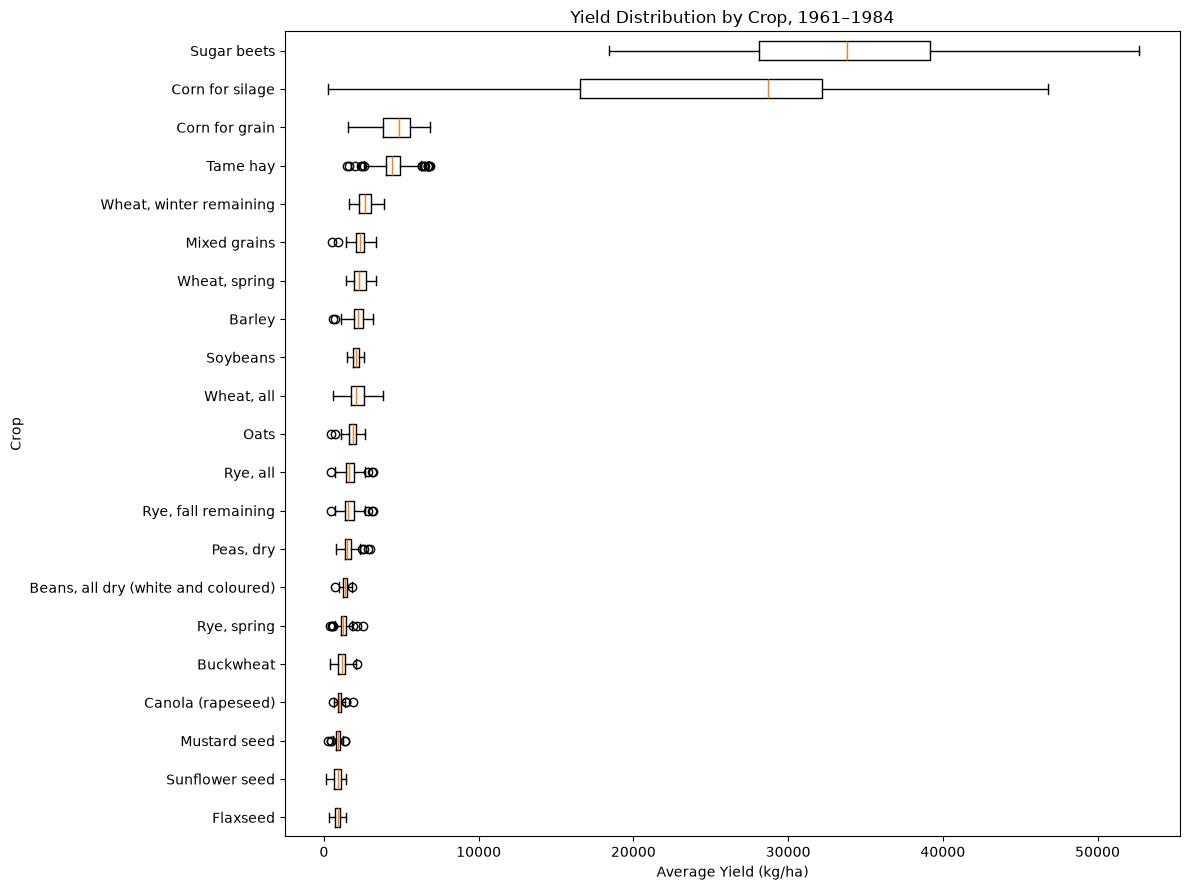

In [43]:
# ============================================================
# Yield Distribution by Crop
# ============================================================

yield_order = (
    farm_model_df
    .groupby("Type of crop")[yield_col]
    .median()
    .sort_values()
    .index
)

yield_data = [
    farm_model_df.loc[
        farm_model_df["Type of crop"] == crop,
        yield_col
    ].values
    for crop in yield_order
]

fig, ax = plt.subplots(figsize=(12, 9))

ax.boxplot(
    yield_data,
    tick_labels=yield_order,
    vert=False,
    showfliers=True
)

ax.set_title("Yield Distribution by Crop, 1961–1984")
ax.set_xlabel("Average Yield (kg/ha)")
ax.set_ylabel("Crop")

plt.tight_layout()
plt.show()

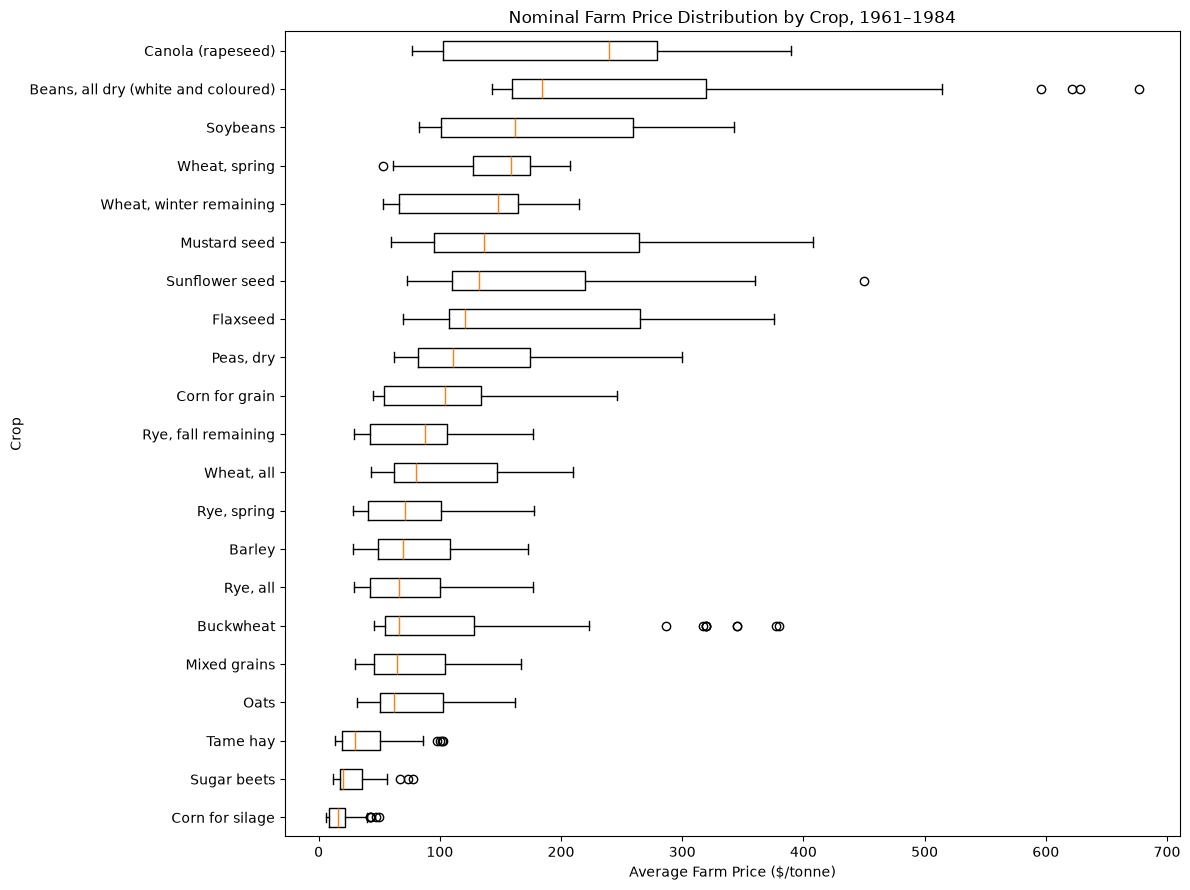

In [44]:
# ============================================================
# Farm Price Distribution by Crop
# ============================================================

price_order = (
    farm_model_df
    .groupby("Type of crop")[price_col]
    .median()
    .sort_values()
    .index
)

price_data = [
    farm_model_df.loc[
        farm_model_df["Type of crop"] == crop,
        price_col
    ].values
    for crop in price_order
]

fig, ax = plt.subplots(figsize=(12, 9))

ax.boxplot(
    price_data,
    tick_labels=price_order,
    vert=False,
    showfliers=True
)

ax.set_title("Nominal Farm Price Distribution by Crop, 1961–1984")
ax.set_xlabel("Average Farm Price ($/tonne)")
ax.set_ylabel("Crop")

plt.tight_layout()
plt.show()

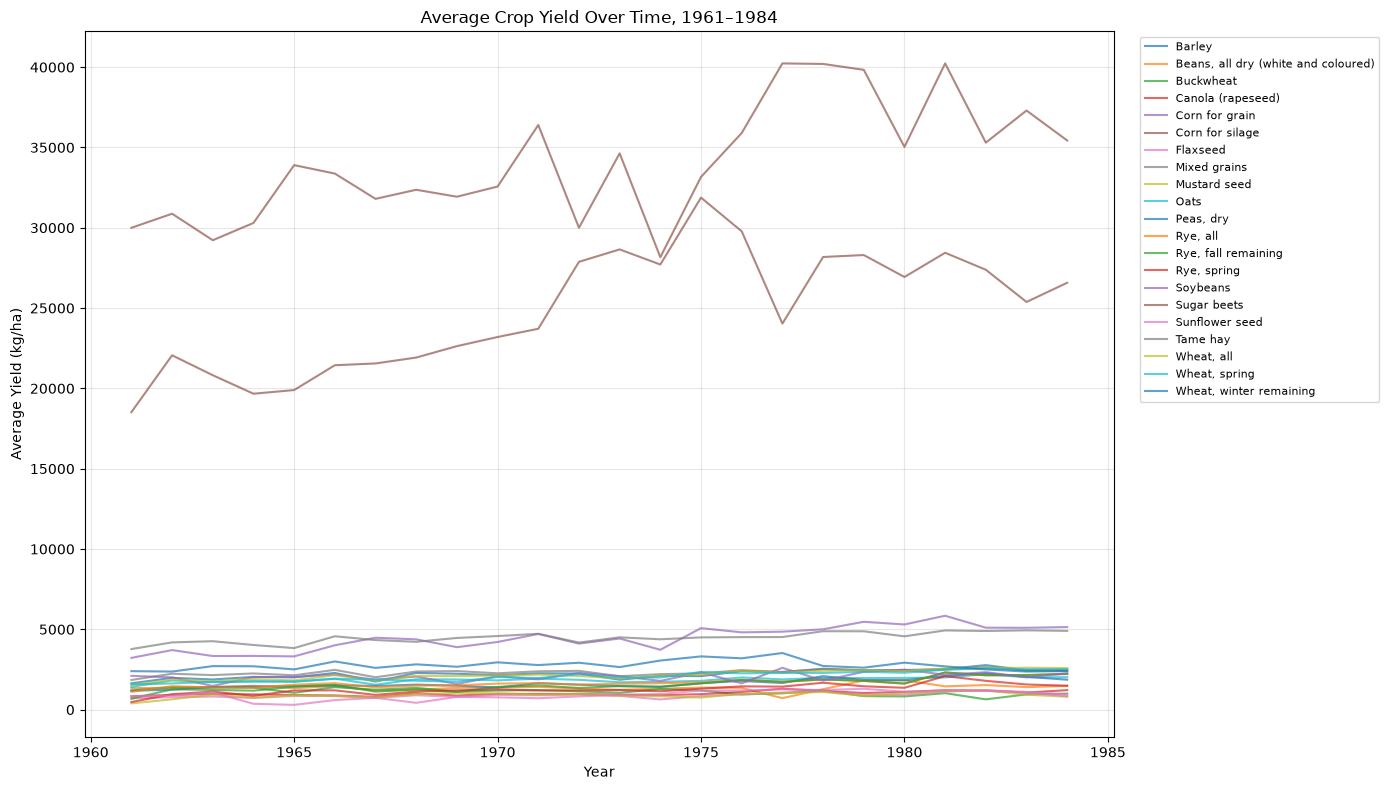

In [45]:
# ============================================================
# Annual Mean Yield by Crop
# ============================================================

annual_crop_yield = (
    farm_model_df
    .groupby(["REF_DATE", "Type of crop"])[yield_col]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))

for crop in annual_crop_yield["Type of crop"].unique():
    crop_data = annual_crop_yield[
        annual_crop_yield["Type of crop"] == crop
    ]

    ax.plot(
        crop_data["REF_DATE"],
        crop_data[yield_col],
        alpha=0.7,
        label=crop
    )

ax.set_title("Average Crop Yield Over Time, 1961–1984")
ax.set_xlabel("Year")
ax.set_ylabel("Average Yield (kg/ha)")
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Quantify Yield Trend by Crop
# ============================================================

from scipy.stats import linregress

def calculate_crop_trends(data, target):
    """
    Calculate a linear time trend for each crop using annual
    mean values.

    Returns the slope, p-value, R-squared, and percentage change
    relative to the crop's mean target value.
    """
    results = []

    annual = (
        data
        .groupby(["Type of crop", "REF_DATE"])[target]
        .mean()
        .reset_index()
    )

    for crop, crop_data in annual.groupby("Type of crop"):

        result = linregress(
            crop_data["REF_DATE"],
            crop_data[target]
        )

        mean_value = crop_data[target].mean()

        results.append({
            "Crop": crop,
            "Years": len(crop_data),
            "Slope_per_year": result.slope,
            "Mean_value": mean_value,
            "Annual_change_pct_of_mean":
                (result.slope / mean_value) * 100,
            "R_squared": result.rvalue ** 2,
            "P_value": result.pvalue
        })

    return pd.DataFrame(results)


yield_trends = calculate_crop_trends(
    farm_model_df,
    yield_col
)

yield_trends = yield_trends.sort_values(
    "Annual_change_pct_of_mean",
    ascending=False
)

display(yield_trends.round(4))

,Crop,Years,Slope_per_year,Mean_value,Annual_change_pct_of_mean,R_squared,P_value
12,"Rye, fall remaining",24,50.6543,1556.5972,3.2542,0.7881,0.0000
13,"Rye, spring",24,38.4268,1278.8194,3.0049,0.6931,0.0000
16,Sunflower seed,24,26.0178,905.6597,2.8728,0.4081,0.0008
11,"Rye, all",24,36.1141,1680.9375,2.1485,0.7757,0.0000
10,"Peas, dry",24,34.8371,1640.0174,2.1242,0.7578,0.0000
4,Corn for grain,24,94.0566,4440.0764,2.1184,0.7764,0.0000
19,"Wheat, spring",24,41.7679,2076.4120,2.0115,0.9188,0.0000
18,"Wheat, all",24,39.1384,2166.6898,1.8064,0.8649,0.0000
6,Flaxseed,24,14.9681,900.3472,1.6625,0.5285,0.0001
5,Corn for silage,24,400.8056,24856.9781,1.6124,0.5928,0.0000


In [47]:
# ============================================================
# Nominal Farm Price Trends by Crop
# ============================================================

price_trends = calculate_crop_trends(
    farm_model_df,
    price_col
)

price_trends = price_trends.sort_values(
    "Annual_change_pct_of_mean",
    ascending=False
)

display(price_trends.round(4))

,Crop,Years,Slope_per_year,Mean_value,Annual_change_pct_of_mean,R_squared,P_value
2,Buckwheat,24,13.0990,139.2333,9.4079,0.7738,0.0000
17,Tame hay,24,2.4855,36.9667,6.7235,0.8867,0.0000
8,Mustard seed,24,12.4490,185.6944,6.7040,0.6893,0.0000
3,Canola (rapeseed),24,12.7128,193.9576,6.5544,0.8125,0.0000
1,"Beans, all dry (white and coloured)",24,19.7409,305.0417,6.4715,0.6783,0.0000
5,Corn for silage,24,0.9753,15.3402,6.3579,0.8607,0.0000
14,Soybeans,24,11.2274,180.6250,6.2159,0.8426,0.0000
12,"Rye, fall remaining",24,4.7251,76.1597,6.2043,0.6821,0.0000
11,"Rye, all",24,4.6733,76.2222,6.1312,0.6937,0.0000
13,"Rye, spring",24,4.6039,76.0139,6.0567,0.6170,0.0000


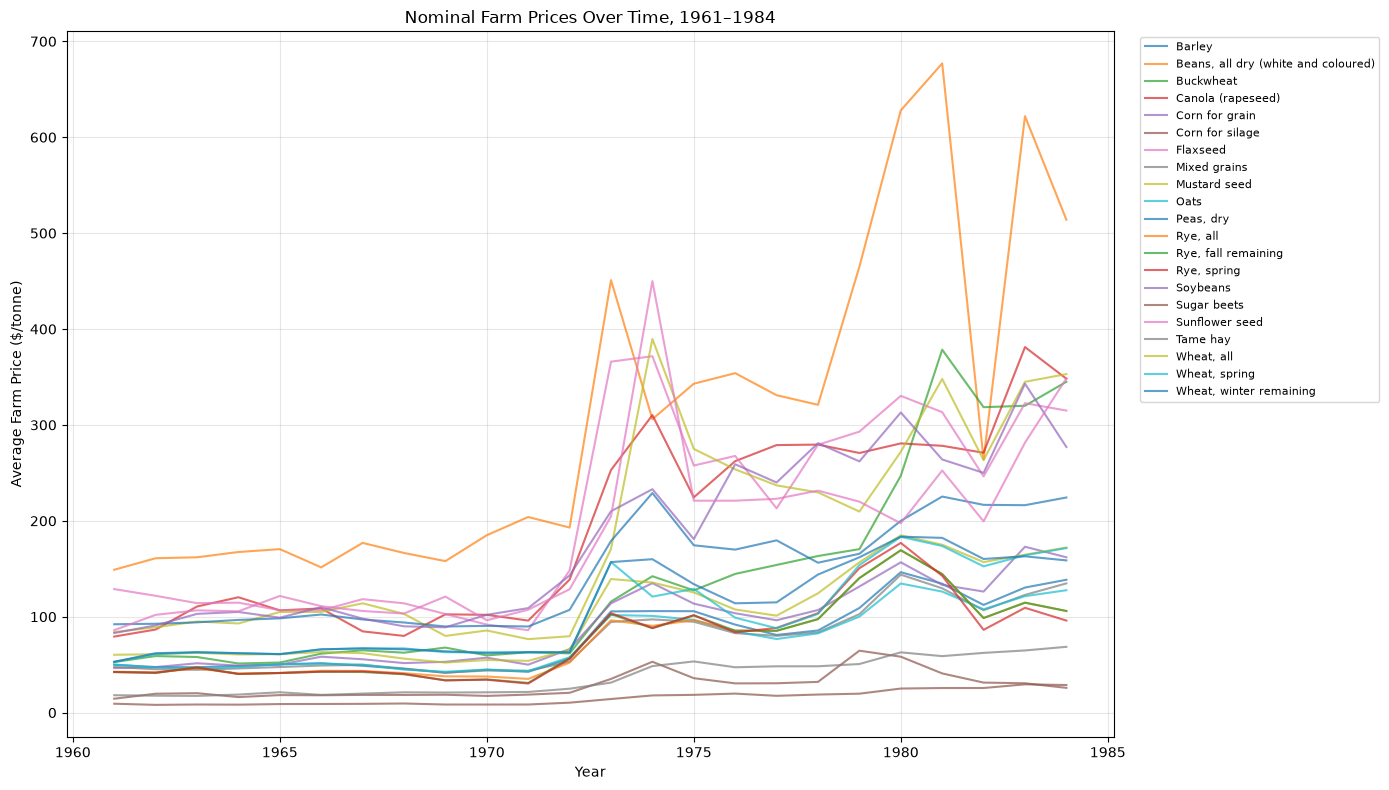

In [48]:
# ============================================================
# Annual Nominal Price by Crop
# ============================================================

annual_crop_price = (
    farm_model_df
    .groupby(["REF_DATE", "Type of crop"])[price_col]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))

for crop in annual_crop_price["Type of crop"].unique():
    crop_data = annual_crop_price[
        annual_crop_price["Type of crop"] == crop
    ]

    ax.plot(
        crop_data["REF_DATE"],
        crop_data[price_col],
        alpha=0.7,
        label=crop
    )

ax.set_title("Nominal Farm Prices Over Time, 1961–1984")
ax.set_xlabel("Year")
ax.set_ylabel("Average Farm Price ($/tonne)")
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

### Core Agricultural EDA Findings

Crop-level exploratory analysis revealed substantial differences in the scale of both yield and farm price. Sugar beets and corn for silage have considerably higher yields than most other crops, causing lower-yield crops to appear compressed when visualized on a common scale. Conversely, these two crops generally occupy the lower end of the farm-price distribution. These differences demonstrate that pooled performance metrics alone could be misleading and support evaluating predictive errors separately by crop.

Yield also exhibits meaningful temporal structure. Most crops show positive yield trends between 1961 and 1984, although the magnitude and strength of these relationships differ substantially by crop. Several crops, including spring wheat, wheat overall, rye, peas, and corn for grain, show strong positive relationships between year and average yield. Other crops show considerably weaker trends, while buckwheat displays a negative historical trend. Because the trend is not uniform across crops, yield will not be automatically detrended. Instead, later modeling will compare direct prediction with a trend-aware or residual-based approach to determine whether explicitly modeling trend improves chronological predictive performance.

Nominal farm prices display an even more consistent relationship with time. All retained crops show increasing nominal prices over the study period, with many crop-level trends explaining a substantial proportion of historical price variation. This provides empirical support for adjusting historical prices for inflation before developing the final price model. Nominal prices will therefore be retained for descriptive analysis, while an inflation-adjusted price measure will be considered for predictive modeling.

Several crops also exhibit substantial price variability and isolated high-price observations. These observations will be investigated within crop and year before any outlier treatment is considered, rather than removed solely on the basis of their magnitude.

In [49]:
# ============================================================
# Raw Yield-Price Correlation by Crop
# ============================================================

raw_correlations = (
    farm_model_df
    .groupby("Type of crop")
    .apply(
        lambda x: x[yield_col].corr(x[price_col]),
        include_groups=False
    )
    .rename("Raw_Yield_Price_Correlation")
    .reset_index()
)

raw_correlations = raw_correlations.sort_values(
    "Raw_Yield_Price_Correlation",
    ascending=False
)

display(raw_correlations.round(3))

,Type of crop,Raw_Yield_Price_Correlation
12,"Rye, fall remaining",0.588
13,"Rye, spring",0.561
16,Sunflower seed,0.510
3,Canola (rapeseed),0.462
11,"Rye, all",0.441
4,Corn for grain,0.429
0,Barley,0.381
10,"Peas, dry",0.344
14,Soybeans,0.331
18,"Wheat, all",0.328


In [50]:
# ============================================================
# Create Detrended Yield and Price Residuals
# ============================================================

from sklearn.linear_model import LinearRegression

dependence_df = farm_model_df[
    ["REF_DATE", "Type of crop", "GEO", yield_col, price_col]
].copy()

dependence_df["Yield_Residual"] = np.nan
dependence_df["Price_Residual"] = np.nan

for crop in dependence_df["Type of crop"].unique():

    mask = dependence_df["Type of crop"] == crop
    crop_data = dependence_df.loc[mask]

    X_year = crop_data[["REF_DATE"]]

    # Yield trend
    yield_trend_model = LinearRegression()
    yield_trend_model.fit(X_year, crop_data[yield_col])

    dependence_df.loc[mask, "Yield_Residual"] = (
        crop_data[yield_col]
        - yield_trend_model.predict(X_year)
    )

    # Price trend
    price_trend_model = LinearRegression()
    price_trend_model.fit(X_year, crop_data[price_col])

    dependence_df.loc[mask, "Price_Residual"] = (
        crop_data[price_col]
        - price_trend_model.predict(X_year)
    )

In [51]:
# ============================================================
# Detrended Yield-Price Correlation by Crop
# ============================================================

detrended_correlations = (
    dependence_df
    .groupby("Type of crop")
    .apply(
        lambda x: x["Yield_Residual"].corr(x["Price_Residual"]),
        include_groups=False
    )
    .rename("Detrended_Yield_Price_Correlation")
    .reset_index()
)

correlation_comparison = raw_correlations.merge(
    detrended_correlations,
    on="Type of crop"
)

correlation_comparison["Correlation_Change"] = (
    correlation_comparison["Detrended_Yield_Price_Correlation"]
    - correlation_comparison["Raw_Yield_Price_Correlation"]
)

correlation_comparison["Abs_Detrended_Correlation"] = (
    correlation_comparison[
        "Detrended_Yield_Price_Correlation"
    ].abs()
)

correlation_comparison = correlation_comparison.sort_values(
    "Abs_Detrended_Correlation",
    ascending=False
)

display(
    correlation_comparison[
        [
            "Type of crop",
            "Raw_Yield_Price_Correlation",
            "Detrended_Yield_Price_Correlation",
            "Correlation_Change"
        ]
    ].round(3)
)

,Type of crop,Raw_Yield_Price_Correlation,Detrended_Yield_Price_Correlation,Correlation_Change
15,Mustard seed,0.223,-0.362,-0.585
19,"Wheat, winter remaining",-0.219,-0.257,-0.038
14,"Beans, all dry (white and coloured)",0.246,0.254,0.008
12,Flaxseed,0.259,-0.226,-0.485
16,Oats,0.198,-0.219,-0.417
20,Buckwheat,-0.362,-0.206,0.156
18,Sugar beets,0.037,-0.202,-0.239
10,"Wheat, spring",0.325,-0.195,-0.520
9,"Wheat, all",0.328,-0.166,-0.494
11,Corn for silage,0.261,0.151,-0.110


In [52]:
# ============================================================
# Summarize Yield-Price Dependence
# ============================================================

summary = pd.Series({
    "Mean raw correlation":
        correlation_comparison[
            "Raw_Yield_Price_Correlation"
        ].mean(),

    "Mean detrended correlation":
        correlation_comparison[
            "Detrended_Yield_Price_Correlation"
        ].mean(),

    "Median raw correlation":
        correlation_comparison[
            "Raw_Yield_Price_Correlation"
        ].median(),

    "Median detrended correlation":
        correlation_comparison[
            "Detrended_Yield_Price_Correlation"
        ].median(),

    "Crops with negative detrended correlation":
        (
            correlation_comparison[
                "Detrended_Yield_Price_Correlation"
            ] < 0
        ).sum(),

    "Crops with |detrended correlation| >= 0.30":
        (
            correlation_comparison[
                "Detrended_Yield_Price_Correlation"
            ].abs() >= 0.30
        ).sum()
})

display(summary.round(3).rename("Value").to_frame())

,Value
Mean raw correlation,0.275
Mean detrended correlation,-0.080
Median raw correlation,0.325
Median detrended correlation,-0.086
Crops with negative detrended correlation,15.000
Crops with |detrended correlation| >= 0.30,1.000


### Historical Relationship Between Yield and Price

Because expected gross revenue will ultimately be calculated by multiplying predicted yield by predicted farm price, the historical relationship between these variables was examined before combining the two model outputs.

Across crops, raw yield-price correlations were generally positive, with a mean correlation of 0.275 and a median of 0.325. However, both yield and nominal farm price display substantial temporal trends during 1961–1984. To determine whether the apparent relationship persisted after accounting for these shared trends, separate linear time trends were removed from yield and price within each crop and correlations were recalculated using the resulting residuals.

After detrending, the mean correlation declined to -0.080 and the median to -0.086. Fifteen of the 21 crops showed negative detrended correlations, while only one crop had an absolute detrended correlation of at least 0.30. This indicates that much of the positive raw association between yield and price reflects their common relationship with time rather than a strong direct historical relationship.

The relatively weak residual dependence supports modeling yield and price as separate prediction problems before combining their predictions to estimate expected gross revenue. However, the observed residual relationships will be considered when evaluating historical revenue variability and risk rather than assuming that yield and price are completely independent.

In [53]:
print("CPI dataset shape:")
print(cpi_df.shape)

print("\nColumns:")
print(cpi_df.columns.tolist())

print("\nData types:")
display(cpi_df.dtypes.to_frame("dtype"))

print("\nFirst 10 rows:")
display(cpi_df.head(10))

CPI dataset shape:
(1335, 8)

Columns:
['Vector', 'Title', 'Frequency', 'Description', 'Reference Period', 'Unit of Measure', 'Value', 'Source']

Data types:


,dtype
Vector,str
Title,str
Frequency,str
Description,str
Reference Period,str
Unit of Measure,str
Value,float64
Source,str



First 10 rows:


,Vector,Title,Frequency,Description,Reference Period,Unit of Measure,Value,Source
0,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,January 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,February 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
2,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,March 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
3,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,April 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
4,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,May 1914,2002=100,5.9,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
5,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,June 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
6,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,July 1914,2002=100,5.9,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
7,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,August 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
8,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,September 1914,2002=100,6.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
9,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,October 1914,2002=100,6.1,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."


In [54]:
# ============================================================
# CPI Data Quality and Coverage
# ============================================================

print("Missing values:")
display(
    cpi_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nExact duplicate rows:")
print(cpi_df.duplicated().sum())

print("\nUnique values per column:")
display(
    cpi_df.nunique()
    .sort_values()
    .to_frame("unique_values")
)

Missing values:


,missing
Vector,0
Title,0
Frequency,0
Description,0
Reference Period,0
Unit of Measure,0
Value,0
Source,0



Exact duplicate rows:
0

Unique values per column:


,unique_values
Vector,1
Title,1
Frequency,1
Description,1
Unit of Measure,1
Source,1
Value,640
Reference Period,1335


In [55]:
# ============================================================
# Inspect End of CPI Dataset
# ============================================================

display(cpi_df.tail(10))

,Vector,Title,Frequency,Description,Reference Period,Unit of Measure,Value,Source
1325,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,June 2024,2002=100,161.4,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1326,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,July 2024,2002=100,162.1,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1327,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,August 2024,2002=100,161.8,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1328,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,September 2024,2002=100,161.1,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1329,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,October 2024,2002=100,161.8,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1330,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,November 2024,2002=100,161.8,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1331,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,December 2024,2002=100,161.2,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1332,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,January 2025,2002=100,161.3,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1333,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,February 2025,2002=100,163.0,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."
1334,V41690973,"Consumer Price Index, monthly, not seasonally ...",Monthly,Canada;All-items,March 2025,2002=100,163.5,"<a href=""https://www150.statcan.gc.ca/t1/tbl1/..."


## Inflation Adjustment of Farm Prices

Farm prices in the agricultural dataset are reported in nominal dollars. Because the modeling period spans 1961–1984, changes in the general price level could create a strong upward trend in nominal farm prices that does not represent changes in the real economic value of agricultural commodities.

A Canadian All-items Consumer Price Index (CPI) series was therefore incorporated to express historical farm prices in constant dollars. The CPI dataset contains monthly, not seasonally adjusted observations for Canada. Monthly CPI values were averaged within each calendar year to align the monthly economic data with the annual agricultural observations.

The year 1984, the final year of the modeling period, was selected as the constant-dollar reference year. This transformation allows prices from different years to be compared on a common purchasing-power basis.

In [56]:
# ============================================================
# Prepare Annual Canadian CPI
# ============================================================

cpi_clean = cpi_df.copy()

# Parse monthly reference period
cpi_clean["Date"] = pd.to_datetime(
    cpi_clean["Reference Period"],
    format="%B %Y"
)

cpi_clean["Year"] = cpi_clean["Date"].dt.year

# Restrict CPI to agricultural modeling period
cpi_model_period = cpi_clean[
    cpi_clean["Year"].between(1961, 1984)
].copy()

# Aggregate monthly CPI to annual average
annual_cpi = (
    cpi_model_period
    .groupby("Year", as_index=False)
    .agg(
        Annual_CPI=("Value", "mean"),
        Months_Available=("Value", "count")
    )
)

display(annual_cpi.round(3))

print("\nYears represented:", annual_cpi["Year"].nunique())
print(
    "Year range:",
    annual_cpi["Year"].min(),
    "-",
    annual_cpi["Year"].max()
)

print(
    "Years without 12 monthly observations:",
    (annual_cpi["Months_Available"] != 12).sum()
)

,Year,Annual_CPI,Months_Available
0,1961,15.700,12
1,1962,15.867,12
2,1963,16.125,12
3,1964,16.433,12
4,1965,16.817,12
5,1966,17.458,12
6,1967,18.083,12
7,1968,18.817,12
8,1969,19.675,12
9,1970,20.333,12



Years represented: 24
Year range: 1961 - 1984
Years without 12 monthly observations: 0


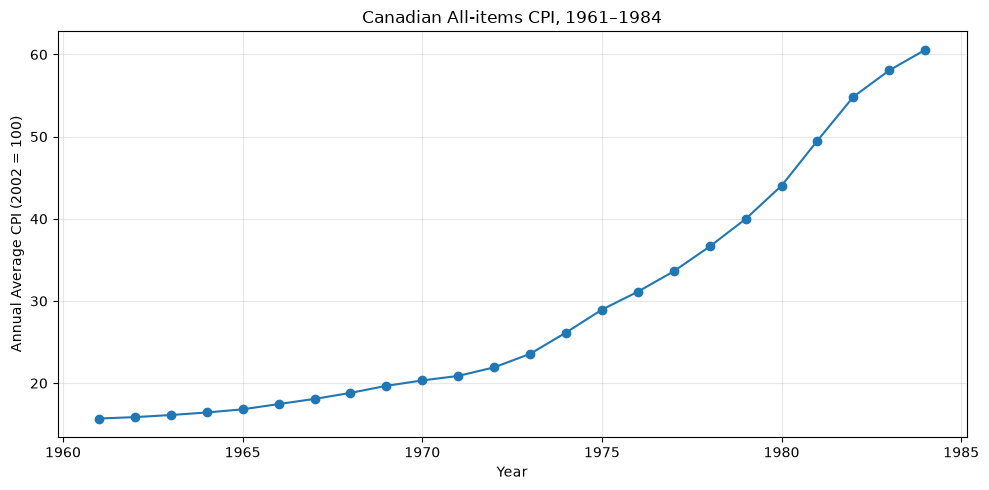

In [57]:
# ============================================================
# Annual Canadian CPI, 1961-1984
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    annual_cpi["Year"],
    annual_cpi["Annual_CPI"],
    marker="o"
)

ax.set_title("Canadian All-items CPI, 1961–1984")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Average CPI (2002 = 100)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# Merge Annual CPI with Agricultural Modeling Data
# ============================================================

farm_model_df = farm_model_df.merge(
    annual_cpi[["Year", "Annual_CPI"]],
    left_on="REF_DATE",
    right_on="Year",
    how="left",
    validate="many_to_one"
)

print("Rows after CPI merge:", len(farm_model_df))
print(
    "Missing CPI values:",
    farm_model_df["Annual_CPI"].isna().sum()
)

Rows after CPI merge: 2388
Missing CPI values: 0


In [59]:
# ============================================================
# Convert Nominal Prices to Constant 1984 Dollars
# ============================================================

BASE_YEAR = 1984

base_cpi = annual_cpi.loc[
    annual_cpi["Year"] == BASE_YEAR,
    "Annual_CPI"
].iloc[0]

real_price_col = "Real farm price (1984 dollars per tonne)"

farm_model_df[real_price_col] = (
    farm_model_df[price_col]
    * (base_cpi / farm_model_df["Annual_CPI"])
)

print(f"1984 annual average CPI: {base_cpi:.3f}")

display(
    farm_model_df[
        [
            "REF_DATE",
            "Type of crop",
            "GEO",
            price_col,
            "Annual_CPI",
            real_price_col
        ]
    ].head(10)
)

1984 annual average CPI: 60.575


,REF_DATE,Type of crop,GEO,Average farm price (dollars per tonne),Annual_CPI,Real farm price (1984 dollars per tonne)
0,1961,Barley,AB,49.0,15.7,189.055732
1,1961,Canola (rapeseed),AB,82.0,15.7,316.378981
2,1961,Flaxseed,AB,131.0,15.7,505.434713
3,1961,Mixed grains,AB,43.0,15.7,165.906051
4,1961,Mustard seed,AB,95.0,15.7,366.536624
5,1961,Oats,AB,42.0,15.7,162.047771
6,1961,"Peas, dry",AB,89.0,15.7,343.386943
7,1961,"Rye, all",AB,41.0,15.7,158.189490
8,1961,"Rye, fall remaining",AB,41.0,15.7,158.189490
9,1961,"Rye, spring",AB,41.0,15.7,158.189490


In [60]:
# ============================================================
# Validate Inflation Adjustment
# ============================================================

price_validation = farm_model_df[
    farm_model_df["REF_DATE"] == BASE_YEAR
].copy()

max_difference = (
    price_validation[price_col]
    - price_validation[real_price_col]
).abs().max()

print(
    "Maximum nominal vs. real price difference in 1984:",
    max_difference
)

print(
    "Missing real prices:",
    farm_model_df[real_price_col].isna().sum()
)

print(
    "Nonpositive real prices:",
    (farm_model_df[real_price_col] <= 0).sum()
)

Maximum nominal vs. real price difference in 1984: 0.0
Missing real prices: 0
Nonpositive real prices: 0


In [61]:
# ============================================================
# Real Farm Price Trends by Crop
# ============================================================

real_price_trends = calculate_crop_trends(
    farm_model_df,
    real_price_col
)

real_price_trends = real_price_trends.sort_values(
    "Annual_change_pct_of_mean",
    ascending=False
)

display(real_price_trends.round(4))

,Crop,Years,Slope_per_year,Mean_value,Annual_change_pct_of_mean,R_squared,P_value
2,Buckwheat,24,7.9890,258.7742,3.0872,0.5974,0.0000
8,Mustard seed,24,3.0425,379.2275,0.8023,0.0243,0.4669
17,Tame hay,24,0.5644,75.4864,0.7476,0.0836,0.1707
3,Canola (rapeseed),24,2.9607,398.9846,0.7421,0.0343,0.3863
1,"Beans, all dry (white and coloured)",24,2.6218,629.1272,0.4167,0.0132,0.5930
14,Soybeans,24,1.2684,375.3071,0.3380,0.0131,0.5943
12,"Rye, fall remaining",24,0.4423,157.8057,0.2803,0.0051,0.7406
13,"Rye, spring",24,0.3722,158.1594,0.2353,0.0031,0.7972
11,"Rye, all",24,0.2859,158.3190,0.1806,0.0026,0.8143
5,Corn for silage,24,0.0111,31.7068,0.0351,0.0004,0.9308


In [62]:
# ============================================================
# Compare Nominal and Inflation-Adjusted Price Trends
# ============================================================

price_trend_comparison = (
    price_trends[
        [
            "Crop",
            "Annual_change_pct_of_mean",
            "R_squared"
        ]
    ]
    .rename(columns={
        "Annual_change_pct_of_mean": "Nominal_Annual_Change_Pct",
        "R_squared": "Nominal_R_squared"
    })
    .merge(
        real_price_trends[
            [
                "Crop",
                "Annual_change_pct_of_mean",
                "R_squared"
            ]
        ].rename(columns={
            "Annual_change_pct_of_mean": "Real_Annual_Change_Pct",
            "R_squared": "Real_R_squared"
        }),
        on="Crop"
    )
)

price_trend_comparison["Trend_Reduction"] = (
    price_trend_comparison["Nominal_Annual_Change_Pct"]
    - price_trend_comparison["Real_Annual_Change_Pct"]
)

price_trend_comparison = price_trend_comparison.sort_values(
    "Trend_Reduction",
    ascending=False
)

display(price_trend_comparison.round(3))

,Crop,Nominal_Annual_Change_Pct,Nominal_R_squared,Real_Annual_Change_Pct,Real_R_squared,Trend_Reduction
5,Corn for silage,6.358,0.861,0.035,0.000,6.323
0,Buckwheat,9.408,0.774,3.087,0.597,6.321
14,Mixed grains,5.579,0.785,-0.642,0.055,6.221
11,"Wheat, all",5.824,0.778,-0.357,0.013,6.180
17,Oats,5.213,0.771,-0.967,0.102,6.180
13,Barley,5.580,0.768,-0.596,0.036,6.177
15,"Wheat, spring",5.501,0.743,-0.654,0.038,6.155
4,"Beans, all dry (white and coloured)",6.472,0.678,0.417,0.013,6.055
19,"Peas, dry",4.613,0.765,-1.440,0.202,6.053
10,Corn for grain,6.007,0.826,-0.017,0.000,6.024


### Inflation Adjustment and Real Farm Prices

The initial analysis identified strong positive trends in nominal farm prices for every retained crop between 1961 and 1984. Because these increases could reflect changes in the general price level rather than crop-specific market behavior, historical farm prices were adjusted using Canada's all-items Consumer Price Index (CPI).

Monthly CPI observations were converted to annual averages and merged with the agricultural dataset by year. Prices were expressed in constant **1984 dollars**, using the 1984 annual average CPI of 60.575 as the reference value.

The adjustment substantially changed the interpretation of historical farm-price behavior. Most of the strong positive nominal price trends disappeared after controlling for inflation. For example, corn for silage changed from a nominal annual trend equivalent to 6.36% of its mean price to approximately 0.04% in real terms. Similar reductions occurred for wheat, barley, oats, mixed grains, and numerous other crops.

Most inflation-adjusted crop prices consequently exhibit weak temporal trends, although some crop-specific patterns remain. Buckwheat retains a comparatively strong positive real-price trend, while peas show a statistically significant negative trend. These remaining movements may reflect crop-specific market conditions rather than general inflation.

Based on these findings, **inflation-adjusted farm price will be used as the primary target for price prediction**, while nominal farm price will be retained for descriptive interpretation. This prevents the price model from receiving artificial predictive performance simply by learning the historical increase in the general price level.

In [63]:
# ============================================================
# Yield and Inflation-Adjusted Price Dependence
# ============================================================

real_price_col = "Real farm price (1984 dollars per tonne)"

real_price_correlations = (
    farm_model_df
    .groupby("Type of crop")
    .apply(
        lambda x: x[yield_col].corr(x[real_price_col]),
        include_groups=False
    )
    .rename("Yield_Real_Price_Correlation")
    .reset_index()
)

correlation_final = (
    correlation_comparison[
        [
            "Type of crop",
            "Raw_Yield_Price_Correlation",
            "Detrended_Yield_Price_Correlation"
        ]
    ]
    .merge(
        real_price_correlations,
        on="Type of crop"
    )
)

correlation_final["Abs_Real_Price_Correlation"] = (
    correlation_final["Yield_Real_Price_Correlation"].abs()
)

correlation_final = correlation_final.sort_values(
    "Abs_Real_Price_Correlation",
    ascending=False
)

display(
    correlation_final[
        [
            "Type of crop",
            "Raw_Yield_Price_Correlation",
            "Detrended_Yield_Price_Correlation",
            "Yield_Real_Price_Correlation"
        ]
    ].round(3)
)

,Type of crop,Raw_Yield_Price_Correlation,Detrended_Yield_Price_Correlation,Yield_Real_Price_Correlation
5,Buckwheat,-0.362,-0.206,-0.430
4,Oats,0.198,-0.219,-0.327
6,Sugar beets,0.037,-0.202,-0.311
7,"Wheat, spring",0.325,-0.195,-0.303
13,"Peas, dry",0.344,-0.086,-0.243
3,Flaxseed,0.259,-0.226,-0.227
8,"Wheat, all",0.328,-0.166,-0.191
14,Barley,0.381,-0.071,-0.182
12,Mixed grains,0.184,-0.106,-0.178
0,Mustard seed,0.223,-0.362,-0.134


In [64]:
# ============================================================
# Final Dependence Summary
# ============================================================

real_corr_summary = pd.Series({
    "Mean yield-real price correlation":
        correlation_final[
            "Yield_Real_Price_Correlation"
        ].mean(),

    "Median yield-real price correlation":
        correlation_final[
            "Yield_Real_Price_Correlation"
        ].median(),

    "Negative correlations":
        (
            correlation_final[
                "Yield_Real_Price_Correlation"
            ] < 0
        ).sum(),

    "Crops with |correlation| >= 0.30":
        (
            correlation_final[
                "Yield_Real_Price_Correlation"
            ].abs() >= 0.30
        ).sum()
})

display(
    real_corr_summary
    .round(3)
    .rename("Value")
    .to_frame()
)

,Value
Mean yield-real price correlation,-0.117
Median yield-real price correlation,-0.092
Negative correlations,15.000
Crops with |correlation| >= 0.30,4.000


### Historical Relationship Between Yield and Price

Because expected gross revenue will ultimately be calculated by multiplying predicted yield by predicted farm price, the historical relationship between these variables was examined before combining the two model outputs.

Using the original nominal prices, crop-level yield-price correlations were generally positive, with a mean correlation of 0.275 and a median of 0.325. However, both yield and nominal farm prices changed substantially over time. After removing crop-specific linear time trends, the mean correlation declined to -0.080 and the median to -0.086, suggesting that much of the apparent positive association was attributable to shared temporal trends.

The relationship was then reevaluated using inflation-adjusted farm prices expressed in constant 1984 dollars. The mean yield-real-price correlation was -0.117 and the median was -0.092. Fifteen of the 21 crops exhibited negative correlations, while only four had an absolute correlation of at least 0.30. Buckwheat, oats, sugar beets, and spring wheat showed the strongest negative relationships, while most remaining crops exhibited relatively weak associations.

These results support treating yield and real farm price as separate prediction problems before combining their predictions to estimate expected gross revenue. However, yield and price are not assumed to be statistically independent. Their observed joint historical behavior will be preserved when historical revenue variability is calculated for the project's risk analysis.

In [65]:
# ============================================================
# Prepare Climate Date Variables
# ============================================================

climate_df["LOCAL_DATE"] = pd.to_datetime(
    climate_df["LOCAL_DATE"],
    errors="coerce"
)

climate_df["Year"] = climate_df["LOCAL_DATE"].dt.year
climate_df["Month"] = climate_df["LOCAL_DATE"].dt.month
climate_df["Day"] = climate_df["LOCAL_DATE"].dt.day

print("Invalid dates:", climate_df["LOCAL_DATE"].isna().sum())
print(
    "Climate period:",
    climate_df["Year"].min(),
    "-",
    climate_df["Year"].max()
)

display(
    climate_df[
        ["LOCAL_DATE", "Year", "Month", "Day"]
    ].head()
)

Invalid dates: 0
Climate period: 1940 - 2020


,LOCAL_DATE,Year,Month,Day
0,1940-01-01,1940,1,1
1,1940-01-02,1940,1,2
2,1940-01-03,1940,1,3
3,1940-01-04,1940,1,4
4,1940-01-05,1940,1,5


In [66]:
# ============================================================
# Identify Climate Variables
# ============================================================

temperature_cols = [
    col for col in climate_df.columns
    if "MEAN_TEMPERATURE" in col.upper()
]

precipitation_cols = [
    col for col in climate_df.columns
    if "TOTAL_PRECIPITATION" in col.upper()
]

print("Temperature columns:", len(temperature_cols))
for col in temperature_cols:
    print("  ", col)

print("\nPrecipitation columns:", len(precipitation_cols))
for col in precipitation_cols:
    print("  ", col)

Temperature columns: 13
   MEAN_TEMPERATURE_CALGARY
   MEAN_TEMPERATURE_EDMONTON
   MEAN_TEMPERATURE_HALIFAX
   MEAN_TEMPERATURE_MONCTON
   MEAN_TEMPERATURE_MONTREAL
   MEAN_TEMPERATURE_OTTAWA
   MEAN_TEMPERATURE_QUEBEC
   MEAN_TEMPERATURE_SASKATOON
   MEAN_TEMPERATURE_STJOHNS
   MEAN_TEMPERATURE_TORONTO
   MEAN_TEMPERATURE_VANCOUVER
   MEAN_TEMPERATURE_WHITEHORSE
   MEAN_TEMPERATURE_WINNIPEG

Precipitation columns: 13
   TOTAL_PRECIPITATION_CALGARY
   TOTAL_PRECIPITATION_EDMONTON
   TOTAL_PRECIPITATION_HALIFAX
   TOTAL_PRECIPITATION_MONCTON
   TOTAL_PRECIPITATION_MONTREAL
   TOTAL_PRECIPITATION_OTTAWA
   TOTAL_PRECIPITATION_QUEBEC
   TOTAL_PRECIPITATION_SASKATOON
   TOTAL_PRECIPITATION_STJOHNS
   TOTAL_PRECIPITATION_TORONTO
   TOTAL_PRECIPITATION_VANCOUVER
   TOTAL_PRECIPITATION_WHITEHORSE
   TOTAL_PRECIPITATION_WINNIPEG


In [67]:
# ============================================================
# Growing-Season Climate Coverage: May-September
# ============================================================

growing_season_climate = climate_df[
    climate_df["Year"].between(1961, 1984)
    & climate_df["Month"].between(5, 9)
].copy()

print(
    f"Growing-season daily records: "
    f"{len(growing_season_climate):,}"
)

print(
    "Years:",
    growing_season_climate["Year"].min(),
    "-",
    growing_season_climate["Year"].max()
)

print(
    "Expected May-September days per complete year:",
    153
)

Growing-season daily records: 3,672
Years: 1961 - 1984
Expected May-September days per complete year: 153


In [68]:
# ============================================================
# Growing-Season Climate Variable Completeness
# ============================================================

climate_feature_cols = temperature_cols + precipitation_cols

growing_season_completeness = pd.DataFrame({
    "Available": (
        growing_season_climate[climate_feature_cols]
        .notna()
        .sum()
    ),
    "Missing": (
        growing_season_climate[climate_feature_cols]
        .isna()
        .sum()
    )
})

growing_season_completeness["Percent_Available"] = (
    growing_season_completeness["Available"]
    / len(growing_season_climate)
    * 100
)

display(
    growing_season_completeness
    .sort_values("Percent_Available")
    .round(2)
)

,Available,Missing,Percent_Available
TOTAL_PRECIPITATION_SASKATOON,3671,1,99.97
TOTAL_PRECIPITATION_QUEBEC,3671,1,99.97
MEAN_TEMPERATURE_QUEBEC,3671,1,99.97
MEAN_TEMPERATURE_SASKATOON,3671,1,99.97
MEAN_TEMPERATURE_CALGARY,3672,0,100.00
TOTAL_PRECIPITATION_VANCOUVER,3672,0,100.00
TOTAL_PRECIPITATION_TORONTO,3672,0,100.00
TOTAL_PRECIPITATION_STJOHNS,3672,0,100.00
TOTAL_PRECIPITATION_OTTAWA,3672,0,100.00
TOTAL_PRECIPITATION_MONTREAL,3672,0,100.00


In [69]:
# ============================================================
# Climate Completeness by Year
# ============================================================

annual_climate_completeness = (
    growing_season_climate
    .groupby("Year")[climate_feature_cols]
    .agg(lambda x: x.notna().mean() * 100)
)

display(annual_climate_completeness.round(1))

,MEAN_TEMPERATURE_CALGARY,MEAN_TEMPERATURE_EDMONTON,MEAN_TEMPERATURE_HALIFAX,MEAN_TEMPERATURE_MONCTON,MEAN_TEMPERATURE_MONTREAL,MEAN_TEMPERATURE_OTTAWA,MEAN_TEMPERATURE_QUEBEC,MEAN_TEMPERATURE_SASKATOON,MEAN_TEMPERATURE_STJOHNS,MEAN_TEMPERATURE_TORONTO,MEAN_TEMPERATURE_VANCOUVER,MEAN_TEMPERATURE_WHITEHORSE,MEAN_TEMPERATURE_WINNIPEG,TOTAL_PRECIPITATION_CALGARY,TOTAL_PRECIPITATION_EDMONTON,TOTAL_PRECIPITATION_HALIFAX,TOTAL_PRECIPITATION_MONCTON,TOTAL_PRECIPITATION_MONTREAL,TOTAL_PRECIPITATION_OTTAWA,TOTAL_PRECIPITATION_QUEBEC,TOTAL_PRECIPITATION_SASKATOON,TOTAL_PRECIPITATION_STJOHNS,TOTAL_PRECIPITATION_TORONTO,TOTAL_PRECIPITATION_VANCOUVER,TOTAL_PRECIPITATION_WHITEHORSE,TOTAL_PRECIPITATION_WINNIPEG
Year,,,,,,,,,,,,,,,,,,,,,,,,,,
1961,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1962,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1963,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1964,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1965,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1966,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1967,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1968,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1969,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


## Climate Data Preparation and Feature Engineering

Daily climate observations were prepared for integration with the agricultural dataset. Because agricultural production is more directly influenced by weather conditions during the crop-growing period than by full-calendar-year averages, climate feature engineering focuses on a common **May–September growing season**.

The use of a common growing season provides a consistent definition across crops and provinces while avoiding assumptions about precise historical planting and harvest dates that are not available in the source data. This simplification will be documented as a limitation because growing seasons vary by crop, province, and year.

Daily temperature and precipitation observations will be aggregated into province-year climate features before being merged with the agricultural data. In addition to seasonal averages and totals, engineered features will capture climate variability and extreme conditions that may contain predictive information not represented by seasonal averages alone.

### Growing-Season Climate Coverage

Climate coverage during the selected 1961–1984 modeling period is exceptionally complete. Restricting the data to the May–September growing season produced 3,672 daily observations, corresponding exactly to 153 growing-season days across each of the 24 study years.

Nearly all temperature and precipitation series are 100% complete during this period. Only four individual values are missing: one temperature and precipitation observation for Quebec in 1979 and one temperature and precipitation observation for Saskatoon in 1983. Each affected annual series therefore retains 152 of 153 growing-season observations (99.3% completeness).

Because these isolated missing observations represent less than 1% of the corresponding growing season, daily values will not be imputed. Seasonal features will instead be calculated from the available observations, with observation counts retained to verify aggregation completeness. This avoids introducing artificial daily weather values while preserving otherwise complete province-year climate histories.

In [70]:
# ============================================================
# Reshape Daily Climate Data to Long Format
# ============================================================

climate_long_parts = []

cities = [
    col.replace("MEAN_TEMPERATURE_", "")
    for col in temperature_cols
]

for city in cities:

    temp_col = f"MEAN_TEMPERATURE_{city}"
    precip_col = f"TOTAL_PRECIPITATION_{city}"

    city_data = growing_season_climate[
        ["LOCAL_DATE", "Year", "Month", temp_col, precip_col]
    ].copy()

    city_data["City"] = city

    city_data = city_data.rename(columns={
        temp_col: "Mean_Temperature",
        precip_col: "Total_Precipitation"
    })

    climate_long_parts.append(city_data)

climate_long_df = pd.concat(
    climate_long_parts,
    ignore_index=True
)

climate_long_df = climate_long_df[
    [
        "LOCAL_DATE",
        "Year",
        "Month",
        "City",
        "Mean_Temperature",
        "Total_Precipitation"
    ]
]

print("Long climate dataset shape:", climate_long_df.shape)
print("Cities:", climate_long_df["City"].nunique())
print("Years:", climate_long_df["Year"].nunique())

display(climate_long_df.head(10))

Long climate dataset shape: (47736, 6)
Cities: 13
Years: 24


,LOCAL_DATE,Year,Month,City,Mean_Temperature,Total_Precipitation
0,1961-05-01,1961,5,CALGARY,8.9,0.0
1,1961-05-02,1961,5,CALGARY,6.4,14.0
2,1961-05-03,1961,5,CALGARY,7.5,1.0
3,1961-05-04,1961,5,CALGARY,6.4,0.0
4,1961-05-05,1961,5,CALGARY,6.2,0.0
5,1961-05-06,1961,5,CALGARY,2.5,1.8
6,1961-05-07,1961,5,CALGARY,1.4,1.5
7,1961-05-08,1961,5,CALGARY,1.1,4.6
8,1961-05-09,1961,5,CALGARY,1.4,1.3
9,1961-05-10,1961,5,CALGARY,1.4,2.3


In [71]:
# ============================================================
# Validate Long-Format Climate Data
# ============================================================

long_validation = pd.Series({
    "Rows": len(climate_long_df),
    "Duplicate city-date rows":
        climate_long_df.duplicated(
            subset=["LOCAL_DATE", "City"]
        ).sum(),
    "Missing temperature":
        climate_long_df["Mean_Temperature"].isna().sum(),
    "Missing precipitation":
        climate_long_df["Total_Precipitation"].isna().sum(),
    "Cities":
        climate_long_df["City"].nunique(),
    "Years":
        climate_long_df["Year"].nunique()
})

display(long_validation.rename("Value").to_frame())

,Value
Rows,47736
Duplicate city-date rows,0
Missing temperature,2
Missing precipitation,2
Cities,13
Years,24


In [72]:
# ============================================================
# Map Climate Cities to Agricultural Provinces
# ============================================================

city_to_province = {
    "CALGARY": "AB",
    "EDMONTON": "AB",

    "VANCOUVER": "BC",

    "WINNIPEG": "MA",

    "MONCTON": "NB",

    "HALIFAX": "NS",

    "OTTAWA": "ON",
    "TORONTO": "ON",

    "MONTREAL": "QU",
    "QUEBEC": "QU",

    "SASKATOON": "SK",

    # No direct agricultural observations retained for these
    # climate locations in the modeling population.
    "STJOHNS": "NL",
    "WHITEHORSE": "YT"
}

climate_long_df["GEO"] = (
    climate_long_df["City"]
    .map(city_to_province)
)

print("Unmapped climate cities:")
print(
    climate_long_df.loc[
        climate_long_df["GEO"].isna(),
        "City"
    ].unique()
)

print("\nCity-to-province mapping:")
display(
    climate_long_df[
        ["City", "GEO"]
    ]
    .drop_duplicates()
    .sort_values(["GEO", "City"])
)

Unmapped climate cities:
<ArrowStringArray>
[]
Length: 0, dtype: str

City-to-province mapping:


,City,GEO
0,CALGARY,AB
3672,EDMONTON,AB
36720,VANCOUVER,BC
44064,WINNIPEG,MA
11016,MONCTON,NB
29376,STJOHNS,NL
7344,HALIFAX,NS
18360,OTTAWA,ON
33048,TORONTO,ON
14688,MONTREAL,QU


In [73]:
# ============================================================
# Create Daily Province-Level Climate
# ============================================================

province_daily_climate = (
    climate_long_df[
        climate_long_df["GEO"].isin(
            ["AB", "BC", "MA", "NB", "NS", "ON", "QU", "SK"]
        )
    ]
    .groupby(
        ["LOCAL_DATE", "Year", "Month", "GEO"],
        as_index=False
    )
    .agg(
        Mean_Temperature=("Mean_Temperature", "mean"),
        Total_Precipitation=("Total_Precipitation", "mean"),
        Stations_Reporting_Temp=("Mean_Temperature", "count"),
        Stations_Reporting_Precip=("Total_Precipitation", "count")
    )
)

print("Province-level daily rows:", len(province_daily_climate))
print(
    "Provinces:",
    sorted(province_daily_climate["GEO"].unique())
)

display(province_daily_climate.head(10))

Province-level daily rows: 29376
Provinces: ['AB', 'BC', 'MA', 'NB', 'NS', 'ON', 'QU', 'SK']


,LOCAL_DATE,Year,Month,GEO,Mean_Temperature,Total_Precipitation,Stations_Reporting_Temp,Stations_Reporting_Precip
0,1961-05-01,1961,5,AB,10.55,0.00,2,2
1,1961-05-01,1961,5,BC,12.00,17.00,1,1
2,1961-05-01,1961,5,MA,0.00,0.00,1,1
3,1961-05-01,1961,5,NB,2.50,0.00,1,1
4,1961-05-01,1961,5,NS,2.80,0.00,1,1
5,1961-05-01,1961,5,ON,6.95,3.45,2,2
6,1961-05-01,1961,5,QU,8.05,2.15,2,2
7,1961-05-01,1961,5,SK,7.00,0.00,1,1
8,1961-05-02,1961,5,AB,9.05,7.00,2,2
9,1961-05-02,1961,5,BC,12.00,0.30,1,1


In [74]:
# ============================================================
# Engineer Daily Climate Indicators
# ============================================================

province_daily_climate["Warm_Day"] = (
    province_daily_climate["Mean_Temperature"] >= 20
).astype(int)

province_daily_climate["Dry_Day"] = (
    province_daily_climate["Total_Precipitation"] < 1
).astype(int)

province_daily_climate["Heavy_Precip_Day"] = (
    province_daily_climate["Total_Precipitation"] >= 10
).astype(int)

display(
    province_daily_climate[
        [
            "LOCAL_DATE",
            "GEO",
            "Mean_Temperature",
            "Total_Precipitation",
            "Warm_Day",
            "Dry_Day",
            "Heavy_Precip_Day"
        ]
    ].head(10)
)

,LOCAL_DATE,GEO,Mean_Temperature,Total_Precipitation,Warm_Day,Dry_Day,Heavy_Precip_Day
0,1961-05-01,AB,10.55,0.00,0,1,0
1,1961-05-01,BC,12.00,17.00,0,0,1
2,1961-05-01,MA,0.00,0.00,0,1,0
3,1961-05-01,NB,2.50,0.00,0,1,0
4,1961-05-01,NS,2.80,0.00,0,1,0
5,1961-05-01,ON,6.95,3.45,0,0,0
6,1961-05-01,QU,8.05,2.15,0,0,0
7,1961-05-01,SK,7.00,0.00,0,1,0
8,1961-05-02,AB,9.05,7.00,0,0,0
9,1961-05-02,BC,12.00,0.30,0,1,0


In [75]:
# ============================================================
# Helper Function: Maximum Consecutive Dry Days
# ============================================================

def max_consecutive_days(values):
    """
    Return the maximum number of consecutive observations
    equal to 1 in a binary sequence.
    """
    max_run = 0
    current_run = 0

    for value in values:
        if value == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0

    return max_run

In [76]:
# ============================================================
# Aggregate Growing-Season Climate by Province and Year
# ============================================================

climate_features_df = (
    province_daily_climate
    .sort_values(["GEO", "Year", "LOCAL_DATE"])
    .groupby(["GEO", "Year"])
    .agg(
        Growing_Mean_Temp=(
            "Mean_Temperature", "mean"
        ),
        Growing_Temp_SD=(
            "Mean_Temperature", "std"
        ),
        Growing_Total_Precip=(
            "Total_Precipitation", "sum"
        ),
        Growing_Precip_SD=(
            "Total_Precipitation", "std"
        ),
        Warm_Days=(
            "Warm_Day", "sum"
        ),
        Dry_Days=(
            "Dry_Day", "sum"
        ),
        Heavy_Precip_Days=(
            "Heavy_Precip_Day", "sum"
        ),
        Climate_Days=(
            "LOCAL_DATE", "count"
        )
    )
    .reset_index()
)

# Calculate maximum consecutive dry days separately.
dry_runs = (
    province_daily_climate
    .sort_values(["GEO", "Year", "LOCAL_DATE"])
    .groupby(["GEO", "Year"])["Dry_Day"]
    .apply(max_consecutive_days)
    .rename("Max_Consecutive_Dry_Days")
    .reset_index()
)

climate_features_df = climate_features_df.merge(
    dry_runs,
    on=["GEO", "Year"],
    how="left"
)

print("Climate feature dataset shape:")
print(climate_features_df.shape)

display(climate_features_df.head(10))

Climate feature dataset shape:
(192, 11)


,GEO,Year,Growing_Mean_Temp,Growing_Temp_SD,Growing_Total_Precip,Growing_Precip_SD,Warm_Days,Dry_Days,Heavy_Precip_Days,Climate_Days,Max_Consecutive_Dry_Days
0,AB,1961,14.522876,5.740857,250.75,3.906810,24,113,6,153,16
1,AB,1962,13.103268,3.963844,303.55,3.707583,3,98,10,153,18
2,AB,1963,14.310784,4.419384,296.00,4.485768,12,106,8,153,14
3,AB,1964,12.908170,4.210839,312.80,4.218722,6,94,7,153,12
4,AB,1965,12.051961,5.484664,453.95,5.386530,7,87,14,153,14
5,AB,1966,12.881046,3.366143,292.85,4.211581,0,100,11,153,14
6,AB,1967,13.654248,4.638043,158.50,2.914316,5,125,4,153,33
7,AB,1968,12.002288,4.109085,255.75,3.802214,5,101,4,153,10
8,AB,1969,12.802288,4.082969,314.60,4.581636,5,109,12,153,11
9,AB,1970,13.840196,4.725268,279.35,5.297374,11,113,6,153,13


In [77]:
# ============================================================
# Validate Province-Year Climate Features
# ============================================================

climate_feature_validation = pd.Series({
    "Rows": len(climate_features_df),
    "Province-year duplicates":
        climate_features_df.duplicated(
            subset=["GEO", "Year"]
        ).sum(),
    "Years":
        climate_features_df["Year"].nunique(),
    "Provinces":
        climate_features_df["GEO"].nunique(),
    "Missing feature values":
        climate_features_df.isna().sum().sum(),
    "Minimum climate days":
        climate_features_df["Climate_Days"].min(),
    "Maximum climate days":
        climate_features_df["Climate_Days"].max()
})

display(
    climate_feature_validation
    .rename("Value")
    .to_frame()
)

,Value
Rows,192
Province-year duplicates,0
Years,24
Provinces,8
Missing feature values,0
Minimum climate days,153
Maximum climate days,153


### Growing-Season Climate Feature Engineering

Daily climate observations were transformed from city-level measurements into province-level growing-season features for integration with the agricultural data. Where multiple climate stations were available within a province, their daily measurements were averaged before seasonal aggregation. This approach provides broader regional representation while avoiding the incorrect accumulation of precipitation across multiple stations.

Eight provinces have direct climate representation during the study period: Alberta, British Columbia, Manitoba, New Brunswick, Nova Scotia, Ontario, Quebec, and Saskatchewan. Prince Edward Island does not have a directly corresponding climate station and is therefore retained in agricultural descriptive analysis but excluded from the climate-enhanced modeling population.

For each province and year, May–September observations were summarized using mean temperature, temperature variability, total precipitation, precipitation variability, warm-day counts, dry-day counts, heavy-precipitation-day counts, and maximum consecutive dry days. Warm days were defined as days with a mean temperature of at least 20°C, dry days as days receiving less than 1 mm of precipitation, and heavy-precipitation days as days receiving at least 10 mm. These thresholds are analytical features rather than universal agronomic definitions.

The resulting climate feature dataset contains **192 province-year observations**, representing eight provinces across all 24 years from 1961 through 1984. No duplicate province-year combinations or missing engineered features remain, and all province-year records contain the expected 153 growing-season days.

In [78]:
# ============================================================
# Climate Feature Descriptive Statistics
# ============================================================

climate_feature_cols = [
    "Growing_Mean_Temp",
    "Growing_Temp_SD",
    "Growing_Total_Precip",
    "Growing_Precip_SD",
    "Warm_Days",
    "Dry_Days",
    "Heavy_Precip_Days",
    "Max_Consecutive_Dry_Days"
]

display(
    climate_features_df[
        climate_feature_cols
    ]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
Growing_Mean_Temp,192.0,15.17,1.21,12.00,14.56,15.17,16.00,18.09
Growing_Temp_SD,192.0,4.60,0.91,2.21,4.23,4.69,5.12,7.11
Growing_Total_Precip,192.0,374.30,130.69,135.70,277.52,349.38,470.34,792.60
Growing_Precip_SD,192.0,5.83,2.09,2.76,4.39,5.62,6.78,20.94
Warm_Days,192.0,24.91,15.66,0.00,12.00,24.00,34.00,69.00
Dry_Days,192.0,106.68,11.74,74.00,99.00,107.00,116.00,132.00
Heavy_Precip_Days,192.0,11.61,5.12,2.00,7.00,11.00,15.00,24.00
Max_Consecutive_Dry_Days,192.0,15.38,6.99,5.00,11.00,13.00,17.25,39.00


In [79]:
# ============================================================
# Average Growing-Season Climate by Province
# ============================================================

province_climate_summary = (
    climate_features_df
    .groupby("GEO")[climate_feature_cols]
    .mean()
    .round(2)
)

display(province_climate_summary)

,Growing_Mean_Temp,Growing_Temp_SD,Growing_Total_Precip,Growing_Precip_SD,Warm_Days,Dry_Days,Heavy_Precip_Days,Max_Consecutive_Dry_Days
GEO,,,,,,,,
AB,13.09,4.37,309.93,4.25,6.71,99.96,8.12,14.00
BC,15.11,2.84,248.29,4.28,7.12,118.88,8.08,26.38
MA,15.64,5.55,351.56,6.42,36.92,113.83,10.75,16.75
NB,14.72,4.80,453.15,6.90,22.12,104.21,15.04,12.12
NS,14.86,4.57,508.68,8.54,20.42,107.42,15.50,13.50
ON,16.88,4.78,386.20,5.23,43.62,99.25,12.08,11.33
QU,16.17,4.71,498.69,6.32,36.42,91.58,17.00,9.29
SK,14.87,5.19,237.88,4.69,25.92,118.33,6.33,19.62


,Growing_Mean_Temp,Growing_Temp_SD,Growing_Total_Precip,Growing_Precip_SD,Warm_Days,Dry_Days,Heavy_Precip_Days,Max_Consecutive_Dry_Days
Growing_Mean_Temp,1.00,0.18,0.15,0.10,0.79,-0.05,0.21,-0.10
Growing_Temp_SD,0.18,1.00,0.12,0.17,0.66,-0.05,0.06,-0.26
Growing_Total_Precip,0.15,0.12,1.00,0.81,0.18,-0.65,0.90,-0.52
Growing_Precip_SD,0.10,0.17,0.81,1.00,0.12,-0.19,0.63,-0.25
Warm_Days,0.79,0.66,0.18,0.12,1.00,-0.17,0.19,-0.27
Dry_Days,-0.05,-0.05,-0.65,-0.19,-0.17,1.00,-0.58,0.69
Heavy_Precip_Days,0.21,0.06,0.90,0.63,0.19,-0.58,1.00,-0.42
Max_Consecutive_Dry_Days,-0.10,-0.26,-0.52,-0.25,-0.27,0.69,-0.42,1.00


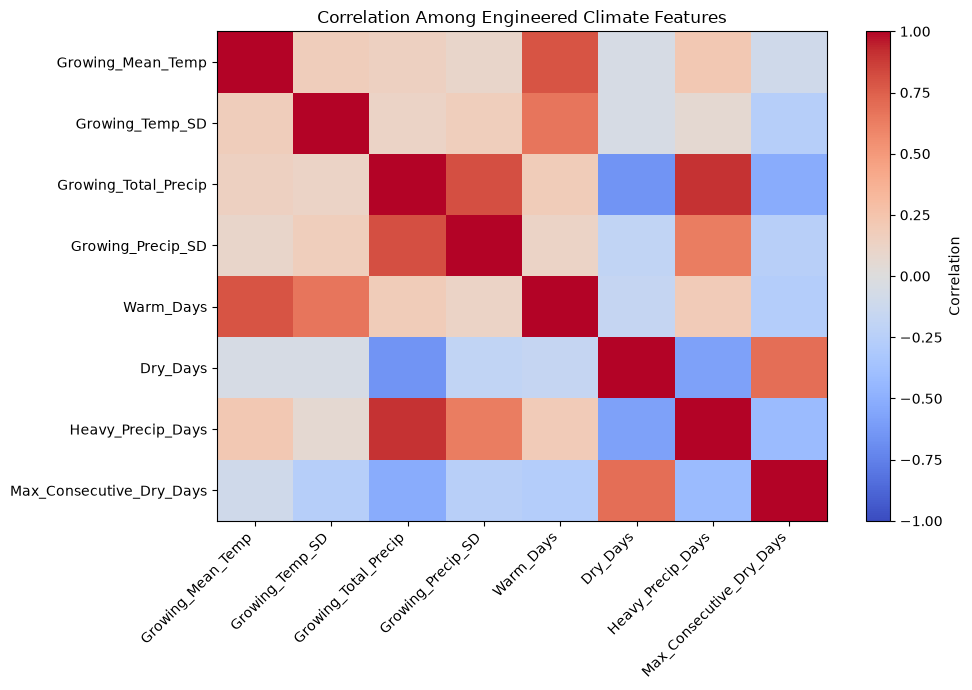

In [80]:
# ============================================================
# Climate Feature Correlations
# ============================================================

climate_corr = (
    climate_features_df[climate_feature_cols]
    .corr()
)

display(climate_corr.round(2))

plt.figure(figsize=(10, 7))

plt.imshow(
    climate_corr,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(climate_feature_cols)),
    climate_feature_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(climate_feature_cols)),
    climate_feature_cols
)

plt.title("Correlation Among Engineered Climate Features")
plt.tight_layout()
plt.show()

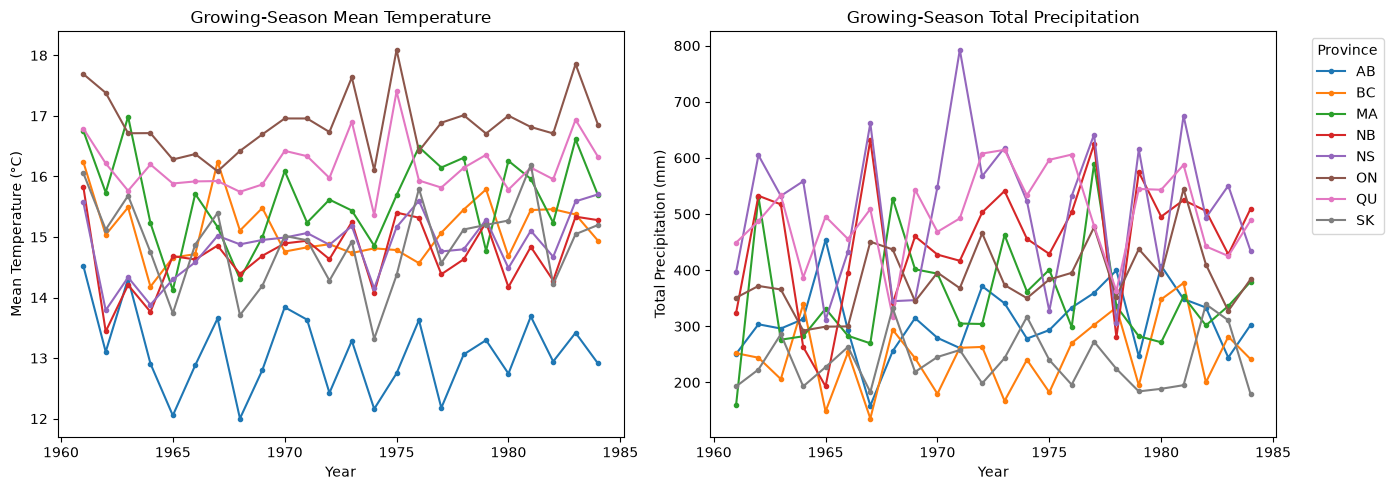

In [81]:
# ============================================================
# Growing-Season Temperature and Precipitation by Province
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for province in sorted(climate_features_df["GEO"].unique()):
    province_data = climate_features_df[
        climate_features_df["GEO"] == province
    ]

    axes[0].plot(
        province_data["Year"],
        province_data["Growing_Mean_Temp"],
        marker="o",
        markersize=3,
        label=province
    )

    axes[1].plot(
        province_data["Year"],
        province_data["Growing_Total_Precip"],
        marker="o",
        markersize=3,
        label=province
    )

axes[0].set_title("Growing-Season Mean Temperature")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean Temperature (°C)")

axes[1].set_title("Growing-Season Total Precipitation")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Precipitation (mm)")

axes[1].legend(
    title="Province",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [82]:
# ============================================================
# Quantify Climate-Supported Modeling Population
# ============================================================

climate_supported_provinces = sorted(
    climate_features_df["GEO"].unique()
)

pei_rows = (
    farm_model_df["GEO"] == "PEI"
).sum()

climate_supported_rows = (
    farm_model_df["GEO"]
    .isin(climate_supported_provinces)
    .sum()
)

print(f"Current farm modeling rows: {len(farm_model_df):,}")
print(f"PEI rows without direct climate coverage: {pei_rows:,}")
print(
    f"Rows with direct climate coverage: "
    f"{climate_supported_rows:,}"
)
print(
    f"Percent retained for climate modeling: "
    f"{climate_supported_rows / len(farm_model_df) * 100:.2f}%"
)

Current farm modeling rows: 2,388
PEI rows without direct climate coverage: 134
Rows with direct climate coverage: 2,254
Percent retained for climate modeling: 94.39%


### Climate EDA Findings and Feature Selection

The engineered climate variables demonstrate substantial geographic and year-to-year variation during the 1961–1984 study period. Average growing-season temperature varies across provinces, while precipitation patterns show particularly large regional differences. Saskatchewan and British Columbia have comparatively low average growing-season precipitation, whereas Quebec, Nova Scotia, and New Brunswick are substantially wetter. The annual temperature and precipitation plots also demonstrate considerable year-to-year variability, providing potentially useful information for explaining fluctuations in agricultural yield.

Correlation analysis identified some expected relationships among the engineered climate variables. Growing-season total precipitation is strongly correlated with heavy-precipitation-day count (r = 0.90) and is also associated with precipitation variability (r = 0.81). Mean temperature and warm-day count are moderately strongly correlated (r = 0.79).

Because heavy-precipitation-day count provides information that is highly redundant with total seasonal precipitation, it will be excluded from the primary modeling feature set. Total precipitation is retained because it provides a more direct and interpretable measure of overall growing-season moisture. Other moderately correlated features are retained because they represent conceptually distinct characteristics, such as average conditions, variability, frequency, and persistence of dry periods.

The climate time-series plots do not reveal a uniform trend across provinces. This is not problematic for the predictive objective because the climate variables are primarily intended to capture regional differences and year-to-year growing-season weather variation rather than estimate long-term climate change.

In [83]:
# ============================================================
# Define Final Climate Feature Set
# ============================================================

climate_model_features = [
    "Growing_Mean_Temp",
    "Growing_Temp_SD",
    "Growing_Total_Precip",
    "Growing_Precip_SD",
    "Warm_Days",
    "Dry_Days",
    "Max_Consecutive_Dry_Days"
]

print("Climate predictors retained:")
for feature in climate_model_features:
    print(" -", feature)

Climate predictors retained:
 - Growing_Mean_Temp
 - Growing_Temp_SD
 - Growing_Total_Precip
 - Growing_Precip_SD
 - Warm_Days
 - Dry_Days
 - Max_Consecutive_Dry_Days


In [84]:
# ============================================================
# Create Climate-Supported Agricultural Population
# ============================================================

climate_supported_provinces = sorted(
    climate_features_df["GEO"].unique()
)

climate_model_df = (
    farm_model_df[
        farm_model_df["GEO"].isin(
            climate_supported_provinces
        )
    ]
    .copy()
)

print(f"Farm modeling rows: {len(farm_model_df):,}")
print(
    f"Climate-supported rows: "
    f"{len(climate_model_df):,}"
)
print(
    f"Rows excluded without direct climate coverage: "
    f"{len(farm_model_df) - len(climate_model_df):,}"
)

Farm modeling rows: 2,388
Climate-supported rows: 2,254
Rows excluded without direct climate coverage: 134


In [85]:
# ============================================================
# Merge Agricultural and Climate Features
# ============================================================

climate_model_df = climate_model_df.merge(
    climate_features_df[
        ["GEO", "Year"] + climate_model_features
    ],
    left_on=["GEO", "REF_DATE"],
    right_on=["GEO", "Year"],
    how="left",
    validate="many_to_one"
)

print("Merged dataset shape:")
print(climate_model_df.shape)

display(
    climate_model_df[
        [
            "REF_DATE",
            "GEO",
            "Type of crop",
            yield_col,
            real_price_col
        ] + climate_model_features
    ].head(10)
)

Merged dataset shape:
(2254, 20)


,REF_DATE,GEO,Type of crop,Average yield (kilograms per hectare),Real farm price (1984 dollars per tonne),Growing_Mean_Temp,Growing_Temp_SD,Growing_Total_Precip,Growing_Precip_SD,Warm_Days,Dry_Days,Max_Consecutive_Dry_Days
0,1961,AB,Barley,1445.0,189.055732,14.522876,5.740857,250.75,3.90681,24,113,16
1,1961,AB,Canola (rapeseed),960.0,316.378981,14.522876,5.740857,250.75,3.90681,24,113,16
2,1961,AB,Flaxseed,695.0,505.434713,14.522876,5.740857,250.75,3.90681,24,113,16
3,1961,AB,Mixed grains,1520.0,165.906051,14.522876,5.740857,250.75,3.90681,24,113,16
4,1961,AB,Mustard seed,265.0,366.536624,14.522876,5.740857,250.75,3.90681,24,113,16
5,1961,AB,Oats,1405.0,162.047771,14.522876,5.740857,250.75,3.90681,24,113,16
6,1961,AB,"Peas, dry",985.0,343.386943,14.522876,5.740857,250.75,3.90681,24,113,16
7,1961,AB,"Rye, all",830.0,158.189490,14.522876,5.740857,250.75,3.90681,24,113,16
8,1961,AB,"Rye, fall remaining",885.0,158.189490,14.522876,5.740857,250.75,3.90681,24,113,16
9,1961,AB,"Rye, spring",510.0,158.189490,14.522876,5.740857,250.75,3.90681,24,113,16


In [86]:
# ============================================================
# Validate Agriculture-Climate Merge
# ============================================================

merge_validation = pd.Series({
    "Rows before merge": 2254,
    "Rows after merge": len(climate_model_df),

    "Duplicate crop-province-year combinations":
        climate_model_df.duplicated(
            subset=[
                "REF_DATE",
                "GEO",
                "Type of crop"
            ]
        ).sum(),

    "Rows missing any climate feature":
        climate_model_df[
            climate_model_features
        ].isna().any(axis=1).sum(),

    "Years":
        climate_model_df["REF_DATE"].nunique(),

    "Provinces":
        climate_model_df["GEO"].nunique(),

    "Crops":
        climate_model_df[
            "Type of crop"
        ].nunique()
})

display(
    merge_validation
    .rename("Value")
    .to_frame()
)

,Value
Rows before merge,2254
Rows after merge,2254
Duplicate crop-province-year combinations,0
Rows missing any climate feature,0
Years,24
Provinces,8
Crops,21


In [87]:
# ============================================================
# Spot Check Province-Year Climate Assignment
# ============================================================

spot_check = climate_model_df[
    (climate_model_df["GEO"] == "AB")
    & (climate_model_df["REF_DATE"] == 1961)
][
    [
        "Type of crop",
        "Growing_Mean_Temp",
        "Growing_Total_Precip",
        "Dry_Days",
        "Max_Consecutive_Dry_Days"
    ]
]

display(spot_check)

,Type of crop,Growing_Mean_Temp,Growing_Total_Precip,Dry_Days,Max_Consecutive_Dry_Days
0,Barley,14.522876,250.75,113,16
1,Canola (rapeseed),14.522876,250.75,113,16
2,Flaxseed,14.522876,250.75,113,16
3,Mixed grains,14.522876,250.75,113,16
4,Mustard seed,14.522876,250.75,113,16
5,Oats,14.522876,250.75,113,16
6,"Peas, dry",14.522876,250.75,113,16
7,"Rye, all",14.522876,250.75,113,16
8,"Rye, fall remaining",14.522876,250.75,113,16
9,"Rye, spring",14.522876,250.75,113,16


### Agricultural and Climate Data Integration

The engineered growing-season climate features were merged with agricultural observations using province and year. Prince Edward Island was excluded from the climate-enhanced modeling population because no directly corresponding climate station is available in the climate dataset. Rather than introduce an unverified geographic proxy, only provinces with direct climate representation were retained.

This reduced the predictive modeling population from 2,388 to **2,254 observations**, retaining **94.39%** of the otherwise eligible agricultural records.

The merge used a many-to-one validation rule, ensuring that each agricultural crop-province-year observation was linked to exactly one province-year climate record without multiplying agricultural observations. Post-merge validation confirmed that the agricultural row count was preserved and that all retained observations received complete growing-season climate features.

In [88]:
# ============================================================
# Sort Data for Historical Feature Engineering
# ============================================================

model_df = (
    climate_model_df
    .sort_values(
        ["Type of crop", "GEO", "REF_DATE"]
    )
    .reset_index(drop=True)
    .copy()
)

yield_target = "Average yield (kilograms per hectare)"
price_target = "Real farm price (1984 dollars per tonne)"

print("Modeling rows:", len(model_df))
print(
    "Unique crop-province series:",
    model_df[
        ["Type of crop", "GEO"]
    ].drop_duplicates().shape[0]
)

Modeling rows: 2254
Unique crop-province series: 118


In [89]:
# ============================================================
# Create One-Year Lag Features
# ============================================================

group_cols = ["Type of crop", "GEO"]

model_df["Yield_Lag_1"] = (
    model_df
    .groupby(group_cols)[yield_target]
    .shift(1)
)

model_df["Real_Price_Lag_1"] = (
    model_df
    .groupby(group_cols)[price_target]
    .shift(1)
)

In [90]:
# ============================================================
# Create Leakage-Safe Rolling Historical Features
# ============================================================

model_df["Yield_Rolling_3"] = (
    model_df
    .groupby(group_cols)[yield_target]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(window=3, min_periods=2)
            .mean()
        )
    )
)

model_df["Real_Price_Rolling_3"] = (
    model_df
    .groupby(group_cols)[price_target]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(window=3, min_periods=2)
            .mean()
        )
    )
)

In [91]:
# ============================================================
# Create Time Trend Feature
# ============================================================

model_df["Years_Since_1961"] = (
    model_df["REF_DATE"] - 1961
)

display(
    model_df[
        [
            "REF_DATE",
            "Years_Since_1961",
            "Type of crop",
            "GEO",
            yield_target,
            "Yield_Lag_1",
            "Yield_Rolling_3",
            price_target,
            "Real_Price_Lag_1",
            "Real_Price_Rolling_3"
        ]
    ].head(15)
)

,REF_DATE,Years_Since_1961,Type of crop,GEO,Average yield (kilograms per hectare),Yield_Lag_1,Yield_Rolling_3,Real farm price (1984 dollars per tonne),Real_Price_Lag_1,Real_Price_Rolling_3
0,1961,0,Barley,AB,1445.0,NaN,NaN,189.055732,NaN,NaN
1,1962,1,Barley,AB,1685.0,1445.0,NaN,164.163340,189.055732,NaN
2,1963,2,Barley,AB,1880.0,1685.0,1565.000000,161.533333,164.163340,176.609536
3,1964,3,Barley,AB,1735.0,1880.0,1670.000000,165.874746,161.533333,171.584135
4,1965,4,Barley,AB,1825.0,1735.0,1766.666667,169.297820,165.874746,163.857140
5,1966,5,Barley,AB,2205.0,1825.0,1813.333333,163.075418,169.297820,165.568633
6,1967,6,Barley,AB,1735.0,2205.0,1921.666667,130.641014,163.075418,166.082661
7,1968,7,Barley,AB,2060.0,1735.0,1921.666667,119.111160,130.641014,154.338084
8,1969,8,Barley,AB,2150.0,2060.0,2000.000000,86.205845,119.111160,137.609197
9,1970,9,Barley,AB,2260.0,2150.0,1981.666667,95.331148,86.205845,111.986006


In [92]:
# ============================================================
# Spot Check Historical Features
# ============================================================

historical_spot_check = model_df[
    (model_df["GEO"] == "AB")
    & (model_df["Type of crop"] == "Barley")
][
    [
        "REF_DATE",
        yield_target,
        "Yield_Lag_1",
        "Yield_Rolling_3",
        price_target,
        "Real_Price_Lag_1",
        "Real_Price_Rolling_3"
    ]
]

display(historical_spot_check)

,REF_DATE,Average yield (kilograms per hectare),Yield_Lag_1,Yield_Rolling_3,Real farm price (1984 dollars per tonne),Real_Price_Lag_1,Real_Price_Rolling_3
0,1961,1445.0,NaN,NaN,189.055732,NaN,NaN
1,1962,1685.0,1445.0,NaN,164.163340,189.055732,NaN
2,1963,1880.0,1685.0,1565.000000,161.533333,164.163340,176.609536
3,1964,1735.0,1880.0,1670.000000,165.874746,161.533333,171.584135
4,1965,1825.0,1735.0,1766.666667,169.297820,165.874746,163.857140
5,1966,2205.0,1825.0,1813.333333,163.075418,169.297820,165.568633
6,1967,1735.0,2205.0,1921.666667,130.641014,163.075418,166.082661
7,1968,2060.0,1735.0,1921.666667,119.111160,130.641014,154.338084
8,1969,2150.0,2060.0,2000.000000,86.205845,119.111160,137.609197
9,1970,2260.0,2150.0,1981.666667,95.331148,86.205845,111.986006


In [93]:
# ============================================================
# Historical Feature Availability
# ============================================================

historical_features = [
    "Yield_Lag_1",
    "Yield_Rolling_3",
    "Real_Price_Lag_1",
    "Real_Price_Rolling_3"
]

historical_feature_missingness = pd.DataFrame({
    "Missing": model_df[
        historical_features
    ].isna().sum(),

    "Percent_Missing": (
        model_df[
            historical_features
        ].isna().mean() * 100
    )
})

display(
    historical_feature_missingness.round(2)
)

,Missing,Percent_Missing
Yield_Lag_1,118,5.24
Yield_Rolling_3,236,10.47
Real_Price_Lag_1,118,5.24
Real_Price_Rolling_3,236,10.47


In [94]:
# ============================================================
# Historical Feature Missingness by Year
# ============================================================

missing_by_year = (
    model_df
    .groupby("REF_DATE")[historical_features]
    .apply(lambda x: x.isna().sum())
)

display(missing_by_year)

,Yield_Lag_1,Yield_Rolling_3,Real_Price_Lag_1,Real_Price_Rolling_3
REF_DATE,,,,
1961,92,92,92,92
1962,0,92,0,92
1963,1,1,1,1
1964,0,1,0,1
1965,0,0,0,0
1966,1,1,1,1
1967,1,2,1,2
1968,0,1,0,1
1969,2,2,2,2


In [95]:
# ============================================================
# Check Temporal Gaps Within Crop-Province Series
# ============================================================

model_df["Previous_Year"] = (
    model_df
    .groupby(group_cols)["REF_DATE"]
    .shift(1)
)

model_df["Year_Gap"] = (
    model_df["REF_DATE"]
    - model_df["Previous_Year"]
)

gap_summary = (
    model_df["Year_Gap"]
    .value_counts(dropna=False)
    .sort_index()
)

display(
    gap_summary
    .rename("Rows")
    .to_frame()
)

print(
    "Rows where previous observation is more "
    "than one year earlier:",
    (model_df["Year_Gap"] > 1).sum()
)

,Rows
Year_Gap,
1.0,2132
2.0,3
4.0,1
NaN,118


Rows where previous observation is more than one year earlier: 4


In [96]:
# ============================================================
# Inspect Crop-Province Temporal Gaps
# ============================================================

temporal_gaps = model_df[
    model_df["Year_Gap"] > 1
][
    [
        "Type of crop",
        "GEO",
        "Previous_Year",
        "REF_DATE",
        "Year_Gap",
        yield_target,
        price_target
    ]
].sort_values(
    ["Type of crop", "GEO", "REF_DATE"]
)

display(temporal_gaps)

,Type of crop,GEO,Previous_Year,REF_DATE,Year_Gap,Average yield (kilograms per hectare),Real farm price (1984 dollars per tonne)
1718,Sunflower seed,AB,1966.0,1968,2.0,250.0,386.306466
1719,Sunflower seed,AB,1968.0,1970,2.0,650.0,223.432377
1753,Sunflower seed,SK,1968.0,1970,2.0,750.0,226.411475
1757,Sunflower seed,SK,1973.0,1977,4.0,1335.0,347.773178


In [97]:
# ============================================================
# Create True One-Year Calendar Lags
# ============================================================

previous_year_values = model_df[
    [
        "Type of crop",
        "GEO",
        "REF_DATE",
        yield_target,
        price_target
    ]
].copy()

previous_year_values["REF_DATE"] += 1

previous_year_values = previous_year_values.rename(
    columns={
        yield_target: "Yield_Lag_1_Calendar",
        price_target: "Real_Price_Lag_1_Calendar"
    }
)

model_df = model_df.merge(
    previous_year_values,
    on=["Type of crop", "GEO", "REF_DATE"],
    how="left",
    validate="one_to_one"
)

display(
    model_df[
        [
            "REF_DATE",
            "Type of crop",
            "GEO",
            yield_target,
            "Yield_Lag_1_Calendar",
            price_target,
            "Real_Price_Lag_1_Calendar"
        ]
    ].head(15)
)

,REF_DATE,Type of crop,GEO,Average yield (kilograms per hectare),Yield_Lag_1_Calendar,Real farm price (1984 dollars per tonne),Real_Price_Lag_1_Calendar
0,1961,Barley,AB,1445.0,NaN,189.055732,NaN
1,1962,Barley,AB,1685.0,1445.0,164.163340,189.055732
2,1963,Barley,AB,1880.0,1685.0,161.533333,164.163340
3,1964,Barley,AB,1735.0,1880.0,165.874746,161.533333
4,1965,Barley,AB,1825.0,1735.0,169.297820,165.874746
5,1966,Barley,AB,2205.0,1825.0,163.075418,169.297820
6,1967,Barley,AB,1735.0,2205.0,130.641014,163.075418
7,1968,Barley,AB,2060.0,1735.0,119.111160,130.641014
8,1969,Barley,AB,2150.0,2060.0,86.205845,119.111160
9,1970,Barley,AB,2260.0,2150.0,95.331148,86.205845


In [98]:
# ============================================================
# Replace Previous-Observation Lags with Calendar-Year Lags
# ============================================================

model_df["Yield_Lag_1"] = (
    model_df["Yield_Lag_1_Calendar"]
)

model_df["Real_Price_Lag_1"] = (
    model_df["Real_Price_Lag_1_Calendar"]
)

model_df = model_df.drop(
    columns=[
        "Yield_Lag_1_Calendar",
        "Real_Price_Lag_1_Calendar"
    ]
)

In [99]:
# ============================================================
# Helper Function: Calendar-Year Historical Features
# ============================================================

def add_calendar_lags(
    df,
    value_col,
    group_cols,
    year_col,
    prefix,
    lags=(1, 2, 3)
):
    """
    Add exact calendar-year lag features within each group.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    value_col : str
        Column containing the historical value.
    group_cols : list
        Columns defining each historical series.
    year_col : str
        Calendar-year column.
    prefix : str
        Prefix used to name generated lag columns.
    lags : tuple
        Calendar-year lags to generate.

    Returns
    -------
    pandas.DataFrame
        Copy of the dataset containing exact calendar-year lags.
    """
    result = df.copy()

    lookup = df[
        group_cols + [year_col, value_col]
    ].copy()

    for lag in lags:

        lag_lookup = lookup.copy()

        lag_lookup[year_col] += lag

        lag_lookup = lag_lookup.rename(
            columns={
                value_col: f"{prefix}_Lag_{lag}"
            }
        )

        result = result.merge(
            lag_lookup,
            on=group_cols + [year_col],
            how="left",
            validate="one_to_one"
        )

    return result

In [100]:
# ============================================================
# Generate Exact Historical Yield and Price Lags
# ============================================================

# Remove the earlier lag/rolling variables before rebuilding.
model_df = model_df.drop(
    columns=[
        "Yield_Lag_1",
        "Yield_Rolling_3",
        "Real_Price_Lag_1",
        "Real_Price_Rolling_3"
    ],
    errors="ignore"
)

model_df = add_calendar_lags(
    df=model_df,
    value_col=yield_target,
    group_cols=["Type of crop", "GEO"],
    year_col="REF_DATE",
    prefix="Yield"
)

model_df = add_calendar_lags(
    df=model_df,
    value_col=price_target,
    group_cols=["Type of crop", "GEO"],
    year_col="REF_DATE",
    prefix="Real_Price"
)

In [101]:
# ============================================================
# Create Exact Three-Year Historical Averages
# ============================================================

yield_lag_cols = [
    "Yield_Lag_1",
    "Yield_Lag_2",
    "Yield_Lag_3"
]

price_lag_cols = [
    "Real_Price_Lag_1",
    "Real_Price_Lag_2",
    "Real_Price_Lag_3"
]

model_df["Yield_Rolling_3"] = (
    model_df[yield_lag_cols]
    .mean(axis=1)
)

model_df["Real_Price_Rolling_3"] = (
    model_df[price_lag_cols]
    .mean(axis=1)
)

In [102]:
# ============================================================
# Require Three Complete Historical Years
# ============================================================

model_df.loc[
    model_df[yield_lag_cols].notna().sum(axis=1) < 3,
    "Yield_Rolling_3"
] = np.nan

model_df.loc[
    model_df[price_lag_cols].notna().sum(axis=1) < 3,
    "Real_Price_Rolling_3"
] = np.nan

In [103]:
# ============================================================
# Validate Calendar-Year Historical Features
# ============================================================

historical_features = [
    "Yield_Lag_1",
    "Yield_Rolling_3",
    "Real_Price_Lag_1",
    "Real_Price_Rolling_3"
]

historical_feature_validation = pd.DataFrame({
    "Available": (
        model_df[historical_features]
        .notna()
        .sum()
    ),
    "Missing": (
        model_df[historical_features]
        .isna()
        .sum()
    ),
    "Percent_Available": (
        model_df[historical_features]
        .notna()
        .mean() * 100
    )
})

display(
    historical_feature_validation.round(2)
)

,Available,Missing,Percent_Available
Yield_Lag_1,2132,122,94.59
Yield_Rolling_3,1892,362,83.94
Real_Price_Lag_1,2132,122,94.59
Real_Price_Rolling_3,1892,362,83.94


In [104]:
# ============================================================
# Final Historical Feature Spot Check
# ============================================================

display(
    model_df[
        (model_df["GEO"] == "AB")
        & (model_df["Type of crop"] == "Barley")
    ][
        [
            "REF_DATE",
            yield_target,
            "Yield_Lag_1",
            "Yield_Lag_2",
            "Yield_Lag_3",
            "Yield_Rolling_3",
            price_target,
            "Real_Price_Lag_1",
            "Real_Price_Lag_2",
            "Real_Price_Lag_3",
            "Real_Price_Rolling_3"
        ]
    ]
)

,REF_DATE,Average yield (kilograms per hectare),Yield_Lag_1,Yield_Lag_2,Yield_Lag_3,Yield_Rolling_3,Real farm price (1984 dollars per tonne),Real_Price_Lag_1,Real_Price_Lag_2,Real_Price_Lag_3,Real_Price_Rolling_3
0,1961,1445.0,NaN,NaN,NaN,NaN,189.055732,NaN,NaN,NaN,NaN
1,1962,1685.0,1445.0,NaN,NaN,NaN,164.163340,189.055732,NaN,NaN,NaN
2,1963,1880.0,1685.0,1445.0,NaN,NaN,161.533333,164.163340,189.055732,NaN,NaN
3,1964,1735.0,1880.0,1685.0,1445.0,1670.000000,165.874746,161.533333,164.163340,189.055732,171.584135
4,1965,1825.0,1735.0,1880.0,1685.0,1766.666667,169.297820,165.874746,161.533333,164.163340,163.857140
5,1966,2205.0,1825.0,1735.0,1880.0,1813.333333,163.075418,169.297820,165.874746,161.533333,165.568633
6,1967,1735.0,2205.0,1825.0,1735.0,1921.666667,130.641014,163.075418,169.297820,165.874746,166.082661
7,1968,2060.0,1735.0,2205.0,1825.0,1921.666667,119.111160,130.641014,163.075418,169.297820,154.338084
8,1969,2150.0,2060.0,1735.0,2205.0,2000.000000,86.205845,119.111160,130.641014,163.075418,137.609197
9,1970,2260.0,2150.0,2060.0,1735.0,1981.666667,95.331148,86.205845,119.111160,130.641014,111.986006


### Leakage-Safe Historical Feature Engineering

Historical agricultural performance can provide predictive information beyond crop identity, province, climate, and long-term time trends. Lagged and rolling historical features were therefore constructed separately within each crop-province series.

Exploratory validation showed that nearly all observations occurred in consecutive annual sequences, although four observations followed gaps of more than one calendar year. To ensure that lag variables retained an exact temporal interpretation, historical features were therefore matched by calendar year rather than simply using the previous available row.

The one-year lag variables represent yield and inflation-adjusted farm price from exactly year *t − 1*. Three-year historical averages use observations from exactly *t − 1*, *t − 2*, and *t − 3* and are only considered available when all three prior calendar years exist.

All historical predictors use information from years preceding the target observation. Current-year yield and price therefore never contribute to their own predictors, preventing target leakage. A time index beginning in 1961 is also retained as a candidate predictor because earlier exploratory analysis identified substantial crop-specific yield trends.

Missing historical features at the beginning of crop-province series, or following gaps in annual observations, are treated as a natural consequence of lag construction rather than missing source data.

## Chronological Model Development and Evaluation

Because the objective is to predict agricultural outcomes in future years using information available from the past, model evaluation must preserve the temporal ordering of the data. A random train-test split would allow later historical observations to influence models evaluated on earlier observations and could therefore produce an overly optimistic estimate of predictive performance.

The feature-engineered dataset is divided chronologically into three periods:

- **Training period: 1964–1978** — used to fit candidate models.
- **Validation period: 1979–1981** — used to compare modeling approaches and make model-selection decisions.
- **Final test period: 1982–1984** — held out from model development and reserved for final performance evaluation.

The modeling period begins in 1964 because this is the first year in which a complete three-calendar-year historical average can be available for crop-province series beginning in 1961. Historical lag features are constructed exclusively from preceding calendar years, preventing future information from entering model predictors.

Model performance will be compared against simple historical baselines before more complex algorithms are considered. This establishes whether machine-learning models provide meaningful predictive improvement beyond recent historical agricultural performance.

In [105]:
# ============================================================
# Define Chronological Train / Validation / Test Periods
# ============================================================

train_df = model_df[
    model_df["REF_DATE"].between(1964, 1978)
].copy()

validation_df = model_df[
    model_df["REF_DATE"].between(1979, 1981)
].copy()

test_df = model_df[
    model_df["REF_DATE"].between(1982, 1984)
].copy()

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Start_Year": [
        train_df["REF_DATE"].min(),
        validation_df["REF_DATE"].min(),
        test_df["REF_DATE"].min()
    ],
    "End_Year": [
        train_df["REF_DATE"].max(),
        validation_df["REF_DATE"].max(),
        test_df["REF_DATE"].max()
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Crops": [
        train_df["Type of crop"].nunique(),
        validation_df["Type of crop"].nunique(),
        test_df["Type of crop"].nunique()
    ],
    "Provinces": [
        train_df["GEO"].nunique(),
        validation_df["GEO"].nunique(),
        test_df["GEO"].nunique()
    ]
})

display(split_summary)

,Split,Start_Year,End_Year,Rows,Crops,Provinces
0,Training,1964,1978,1377,21,8
1,Validation,1979,1981,296,21,8
2,Test,1982,1984,304,21,8


In [106]:
# ============================================================
# Historical Feature Availability by Split
# ============================================================

def summarize_feature_availability(df, split_name):
    """
    Summarize availability of historical predictors
    within a chronological data split.
    """
    return {
        "Split": split_name,
        "Rows": len(df),

        "Yield Lag 1 Available":
            df["Yield_Lag_1"].notna().sum(),

        "Yield Rolling 3 Available":
            df["Yield_Rolling_3"].notna().sum(),

        "Price Lag 1 Available":
            df["Real_Price_Lag_1"].notna().sum(),

        "Price Rolling 3 Available":
            df["Real_Price_Rolling_3"].notna().sum()
    }


availability_by_split = pd.DataFrame([
    summarize_feature_availability(
        train_df, "Training"
    ),
    summarize_feature_availability(
        validation_df, "Validation"
    ),
    summarize_feature_availability(
        test_df, "Test"
    )
])

display(availability_by_split)

,Split,Rows,Yield Lag 1 Available,Yield Rolling 3 Available,Price Lag 1 Available,Price Rolling 3 Available
0,Training,1377,1362,1339,1362,1339
1,Validation,296,284,261,284,261
2,Test,304,302,292,302,292


In [107]:
# ============================================================
# Baseline Evaluation Helper
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def regression_metrics(y_true, y_pred):
    """
    Calculate standard regression evaluation metrics.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R2": r2_score(y_true, y_pred)
    }

In [108]:
# ============================================================
# Yield Baselines — Validation Period
# ============================================================

yield_baseline_results = []

yield_baselines = {
    "Previous-Year Yield": "Yield_Lag_1",
    "Three-Year Average Yield": "Yield_Rolling_3"
}

for baseline_name, prediction_col in yield_baselines.items():

    evaluation_data = validation_df[
        [yield_target, prediction_col]
    ].dropna()

    metrics = regression_metrics(
        evaluation_data[yield_target],
        evaluation_data[prediction_col]
    )

    metrics["Model"] = baseline_name
    metrics["Rows"] = len(evaluation_data)

    yield_baseline_results.append(metrics)


yield_baseline_results = pd.DataFrame(
    yield_baseline_results
)[
    ["Model", "Rows", "MAE", "RMSE", "R2"]
]

display(
    yield_baseline_results.round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Previous-Year Yield,284,676.461,1663.087,0.973
1,Three-Year Average Yield,261,624.144,1691.925,0.971


In [109]:
# ============================================================
# Real-Price Baselines — Validation Period
# ============================================================

price_baseline_results = []

price_baselines = {
    "Previous-Year Real Price":
        "Real_Price_Lag_1",

    "Three-Year Average Real Price":
        "Real_Price_Rolling_3"
}

for baseline_name, prediction_col in price_baselines.items():

    evaluation_data = validation_df[
        [price_target, prediction_col]
    ].dropna()

    metrics = regression_metrics(
        evaluation_data[price_target],
        evaluation_data[prediction_col]
    )

    metrics["Model"] = baseline_name
    metrics["Rows"] = len(evaluation_data)

    price_baseline_results.append(metrics)


price_baseline_results = pd.DataFrame(
    price_baseline_results
)[
    ["Model", "Rows", "MAE", "RMSE", "R2"]
]

display(
    price_baseline_results.round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Previous-Year Real Price,284,32.958,42.418,0.873
1,Three-Year Average Real Price,261,36.823,49.135,0.836


In [110]:
# ============================================================
# Yield Baseline MAE by Crop
# ============================================================

yield_baseline_by_crop = []

for baseline_name, prediction_col in yield_baselines.items():

    evaluation_data = validation_df[
        [
            "Type of crop",
            yield_target,
            prediction_col
        ]
    ].dropna()

    crop_results = (
        evaluation_data
        .groupby("Type of crop")
        .apply(
            lambda x: pd.Series({
                "Rows": len(x),
                "MAE": mean_absolute_error(
                    x[yield_target],
                    x[prediction_col]
                )
            }),
            include_groups=False
        )
        .reset_index()
    )

    crop_results["Model"] = baseline_name

    yield_baseline_by_crop.append(
        crop_results
    )


yield_baseline_by_crop = pd.concat(
    yield_baseline_by_crop,
    ignore_index=True
)

display(
    yield_baseline_by_crop[
        [
            "Type of crop",
            "Model",
            "Rows",
            "MAE"
        ]
    ]
    .sort_values(
        ["Type of crop", "Model"]
    )
    .round(2)
)

,Type of crop,Model,Rows,MAE
0,Barley,Previous-Year Yield,24.0,287.50
21,Barley,Three-Year Average Yield,24.0,271.94
1,"Beans, all dry (white and coloured)",Previous-Year Yield,3.0,311.67
22,"Beans, all dry (white and coloured)",Three-Year Average Yield,3.0,483.89
2,Buckwheat,Previous-Year Yield,6.0,270.00
23,Buckwheat,Three-Year Average Yield,6.0,241.67
3,Canola (rapeseed),Previous-Year Yield,12.0,208.33
24,Canola (rapeseed),Three-Year Average Yield,12.0,170.56
4,Corn for grain,Previous-Year Yield,11.0,357.27
25,Corn for grain,Three-Year Average Yield,9.0,426.48


In [111]:
# ============================================================
# Real-Price Baseline MAE by Crop
# ============================================================

price_baseline_by_crop = []

for baseline_name, prediction_col in price_baselines.items():

    evaluation_data = validation_df[
        [
            "Type of crop",
            price_target,
            prediction_col
        ]
    ].dropna()

    crop_results = (
        evaluation_data
        .groupby("Type of crop")
        .apply(
            lambda x: pd.Series({
                "Rows": len(x),
                "MAE": mean_absolute_error(
                    x[price_target],
                    x[prediction_col]
                )
            }),
            include_groups=False
        )
        .reset_index()
    )

    crop_results["Model"] = baseline_name

    price_baseline_by_crop.append(
        crop_results
    )


price_baseline_by_crop = pd.concat(
    price_baseline_by_crop,
    ignore_index=True
)

display(
    price_baseline_by_crop[
        [
            "Type of crop",
            "Model",
            "Rows",
            "MAE"
        ]
    ]
    .sort_values(
        ["Type of crop", "Model"]
    )
    .round(2)
)

,Type of crop,Model,Rows,MAE
0,Barley,Previous-Year Real Price,24.0,31.38
21,Barley,Three-Year Average Real Price,24.0,24.69
1,"Beans, all dry (white and coloured)",Previous-Year Real Price,3.0,123.00
22,"Beans, all dry (white and coloured)",Three-Year Average Real Price,3.0,160.27
2,Buckwheat,Previous-Year Real Price,6.0,78.84
23,Buckwheat,Three-Year Average Real Price,6.0,88.13
3,Canola (rapeseed),Previous-Year Real Price,12.0,40.61
24,Canola (rapeseed),Three-Year Average Real Price,12.0,77.62
4,Corn for grain,Previous-Year Real Price,11.0,29.58
25,Corn for grain,Three-Year Average Real Price,9.0,26.94


### Chronological Split and Baseline Performance

The feature-engineered observations were divided chronologically into training (1964–1978), validation (1979–1981), and final test (1982–1984) periods. This preserves the temporal structure of the problem and ensures that model development uses historical observations to predict later outcomes rather than relying on a random split.

Historical-feature availability remained high across all three periods, although requiring a complete three-year history reduced the number of eligible observations slightly. The validation period contains all 21 retained crops and all eight climate-supported provinces.

Simple historical baselines produced strong initial performance. For yield, the previous-year baseline achieved an MAE of 676.46 kg/ha and R² of 0.973, while the three-year historical average reduced MAE to 624.14 kg/ha but produced a slightly higher RMSE. For inflation-adjusted farm price, the previous-year baseline performed better than the three-year average, achieving an MAE of $32.96 per tonne and R² of 0.873.

The high pooled yield R² should be interpreted cautiously because crop yields operate on substantially different scales. High-yield crops such as sugar beets can produce much larger absolute errors than cereal crops while still having reasonable relative predictive accuracy. Final model evaluation will therefore supplement pooled MAE, RMSE, and R² with crop-level MAE and normalized MAE so that performance can be compared more fairly across crops.

In [112]:
# ============================================================
# Define Yield Modeling Features
# ============================================================

categorical_features = [
    "Type of crop",
    "GEO"
]

historical_yield_features = [
    "Years_Since_1961",
    "Yield_Lag_1",
    "Yield_Rolling_3"
]

climate_yield_features = (
    historical_yield_features
    + climate_model_features
)

print("Historical yield features:")
print(historical_yield_features)

print("\nClimate-enhanced yield features:")
print(climate_yield_features)

Historical yield features:
['Years_Since_1961', 'Yield_Lag_1', 'Yield_Rolling_3']

Climate-enhanced yield features:
['Years_Since_1961', 'Yield_Lag_1', 'Yield_Rolling_3', 'Growing_Mean_Temp', 'Growing_Temp_SD', 'Growing_Total_Precip', 'Growing_Precip_SD', 'Warm_Days', 'Dry_Days', 'Max_Consecutive_Dry_Days']


In [113]:
# ============================================================
# Prepare Yield Modeling Population
# ============================================================

yield_features = (
    categorical_features
    + climate_yield_features
)

yield_train = train_df.dropna(
    subset=yield_features + [yield_target]
).copy()

yield_validation = validation_df.dropna(
    subset=yield_features + [yield_target]
).copy()

print(
    f"Yield training rows: {len(yield_train):,}"
)

print(
    f"Yield validation rows: "
    f"{len(yield_validation):,}"
)

print(
    f"Yield validation years: "
    f"{yield_validation['REF_DATE'].min()}–"
    f"{yield_validation['REF_DATE'].max()}"
)

Yield training rows: 1,339
Yield validation rows: 261
Yield validation years: 1979–1981


In [114]:
# ============================================================
# Yield Preprocessing
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline

numeric_yield_features = (
    climate_yield_features
)

yield_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_yield_features
        )
    ]
)

In [115]:
# ============================================================
# Define Candidate Yield Models
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

yield_models = {
    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [116]:
# ============================================================
# Train and Evaluate Yield Models
# ============================================================

X_yield_train = yield_train[
    yield_features
]

y_yield_train = yield_train[
    yield_target
]

X_yield_validation = yield_validation[
    yield_features
]

y_yield_validation = yield_validation[
    yield_target
]


yield_model_results = []
fitted_yield_models = {}

for model_name, estimator in yield_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                yield_preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    pipeline.fit(
        X_yield_train,
        y_yield_train
    )

    predictions = pipeline.predict(
        X_yield_validation
    )

    metrics = regression_metrics(
        y_yield_validation,
        predictions
    )

    metrics["Model"] = model_name
    metrics["Rows"] = len(
        y_yield_validation
    )

    yield_model_results.append(
        metrics
    )

    fitted_yield_models[
        model_name
    ] = pipeline


yield_model_results = pd.DataFrame(
    yield_model_results
)[
    [
        "Model",
        "Rows",
        "MAE",
        "RMSE",
        "R2"
    ]
]

display(
    yield_model_results
    .sort_values("MAE")
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Ridge Regression,261,612.419,1735.401,0.969
1,Random Forest,261,667.366,1724.895,0.969
2,Gradient Boosting,261,683.989,1860.764,0.964


In [117]:
# ============================================================
# Comparable Yield Baseline
# ============================================================

baseline_metrics = regression_metrics(
    yield_validation[yield_target],
    yield_validation["Yield_Rolling_3"]
)

comparable_baseline = pd.DataFrame([
    {
        "Model":
            "Three-Year Average Baseline",
        "Rows":
            len(yield_validation),
        **baseline_metrics
    }
])

yield_comparison = pd.concat(
    [
        comparable_baseline,
        yield_model_results
    ],
    ignore_index=True
)

display(
    yield_comparison
    .sort_values("MAE")
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
1,Ridge Regression,261,612.419,1735.401,0.969
0,Three-Year Average Baseline,261,624.144,1691.925,0.971
2,Random Forest,261,667.366,1724.895,0.969
3,Gradient Boosting,261,683.989,1860.764,0.964


In [118]:
# ============================================================
# Crop-Level Yield Evaluation
# ============================================================

yield_crop_results = []

for model_name, pipeline in fitted_yield_models.items():

    predictions = pipeline.predict(
        X_yield_validation
    )

    evaluation = yield_validation[
        [
            "Type of crop",
            yield_target
        ]
    ].copy()

    evaluation["Prediction"] = predictions

    evaluation["Absolute_Error"] = (
        evaluation[yield_target]
        - evaluation["Prediction"]
    ).abs()

    crop_metrics = (
        evaluation
        .groupby("Type of crop")
        .agg(
            Rows=(yield_target, "size"),
            Mean_Actual_Yield=(
                yield_target, "mean"
            ),
            MAE=("Absolute_Error", "mean")
        )
        .reset_index()
    )

    crop_metrics["Normalized_MAE_%"] = (
        crop_metrics["MAE"]
        / crop_metrics[
            "Mean_Actual_Yield"
        ]
        * 100
    )

    crop_metrics["Model"] = model_name

    yield_crop_results.append(
        crop_metrics
    )


yield_crop_results = pd.concat(
    yield_crop_results,
    ignore_index=True
)

display(
    yield_crop_results[
        [
            "Type of crop",
            "Model",
            "Rows",
            "Mean_Actual_Yield",
            "MAE",
            "Normalized_MAE_%"
        ]
    ]
    .sort_values(
        ["Type of crop", "MAE"]
    )
    .round(2)
)

,Type of crop,Model,Rows,Mean_Actual_Yield,MAE,Normalized_MAE_%
0,Barley,Ridge Regression,24,2451.46,219.02,8.93
21,Barley,Random Forest,24,2451.46,222.18,9.06
42,Barley,Gradient Boosting,24,2451.46,240.73,9.82
22,"Beans, all dry (white and coloured)",Random Forest,3,1698.33,396.98,23.37
43,"Beans, all dry (white and coloured)",Gradient Boosting,3,1698.33,419.23,24.68
1,"Beans, all dry (white and coloured)",Ridge Regression,3,1698.33,451.17,26.57
2,Buckwheat,Ridge Regression,6,895.83,184.81,20.63
44,Buckwheat,Gradient Boosting,6,895.83,205.60,22.95
23,Buckwheat,Random Forest,6,895.83,210.43,23.49
3,Canola (rapeseed),Ridge Regression,12,1115.42,146.81,13.16


### Yield Modeling Strategy Analysis

Initial validation results showed that Ridge Regression produced the lowest MAE among the machine-learning candidates, although its improvement over the three-year historical baseline was modest. Random Forest and Gradient Boosting did not outperform the baseline, suggesting that directly modeling absolute yield with nonlinear tree methods may not adequately capture the strong temporal yield trends identified during EDA.

Additional experiments therefore evaluate three questions before hyperparameter tuning: whether growing-season climate improves prediction beyond historical agricultural information, how much predictive performance can be explained by explicit crop/province/time trends, and whether a nonlinear model performs better when predicting deviations from an expected yield trend rather than absolute yield.

These comparisons are performed on the same chronological validation population so differences reflect modeling strategy rather than changes in evaluation observations.

In [119]:
# ============================================================
# Compare Historical-Only vs Climate-Enhanced Ridge
# ============================================================

historical_only_features = (
    categorical_features
    + historical_yield_features
)

climate_enhanced_features = (
    categorical_features
    + climate_yield_features
)

ridge_feature_sets = {
    "Historical-Only Ridge":
        historical_only_features,

    "Climate-Enhanced Ridge":
        climate_enhanced_features
}

ridge_feature_results = []
ridge_feature_models = {}

for model_name, feature_set in ridge_feature_sets.items():

    numeric_features = [
        col for col in feature_set
        if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "numeric",
                StandardScaler(),
                numeric_features
            )
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=1.0))
        ]
    )

    pipeline.fit(
        yield_train[feature_set],
        yield_train[yield_target]
    )

    predictions = pipeline.predict(
        yield_validation[feature_set]
    )

    metrics = regression_metrics(
        yield_validation[yield_target],
        predictions
    )

    metrics["Model"] = model_name
    metrics["Rows"] = len(yield_validation)

    ridge_feature_results.append(metrics)
    ridge_feature_models[model_name] = pipeline


ridge_feature_results = pd.DataFrame(
    ridge_feature_results
)[
    ["Model", "Rows", "MAE", "RMSE", "R2"]
]

display(
    ridge_feature_results
    .sort_values("MAE")
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
1,Climate-Enhanced Ridge,261,612.419,1735.401,0.969
0,Historical-Only Ridge,261,643.609,1760.148,0.968


In [120]:
# ============================================================
# Trend-Based Ridge Benchmark
# ============================================================

trend_features = [
    "Type of crop",
    "GEO",
    "Years_Since_1961"
]

trend_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            ["Type of crop", "GEO"]
        ),
        (
            "numeric",
            StandardScaler(),
            ["Years_Since_1961"]
        )
    ]
)

trend_ridge = Pipeline(
    steps=[
        (
            "preprocessor",
            trend_preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

trend_ridge.fit(
    yield_train[trend_features],
    yield_train[yield_target]
)

trend_predictions = trend_ridge.predict(
    yield_validation[trend_features]
)

trend_metrics = regression_metrics(
    yield_validation[yield_target],
    trend_predictions
)

display(
    pd.DataFrame([
        {
            "Model": "Trend-Based Ridge",
            "Rows": len(yield_validation),
            **trend_metrics
        }
    ]).round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Trend-Based Ridge,261,1545.095,3162.275,0.897


In [121]:
# ============================================================
# Calculate Training Yield Residuals
# ============================================================

yield_train_residual = yield_train.copy()

yield_train_residual[
    "Trend_Predicted_Yield"
] = trend_ridge.predict(
    yield_train[trend_features]
)

yield_train_residual[
    "Yield_Residual"
] = (
    yield_train_residual[yield_target]
    - yield_train_residual[
        "Trend_Predicted_Yield"
    ]
)

display(
    yield_train_residual[
        [
            "REF_DATE",
            "Type of crop",
            "GEO",
            yield_target,
            "Trend_Predicted_Yield",
            "Yield_Residual"
        ]
    ].head()
)

,REF_DATE,Type of crop,GEO,Average yield (kilograms per hectare),Trend_Predicted_Yield,Yield_Residual
3,1964,Barley,AB,1735.0,1067.274491,667.725509
4,1965,Barley,AB,1825.0,1157.212417,667.787583
5,1966,Barley,AB,2205.0,1247.150342,957.849658
6,1967,Barley,AB,1735.0,1337.088267,397.911733
7,1968,Barley,AB,2060.0,1427.026192,632.973808


In [122]:
# ============================================================
# Gradient Boosting Residual Yield Model
# ============================================================

residual_features = (
    categorical_features
    + [
        "Yield_Lag_1",
        "Yield_Rolling_3"
    ]
    + climate_model_features
)

residual_numeric_features = [
    col for col in residual_features
    if col not in categorical_features
]

residual_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            residual_numeric_features
        )
    ]
)

residual_model = Pipeline(
    steps=[
        (
            "preprocessor",
            residual_preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

residual_model.fit(
    yield_train_residual[
        residual_features
    ],
    yield_train_residual[
        "Yield_Residual"
    ]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Type of crop','GEO','Yield_Lag_1',...,'Warm_Days','Dry_Days', 'Max_Consecutive_Dry_Days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed

In [123]:
# ============================================================
# Reconstruct Validation Yield Predictions
# ============================================================

validation_trend_prediction = (
    trend_ridge.predict(
        yield_validation[
            trend_features
        ]
    )
)

validation_residual_prediction = (
    residual_model.predict(
        yield_validation[
            residual_features
        ]
    )
)

residual_yield_prediction = (
    validation_trend_prediction
    + validation_residual_prediction
)

residual_yield_metrics = regression_metrics(
    yield_validation[yield_target],
    residual_yield_prediction
)

display(
    pd.DataFrame([
        {
            "Model":
                "Trend + Gradient Boosting Residual",
            "Rows":
                len(yield_validation),
            **residual_yield_metrics
        }
    ]).round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Trend + Gradient Boosting Residual,261,866.941,1830.839,0.966


In [124]:
# ============================================================
# Yield Modeling Strategy Comparison
# ============================================================

strategy_results = pd.concat(
    [
        comparable_baseline,
        yield_model_results,

        pd.DataFrame([
            {
                "Model":
                    "Trend-Based Ridge",
                "Rows":
                    len(yield_validation),
                **trend_metrics
            },
            {
                "Model":
                    "Trend + Gradient Boosting Residual",
                "Rows":
                    len(yield_validation),
                **residual_yield_metrics
            }
        ])
    ],
    ignore_index=True
)

strategy_results = (
    strategy_results
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("MAE")
)

display(
    strategy_results.round(3)
)

,Model,Rows,MAE,RMSE,R2
1,Ridge Regression,261,612.419,1735.401,0.969
0,Three-Year Average Baseline,261,624.144,1691.925,0.971
2,Random Forest,261,667.366,1724.895,0.969
3,Gradient Boosting,261,683.989,1860.764,0.964
5,Trend + Gradient Boosting Residual,261,866.941,1830.839,0.966
4,Trend-Based Ridge,261,1545.095,3162.275,0.897


### Yield Modeling Strategy Findings

The additional validation experiments clarified the role of historical trends, climate information, and detrending in yield prediction.

Adding growing-season climate features improved Ridge Regression performance relative to the historical-only Ridge model. Validation MAE decreased from 643.61 kg/ha to 612.42 kg/ha, an improvement of approximately 4.8%. This indicates that growing-season weather contains predictive information beyond recent historical yield and the general time trend.

Explicit time trend alone was insufficient for accurate yield prediction. The trend-based Ridge model produced an MAE of 1,545.10 kg/ha and R² of 0.897, substantially worse than models incorporating recent crop-province yield histories.

A residual modeling strategy was also evaluated in response to the possibility that nonlinear tree models might perform better after removing the long-term yield trend. However, combining the trend model with Gradient Boosting predictions of yield residuals produced an MAE of 866.94 kg/ha, substantially worse than direct Climate-Enhanced Ridge Regression. The validation results therefore do not support detrending yield as the primary modeling strategy.

Among the machine-learning approaches evaluated, Climate-Enhanced Ridge Regression currently provides the lowest validation MAE at 612.42 kg/ha. The simple three-year historical baseline remains highly competitive and produces slightly better RMSE and R², indicating that recent historical yield alone is a strong predictor. Final model selection will therefore consider multiple metrics and crop-level performance rather than relying solely on pooled R².

Overall, these results support retaining explicit historical yield, time, and growing-season climate information in the primary yield model while rejecting a separate trend-residual approach based on validation evidence.

In [125]:
# ============================================================
# Create Crop-Specific Time Trend Features
# ============================================================

crop_names = sorted(
    model_df["Type of crop"].unique()
)

crop_trend_features = []

for crop in crop_names:

    feature_name = (
        "Trend_"
        + crop
        .replace(" ", "_")
        .replace(",", "")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
    )

    model_df[feature_name] = np.where(
        model_df["Type of crop"] == crop,
        model_df["Years_Since_1961"],
        0
    )

    crop_trend_features.append(
        feature_name
    )

print(
    "Crop-specific trend features created:",
    len(crop_trend_features)
)

print(crop_trend_features[:5])

Crop-specific trend features created: 21
['Trend_Barley', 'Trend_Beans_all_dry_white_and_coloured', 'Trend_Buckwheat', 'Trend_Canola_rapeseed', 'Trend_Corn_for_grain']


In [126]:
# ============================================================
# Refresh Chronological Splits
# ============================================================

train_df = model_df[
    model_df["REF_DATE"].between(
        1964, 1978
    )
].copy()

validation_df = model_df[
    model_df["REF_DATE"].between(
        1979, 1981
    )
].copy()

test_df = model_df[
    model_df["REF_DATE"].between(
        1982, 1984
    )
].copy()

In [127]:
# ============================================================
# Crop-Specific Trend Ridge
# ============================================================

crop_trend_numeric_features = (
    climate_yield_features
    + crop_trend_features
)

crop_trend_features_all = (
    categorical_features
    + crop_trend_numeric_features
)

crop_trend_train = train_df.dropna(
    subset=(
        crop_trend_features_all
        + [yield_target]
    )
).copy()

crop_trend_validation = (
    validation_df.dropna(
        subset=(
            crop_trend_features_all
            + [yield_target]
        )
    ).copy()
)

crop_trend_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            crop_trend_numeric_features
        )
    ]
)

crop_trend_ridge = Pipeline(
    steps=[
        (
            "preprocessor",
            crop_trend_preprocessor
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

crop_trend_ridge.fit(
    crop_trend_train[
        crop_trend_features_all
    ],
    crop_trend_train[yield_target]
)

crop_trend_predictions = (
    crop_trend_ridge.predict(
        crop_trend_validation[
            crop_trend_features_all
        ]
    )
)

crop_trend_metrics = regression_metrics(
    crop_trend_validation[yield_target],
    crop_trend_predictions
)

display(
    pd.DataFrame([
        {
            "Model":
                "Crop-Specific Trend Ridge",
            "Rows":
                len(crop_trend_validation),
            **crop_trend_metrics
        }
    ]).round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Crop-Specific Trend Ridge,261,640.048,1822.931,0.966


In [128]:
# ============================================================
# Updated Yield Strategy Comparison
# ============================================================

updated_yield_comparison = pd.concat(
    [
        strategy_results,

        pd.DataFrame([
            {
                "Model":
                    "Crop-Specific Trend Ridge",
                "Rows":
                    len(crop_trend_validation),
                **crop_trend_metrics
            }
        ])
    ],
    ignore_index=True
)

updated_yield_comparison = (
    updated_yield_comparison
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("MAE")
)

display(
    updated_yield_comparison.round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Ridge Regression,261,612.419,1735.401,0.969
1,Three-Year Average Baseline,261,624.144,1691.925,0.971
6,Crop-Specific Trend Ridge,261,640.048,1822.931,0.966
2,Random Forest,261,667.366,1724.895,0.969
3,Gradient Boosting,261,683.989,1860.764,0.964
4,Trend + Gradient Boosting Residual,261,866.941,1830.839,0.966
5,Trend-Based Ridge,261,1545.095,3162.275,0.897


### Crop-Specific Yield Trend Evaluation

Because exploratory analysis showed that historical yield trends differed substantially across crops, an additional Ridge Regression specification was tested with separate crop-specific time-trend features. This allowed each crop to follow its own linear historical trajectory rather than imposing a single common time effect.

The crop-specific trend model did not improve validation performance. Its MAE increased to 640.05 kg/ha compared with 612.42 kg/ha for the simpler Climate-Enhanced Ridge model, while RMSE increased to 1,822.93 kg/ha and R² declined to 0.966.

Together with the earlier trend-only and trend-residual experiments, this result indicates that explicitly modeling or removing crop-specific linear trends does not improve forward validation performance for this dataset. Recent historical yield, a general time indicator, and growing-season climate variables provide a more effective representation of yield behavior.

The primary Ridge specification will therefore retain the simpler common time feature rather than adding crop-specific trend interactions. This decision is based on chronological validation evidence rather than assuming that the historical trends identified during EDA must be removed before modeling.

In [129]:
# ============================================================
# Define Expanding-Window Chronological CV Folds
# ============================================================

cv_periods = [
    {
        "Fold": 1,
        "Train_Start": 1964,
        "Train_End": 1969,
        "Validation_Start": 1970,
        "Validation_End": 1972
    },
    {
        "Fold": 2,
        "Train_Start": 1964,
        "Train_End": 1972,
        "Validation_Start": 1973,
        "Validation_End": 1975
    },
    {
        "Fold": 3,
        "Train_Start": 1964,
        "Train_End": 1975,
        "Validation_Start": 1976,
        "Validation_End": 1978
    }
]

display(pd.DataFrame(cv_periods))

,Fold,Train_Start,Train_End,Validation_Start,Validation_End
0,1,1964,1969,1970,1972
1,2,1964,1972,1973,1975
2,3,1964,1975,1976,1978


In [130]:
# ============================================================
# Tune Ridge Alpha with Chronological Cross-Validation
# ============================================================

ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

ridge_cv_results = []

for alpha in ridge_alphas:

    for fold in cv_periods:

        fold_train = yield_train[
            yield_train["REF_DATE"].between(
                fold["Train_Start"],
                fold["Train_End"]
            )
        ].copy()

        fold_validation = yield_train[
            yield_train["REF_DATE"].between(
                fold["Validation_Start"],
                fold["Validation_End"]
            )
        ].copy()

        fold_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                    categorical_features
                ),
                (
                    "numeric",
                    StandardScaler(),
                    climate_yield_features
                )
            ]
        )

        fold_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    fold_preprocessor
                ),
                (
                    "model",
                    Ridge(alpha=alpha)
                )
            ]
        )

        fold_model.fit(
            fold_train[yield_features],
            fold_train[yield_target]
        )

        fold_predictions = fold_model.predict(
            fold_validation[yield_features]
        )

        metrics = regression_metrics(
            fold_validation[yield_target],
            fold_predictions
        )

        ridge_cv_results.append({
            "Alpha": alpha,
            "Fold": fold["Fold"],
            "Train_End":
                fold["Train_End"],
            "Validation_Period":
                (
                    f"{fold['Validation_Start']}"
                    f"-"
                    f"{fold['Validation_End']}"
                ),
            "Rows":
                len(fold_validation),
            **metrics
        })


ridge_cv_results = pd.DataFrame(
    ridge_cv_results
)

display(
    ridge_cv_results.round(3)
)

,Alpha,Fold,Train_End,Validation_Period,Rows,MAE,RMSE,R2
0,0.01,1,1969,1970-1972,274,423.765,1210.565,0.977
1,0.01,2,1972,1973-1975,264,510.963,1279.605,0.975
2,0.01,3,1975,1976-1978,250,490.278,1325.222,0.979
3,0.10,1,1969,1970-1972,274,423.378,1211.616,0.977
4,0.10,2,1972,1973-1975,264,510.855,1281.241,0.975
5,0.10,3,1975,1976-1978,250,488.305,1321.666,0.980
6,1.00,1,1969,1970-1972,274,422.438,1220.460,0.977
7,1.00,2,1972,1973-1975,264,518.375,1299.473,0.975
8,1.00,3,1975,1976-1978,250,472.696,1296.012,0.980
9,10.00,1,1969,1970-1972,274,420.881,1235.918,0.976


In [131]:
# ============================================================
# Summarize Ridge Cross-Validation Results
# ============================================================

ridge_cv_summary = (
    ridge_cv_results
    .groupby("Alpha")
    .agg(
        Mean_MAE=("MAE", "mean"),
        SD_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean")
    )
    .reset_index()
    .sort_values("Mean_MAE")
)

display(
    ridge_cv_summary.round(3)
)

,Alpha,Mean_MAE,SD_MAE,Mean_RMSE,Mean_R2
3,10.00,467.823,60.465,1293.156,0.976
2,1.00,471.170,47.987,1271.982,0.977
1,0.10,474.179,45.417,1271.508,0.977
0,0.01,475.002,45.562,1271.797,0.977
4,100.00,534.342,38.886,1383.119,0.973


In [132]:
# ============================================================
# Select Ridge Alpha
# ============================================================

best_alpha = (
    ridge_cv_summary
    .iloc[0]["Alpha"]
)

print(
    "Selected Ridge alpha:",
    best_alpha
)

Selected Ridge alpha: 10.0


In [133]:
# ============================================================
# Fit Tuned Climate-Enhanced Ridge
# ============================================================

tuned_yield_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            climate_yield_features
        )
    ]
)

tuned_yield_ridge = Pipeline(
    steps=[
        (
            "preprocessor",
            tuned_yield_preprocessor
        ),
        (
            "model",
            Ridge(
                alpha=best_alpha
            )
        )
    ]
)

tuned_yield_ridge.fit(
    yield_train[yield_features],
    yield_train[yield_target]
)

tuned_validation_predictions = (
    tuned_yield_ridge.predict(
        yield_validation[
            yield_features
        ]
    )
)

tuned_validation_metrics = (
    regression_metrics(
        yield_validation[yield_target],
        tuned_validation_predictions
    )
)

tuned_validation_result = pd.DataFrame([
    {
        "Model":
            f"Tuned Ridge (alpha={best_alpha:g})",
        "Rows":
            len(yield_validation),
        **tuned_validation_metrics
    }
])

display(
    tuned_validation_result.round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Tuned Ridge (alpha=10),261,579.439,1635.51,0.973


In [134]:
# ============================================================
# Final Yield Validation Comparison
# ============================================================

final_yield_validation_comparison = (
    pd.concat(
        [
            comparable_baseline,
            yield_model_results,
            tuned_validation_result
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("MAE")
)

display(
    final_yield_validation_comparison
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
4,Tuned Ridge (alpha=10),261,579.439,1635.510,0.973
1,Ridge Regression,261,612.419,1735.401,0.969
0,Three-Year Average Baseline,261,624.144,1691.925,0.971
2,Random Forest,261,667.366,1724.895,0.969
3,Gradient Boosting,261,683.989,1860.764,0.964


### Yield Model Selection

Ridge Regression regularization was tuned using three expanding-window chronological cross-validation folds within the 1964–1978 training period. This approach preserved temporal ordering throughout model selection and prevented the 1979–1981 validation period or 1982–1984 final test period from influencing the choice of hyperparameter.

Five regularization strengths were evaluated. An alpha value of 10 produced the lowest mean cross-validation MAE at 467.82 kg/ha. Although alpha values between 0.01 and 10 produced broadly similar results, alpha = 10 provided the strongest average MAE across the forward-validation folds and was therefore selected.

The tuned Climate-Enhanced Ridge model was then evaluated on the separate 1979–1981 validation period. It achieved an MAE of 579.44 kg/ha, RMSE of 1,635.51 kg/ha, and R² of 0.973. This improved upon the untuned Ridge model and also outperformed the three-year historical baseline across all three pooled validation metrics.

The final yield-modeling strategy therefore uses Ridge Regression with alpha = 10 and incorporates crop, province, a general time trend, recent historical yield, and growing-season climate conditions. More complex tree-based, trend-only, crop-specific-trend, and trend-residual approaches were evaluated but did not improve chronological validation performance.

Because the climate variables describe weather observed during the current May–September growing season, this model is interpreted as a **climate-enhanced or in-season yield estimation model**, rather than a purely pre-plant forecasting model. Historical-only results remain useful for understanding the distinction between planning-time and in-season predictive information.

The 1982–1984 test period remains untouched and will be used only after model-development decisions are finalized.

## Inflation-Adjusted Farm Price Modeling

Farm price is modeled separately from crop yield because the two outcomes are driven by different processes. Earlier analysis showed that much of the apparent historical increase in nominal farm prices was attributable to general inflation. The prediction target is therefore inflation-adjusted farm price expressed in constant 1984 dollars per tonne.

The primary price predictors include crop, province, a historical time indicator, previous-year real price, and the three-year historical average real price. Same-year provincial climate variables are not included in the primary price model because farm prices reflect broader market conditions and their direct relationship with local realized growing-season weather is less defensible than for crop yield.

As with yield modeling, all candidate price models are evaluated chronologically against simple historical baselines using the same validation observations. Ridge Regression, Random Forest, and Gradient Boosting are initially compared before any hyperparameter tuning is performed.

In [135]:
# ============================================================
# Define Real-Price Modeling Features
# ============================================================

price_categorical_features = [
    "Type of crop",
    "GEO"
]

price_numeric_features = [
    "Years_Since_1961",
    "Real_Price_Lag_1",
    "Real_Price_Rolling_3"
]

price_features = (
    price_categorical_features
    + price_numeric_features
)

print("Price target:")
print(price_target)

print("\nPrice predictors:")
print(price_features)

Price target:
Real farm price (1984 dollars per tonne)

Price predictors:
['Type of crop', 'GEO', 'Years_Since_1961', 'Real_Price_Lag_1', 'Real_Price_Rolling_3']


In [136]:
# ============================================================
# Prepare Price Modeling Population
# ============================================================

price_train = train_df.dropna(
    subset=price_features + [price_target]
).copy()

price_validation = validation_df.dropna(
    subset=price_features + [price_target]
).copy()

print(
    f"Price training rows: "
    f"{len(price_train):,}"
)

print(
    f"Price validation rows: "
    f"{len(price_validation):,}"
)

print(
    f"Validation period: "
    f"{price_validation['REF_DATE'].min()}–"
    f"{price_validation['REF_DATE'].max()}"
)

Price training rows: 1,339
Price validation rows: 261
Validation period: 1979–1981


In [137]:
# ============================================================
# Price Preprocessing
# ============================================================

price_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            price_categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            price_numeric_features
        )
    ]
)

In [138]:
# ============================================================
# Define Candidate Real-Price Models
# ============================================================

price_models = {
    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [139]:
# ============================================================
# Train and Evaluate Real-Price Models
# ============================================================

X_price_train = price_train[
    price_features
]

y_price_train = price_train[
    price_target
]

X_price_validation = price_validation[
    price_features
]

y_price_validation = price_validation[
    price_target
]

price_model_results = []
fitted_price_models = {}

for model_name, estimator in price_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                price_preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    pipeline.fit(
        X_price_train,
        y_price_train
    )

    predictions = pipeline.predict(
        X_price_validation
    )

    metrics = regression_metrics(
        y_price_validation,
        predictions
    )

    metrics["Model"] = model_name
    metrics["Rows"] = len(
        y_price_validation
    )

    price_model_results.append(
        metrics
    )

    fitted_price_models[
        model_name
    ] = pipeline


price_model_results = pd.DataFrame(
    price_model_results
)[
    [
        "Model",
        "Rows",
        "MAE",
        "RMSE",
        "R2"
    ]
]

display(
    price_model_results
    .sort_values("MAE")
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
2,Gradient Boosting,261,35.835,50.917,0.824
1,Random Forest,261,36.419,53.045,0.809
0,Ridge Regression,261,36.430,46.081,0.856


In [140]:
# ============================================================
# Comparable Real-Price Baselines
# ============================================================

comparable_price_baselines = []

for baseline_name, prediction_col in {
    "Previous-Year Real Price":
        "Real_Price_Lag_1",

    "Three-Year Average Real Price":
        "Real_Price_Rolling_3"
}.items():

    metrics = regression_metrics(
        price_validation[price_target],
        price_validation[prediction_col]
    )

    comparable_price_baselines.append({
        "Model": baseline_name,
        "Rows": len(price_validation),
        **metrics
    })


comparable_price_baselines = pd.DataFrame(
    comparable_price_baselines
)

price_comparison = pd.concat(
    [
        comparable_price_baselines,
        price_model_results
    ],
    ignore_index=True
).sort_values("MAE")

display(
    price_comparison.round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Previous-Year Real Price,261,33.585,43.035,0.874
4,Gradient Boosting,261,35.835,50.917,0.824
3,Random Forest,261,36.419,53.045,0.809
2,Ridge Regression,261,36.430,46.081,0.856
1,Three-Year Average Real Price,261,36.823,49.135,0.836


In [141]:
# ============================================================
# Crop-Level Real-Price Evaluation
# ============================================================

price_crop_results = []

for model_name, pipeline in fitted_price_models.items():

    predictions = pipeline.predict(
        X_price_validation
    )

    evaluation = price_validation[
        [
            "Type of crop",
            price_target
        ]
    ].copy()

    evaluation["Prediction"] = predictions

    evaluation["Absolute_Error"] = (
        evaluation[price_target]
        - evaluation["Prediction"]
    ).abs()

    crop_metrics = (
        evaluation
        .groupby("Type of crop")
        .agg(
            Rows=(price_target, "size"),
            Mean_Actual_Price=(
                price_target, "mean"
            ),
            MAE=("Absolute_Error", "mean")
        )
        .reset_index()
    )

    crop_metrics["Normalized_MAE_%"] = (
        crop_metrics["MAE"]
        / crop_metrics[
            "Mean_Actual_Price"
        ]
        * 100
    )

    crop_metrics["Model"] = model_name

    price_crop_results.append(
        crop_metrics
    )


price_crop_results = pd.concat(
    price_crop_results,
    ignore_index=True
)

display(
    price_crop_results[
        [
            "Type of crop",
            "Model",
            "Rows",
            "Mean_Actual_Price",
            "MAE",
            "Normalized_MAE_%"
        ]
    ]
    .sort_values(
        ["Type of crop", "MAE"]
    )
    .round(2)
)

,Type of crop,Model,Rows,Mean_Actual_Price,MAE,Normalized_MAE_%
0,Barley,Ridge Regression,24,175.94,24.82,14.11
42,Barley,Gradient Boosting,24,175.94,26.45,15.04
21,Barley,Random Forest,24,175.94,31.44,17.87
1,"Beans, all dry (white and coloured)",Ridge Regression,3,798.82,110.97,13.89
22,"Beans, all dry (white and coloured)",Random Forest,3,798.82,242.17,30.32
43,"Beans, all dry (white and coloured)",Gradient Boosting,3,798.82,243.11,30.43
23,Buckwheat,Random Forest,6,353.68,75.54,21.36
2,Buckwheat,Ridge Regression,6,353.68,85.65,24.22
44,Buckwheat,Gradient Boosting,6,353.68,86.27,24.39
45,Canola (rapeseed),Gradient Boosting,12,378.91,47.22,12.46


### Initial Real-Price Model Performance

Initial validation results indicate that inflation-adjusted farm price is difficult to improve upon using the candidate machine-learning models. The simple previous-year real-price baseline achieved an MAE of $33.59 per tonne, RMSE of $43.04, and R² of 0.874, outperforming all three initial machine-learning models on the common 1979–1981 validation population.

Among the machine-learning models, Gradient Boosting produced the lowest MAE at $35.84 per tonne, while Ridge Regression produced the lowest RMSE and highest R² among the ML candidates. Random Forest did not improve upon either of these approaches.

Crop-level errors also varied considerably. This reinforces the need to report crop-specific and normalized errors rather than relying exclusively on pooled performance. In particular, some crops such as sugar beets exhibited substantially larger relative price errors than crops such as flaxseed and winter wheat.

Because a simple one-year historical price currently outperforms the more complex models, additional model development will focus on determining whether time-aware hyperparameter tuning produces a meaningful improvement. If not, the historical baseline will remain a legitimate candidate for the final price forecasting strategy.

In [142]:
# ============================================================
# Chronological CV — Price Ridge
# ============================================================

price_ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

price_ridge_cv_results = []

for alpha in price_ridge_alphas:

    for fold in cv_periods:

        fold_train = price_train[
            price_train["REF_DATE"].between(
                fold["Train_Start"],
                fold["Train_End"]
            )
        ].copy()

        fold_validation = price_train[
            price_train["REF_DATE"].between(
                fold["Validation_Start"],
                fold["Validation_End"]
            )
        ].copy()

        fold_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                    price_categorical_features
                ),
                (
                    "numeric",
                    StandardScaler(),
                    price_numeric_features
                )
            ]
        )

        fold_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    fold_preprocessor
                ),
                (
                    "model",
                    Ridge(alpha=alpha)
                )
            ]
        )

        fold_model.fit(
            fold_train[price_features],
            fold_train[price_target]
        )

        predictions = fold_model.predict(
            fold_validation[price_features]
        )

        metrics = regression_metrics(
            fold_validation[price_target],
            predictions
        )

        price_ridge_cv_results.append({
            "Alpha": alpha,
            "Fold": fold["Fold"],
            "Rows": len(fold_validation),
            **metrics
        })


price_ridge_cv_results = pd.DataFrame(
    price_ridge_cv_results
)

price_ridge_cv_summary = (
    price_ridge_cv_results
    .groupby("Alpha")
    .agg(
        Mean_MAE=("MAE", "mean"),
        SD_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean")
    )
    .reset_index()
    .sort_values("Mean_MAE")
)

display(
    price_ridge_cv_summary.round(3)
)

best_price_ridge_alpha = (
    price_ridge_cv_summary
    .iloc[0]["Alpha"]
)

print(
    "Selected price Ridge alpha:",
    best_price_ridge_alpha
)

,Alpha,Mean_MAE,SD_MAE,Mean_RMSE,Mean_R2
0,0.01,53.679,31.603,83.205,0.716
1,0.10,53.866,31.504,83.193,0.716
2,1.00,55.534,30.651,83.575,0.712
3,10.00,63.712,28.669,91.727,0.657
4,100.00,68.371,33.103,97.941,0.604


Selected price Ridge alpha: 0.01


In [143]:
# ============================================================
# Candidate Gradient Boosting Configurations
# ============================================================

gb_configs = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 2
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 3
    }
]

In [144]:
# ============================================================
# Chronological CV — Price Gradient Boosting
# ============================================================

price_gb_cv_results = []

for config_id, config in enumerate(
    gb_configs,
    start=1
):

    for fold in cv_periods:

        fold_train = price_train[
            price_train["REF_DATE"].between(
                fold["Train_Start"],
                fold["Train_End"]
            )
        ].copy()

        fold_validation = price_train[
            price_train["REF_DATE"].between(
                fold["Validation_Start"],
                fold["Validation_End"]
            )
        ].copy()

        fold_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                    price_categorical_features
                ),
                (
                    "numeric",
                    StandardScaler(),
                    price_numeric_features
                )
            ]
        )

        fold_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    fold_preprocessor
                ),
                (
                    "model",
                    GradientBoostingRegressor(
                        n_estimators=config[
                            "n_estimators"
                        ],
                        learning_rate=config[
                            "learning_rate"
                        ],
                        max_depth=config[
                            "max_depth"
                        ],
                        random_state=42
                    )
                )
            ]
        )

        fold_model.fit(
            fold_train[price_features],
            fold_train[price_target]
        )

        predictions = fold_model.predict(
            fold_validation[price_features]
        )

        metrics = regression_metrics(
            fold_validation[price_target],
            predictions
        )

        price_gb_cv_results.append({
            "Config": config_id,
            **config,
            "Fold": fold["Fold"],
            "Rows": len(fold_validation),
            **metrics
        })


price_gb_cv_results = pd.DataFrame(
    price_gb_cv_results
)

In [145]:
# ============================================================
# Summarize Gradient Boosting CV
# ============================================================

price_gb_cv_summary = (
    price_gb_cv_results
    .groupby(
        [
            "Config",
            "n_estimators",
            "learning_rate",
            "max_depth"
        ]
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        SD_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean")
    )
    .reset_index()
    .sort_values("Mean_MAE")
)

display(
    price_gb_cv_summary.round(3)
)

best_gb_config = (
    price_gb_cv_summary.iloc[0]
)

print("\nSelected Gradient Boosting configuration:")
print(
    "n_estimators =",
    int(best_gb_config["n_estimators"])
)
print(
    "learning_rate =",
    best_gb_config["learning_rate"]
)
print(
    "max_depth =",
    int(best_gb_config["max_depth"])
)

,Config,n_estimators,learning_rate,max_depth,Mean_MAE,SD_MAE,Mean_RMSE,Mean_R2
1,2,200,0.05,2,53.847,35.000,83.546,0.716
0,1,100,0.05,2,53.957,35.193,80.251,0.738
4,5,100,0.10,2,54.499,34.867,86.071,0.697
3,4,200,0.05,3,55.530,35.383,82.149,0.726
2,3,100,0.05,3,55.633,36.499,81.781,0.728
5,6,100,0.10,3,56.321,35.122,82.820,0.722



Selected Gradient Boosting configuration:
n_estimators = 200
learning_rate = 0.05
max_depth = 2


In [146]:
# ============================================================
# Tuned Price Ridge — Validation Evaluation
# ============================================================

tuned_price_ridge = Pipeline(
    steps=[
        (
            "preprocessor",
            price_preprocessor
        ),
        (
            "model",
            Ridge(
                alpha=best_price_ridge_alpha
            )
        )
    ]
)

tuned_price_ridge.fit(
    X_price_train,
    y_price_train
)

tuned_price_ridge_predictions = (
    tuned_price_ridge.predict(
        X_price_validation
    )
)

tuned_price_ridge_metrics = (
    regression_metrics(
        y_price_validation,
        tuned_price_ridge_predictions
    )
)

In [147]:
# ============================================================
# Tuned Price Gradient Boosting — Validation Evaluation
# ============================================================

tuned_price_gb = Pipeline(
    steps=[
        (
            "preprocessor",
            price_preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=int(
                    best_gb_config[
                        "n_estimators"
                    ]
                ),
                learning_rate=float(
                    best_gb_config[
                        "learning_rate"
                    ]
                ),
                max_depth=int(
                    best_gb_config[
                        "max_depth"
                    ]
                ),
                random_state=42
            )
        )
    ]
)

tuned_price_gb.fit(
    X_price_train,
    y_price_train
)

tuned_price_gb_predictions = (
    tuned_price_gb.predict(
        X_price_validation
    )
)

tuned_price_gb_metrics = (
    regression_metrics(
        y_price_validation,
        tuned_price_gb_predictions
    )
)

In [148]:
# ============================================================
# Final Price Validation Comparison
# ============================================================

tuned_price_results = pd.DataFrame([
    {
        "Model":
            f"Tuned Ridge "
            f"(alpha={best_price_ridge_alpha:g})",
        "Rows":
            len(price_validation),
        **tuned_price_ridge_metrics
    },
    {
        "Model":
            "Tuned Gradient Boosting",
        "Rows":
            len(price_validation),
        **tuned_price_gb_metrics
    }
])

final_price_validation_comparison = (
    pd.concat(
        [
            comparable_price_baselines,
            price_model_results,
            tuned_price_results
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("MAE")
)

display(
    final_price_validation_comparison
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
0,Previous-Year Real Price,261,33.585,43.035,0.874
4,Gradient Boosting,261,35.835,50.917,0.824
3,Random Forest,261,36.419,53.045,0.809
2,Ridge Regression,261,36.430,46.081,0.856
1,Three-Year Average Real Price,261,36.823,49.135,0.836
6,Tuned Gradient Boosting,261,37.516,51.180,0.822
5,Tuned Ridge (alpha=0.01),261,37.568,47.317,0.848


### Final Real-Price Model Selection

Hyperparameter tuning was performed using the same expanding-window chronological cross-validation framework used for yield modeling. Ridge Regression selected an alpha of 0.01 based on mean cross-validation MAE, while the strongest Gradient Boosting configuration used 200 estimators, a learning rate of 0.05, and a maximum tree depth of 2.

Neither tuned machine-learning model improved performance on the independent 1979–1981 validation period. Tuned Ridge Regression produced an MAE of $37.57 per tonne, while tuned Gradient Boosting produced an MAE of $37.52 per tonne. Both were less accurate than the simple previous-year real-price baseline, which achieved an MAE of $33.59 per tonne, RMSE of $43.04, and R² of 0.874.

The previous-year inflation-adjusted farm price is therefore selected as the final price forecasting strategy. This result suggests that, within the historical period analyzed, short-term persistence in real farm prices provided more useful forecasting information than the additional complexity introduced by the candidate machine-learning models.

Selecting the historical baseline rather than forcing a machine-learning model into the final system represents an evidence-based adaptation to the original modeling plan. The two-stage framework is retained: yield will be estimated using the tuned climate-enhanced Ridge model, while price will be forecast using the previous year's inflation-adjusted farm price.

The final 1982–1984 test period remains untouched and will now be used for the first and only final evaluation of the selected yield and price approaches.

In [149]:
# ============================================================
# Final Development and Test Populations
# ============================================================

development_df = model_df[
    model_df["REF_DATE"].between(
        1964, 1981
    )
].copy()

final_test_df = model_df[
    model_df["REF_DATE"].between(
        1982, 1984
    )
].copy()

final_yield_development = (
    development_df.dropna(
        subset=yield_features + [yield_target]
    ).copy()
)

final_yield_test = (
    final_test_df.dropna(
        subset=yield_features + [yield_target]
    ).copy()
)

print(
    "Yield development rows:",
    len(final_yield_development)
)

print(
    "Yield test rows:",
    len(final_yield_test)
)

print(
    "Test years:",
    sorted(
        final_yield_test[
            "REF_DATE"
        ].unique()
    )
)

Yield development rows: 1600
Yield test rows: 292
Test years: [np.int64(1982), np.int64(1983), np.int64(1984)]


In [150]:
# ============================================================
# Final Yield Model
# Refit on 1964–1981
# ============================================================

final_yield_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            climate_yield_features
        )
    ]
)

final_yield_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_yield_preprocessor
        ),
        (
            "model",
            Ridge(alpha=10.0)
        )
    ]
)

final_yield_model.fit(
    final_yield_development[
        yield_features
    ],
    final_yield_development[
        yield_target
    ]
)

final_yield_predictions = (
    final_yield_model.predict(
        final_yield_test[
            yield_features
        ]
    )
)

final_yield_metrics = regression_metrics(
    final_yield_test[yield_target],
    final_yield_predictions
)

display(
    pd.DataFrame([
        {
            "Model":
                "Final Climate-Enhanced Ridge",
            "Period":
                "1982-1984",
            "Rows":
                len(final_yield_test),
            **final_yield_metrics
        }
    ]).round(3)
)

,Model,Period,Rows,MAE,RMSE,R2
0,Final Climate-Enhanced Ridge,1982-1984,292,585.853,1386.28,0.977


In [151]:
# ============================================================
# Final Yield Baseline Comparison
# ============================================================

final_yield_baseline_metrics = (
    regression_metrics(
        final_yield_test[yield_target],
        final_yield_test[
            "Yield_Rolling_3"
        ]
    )
)

final_yield_comparison = pd.DataFrame([
    {
        "Model":
            "Final Climate-Enhanced Ridge",
        "Rows":
            len(final_yield_test),
        **final_yield_metrics
    },
    {
        "Model":
            "Three-Year Average Baseline",
        "Rows":
            len(final_yield_test),
        **final_yield_baseline_metrics
    }
])

display(
    final_yield_comparison
    .sort_values("MAE")
    .round(3)
)

,Model,Rows,MAE,RMSE,R2
1,Three-Year Average Baseline,292,565.605,1376.332,0.978
0,Final Climate-Enhanced Ridge,292,585.853,1386.280,0.977


In [152]:
# ============================================================
# Final Price Test Evaluation
# ============================================================

final_price_test = final_test_df.dropna(
    subset=[
        price_target,
        "Real_Price_Lag_1"
    ]
).copy()

final_price_predictions = (
    final_price_test[
        "Real_Price_Lag_1"
    ].copy()
)

final_price_metrics = regression_metrics(
    final_price_test[price_target],
    final_price_predictions
)

display(
    pd.DataFrame([
        {
            "Model":
                "Previous-Year Real Price",
            "Period":
                "1982-1984",
            "Rows":
                len(final_price_test),
            **final_price_metrics
        }
    ]).round(3)
)

,Model,Period,Rows,MAE,RMSE,R2
0,Previous-Year Real Price,1982-1984,302,29.687,54.718,0.673


In [153]:
# ============================================================
# Common Final Two-Stage Test Population
# ============================================================

revenue_test = final_yield_test.copy()

revenue_test[
    "Predicted_Yield_kg_ha"
] = final_yield_predictions

revenue_test[
    "Predicted_Real_Price"
] = revenue_test[
    "Real_Price_Lag_1"
]

print(
    "Common revenue test rows:",
    len(revenue_test)
)

print(
    "Years:",
    sorted(
        revenue_test[
            "REF_DATE"
        ].unique()
    )
)

print(
    "Crops:",
    revenue_test[
        "Type of crop"
    ].nunique()
)

print(
    "Provinces:",
    revenue_test["GEO"].nunique()
)

Common revenue test rows: 292
Years: [np.int64(1982), np.int64(1983), np.int64(1984)]
Crops: 21
Provinces: 8


In [154]:
# ============================================================
# Final Yield Error by Crop
# ============================================================

yield_test_eval = revenue_test[
    [
        "Type of crop",
        yield_target
    ]
].copy()

yield_test_eval[
    "Prediction"
] = revenue_test[
    "Predicted_Yield_kg_ha"
]

yield_test_eval[
    "Absolute_Error"
] = (
    yield_test_eval[yield_target]
    - yield_test_eval["Prediction"]
).abs()

final_yield_by_crop = (
    yield_test_eval
    .groupby("Type of crop")
    .agg(
        Rows=(yield_target, "size"),
        Mean_Actual_Yield=(
            yield_target, "mean"
        ),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

final_yield_by_crop[
    "Normalized_MAE_%"
] = (
    final_yield_by_crop["MAE"]
    / final_yield_by_crop[
        "Mean_Actual_Yield"
    ]
    * 100
)

display(
    final_yield_by_crop
    .sort_values(
        "Normalized_MAE_%"
    )
    .round(2)
)

,Type of crop,Rows,Mean_Actual_Yield,MAE,Normalized_MAE_%
5,Corn for silage,21,29790.48,2496.94,8.38
4,Corn for grain,12,5162.50,518.07,10.04
9,Oats,24,2061.25,208.13,10.10
17,Tame hay,24,4912.08,510.12,10.38
19,"Wheat, spring",24,2442.92,263.38,10.78
0,Barley,24,2561.67,283.97,11.09
7,Mixed grains,24,2453.75,274.25,11.18
18,"Wheat, all",24,2523.75,294.77,11.68
15,Sugar beets,9,36011.11,4330.81,12.03
20,"Wheat, winter remaining",8,2591.25,354.14,13.67


In [155]:
# ============================================================
# Final Real-Price Error by Crop
# Common Revenue Population
# ============================================================

price_test_eval = revenue_test[
    [
        "Type of crop",
        price_target
    ]
].copy()

price_test_eval[
    "Prediction"
] = revenue_test[
    "Predicted_Real_Price"
]

price_test_eval[
    "Absolute_Error"
] = (
    price_test_eval[price_target]
    - price_test_eval["Prediction"]
).abs()

final_price_by_crop = (
    price_test_eval
    .groupby("Type of crop")
    .agg(
        Rows=(price_target, "size"),
        Mean_Actual_Price=(
            price_target, "mean"
        ),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

final_price_by_crop[
    "Normalized_MAE_%"
] = (
    final_price_by_crop["MAE"]
    / final_price_by_crop[
        "Mean_Actual_Price"
    ]
    * 100
)

display(
    final_price_by_crop
    .sort_values(
        "Normalized_MAE_%"
    )
    .round(2)
)

,Type of crop,Rows,Mean_Actual_Price,MAE,Normalized_MAE_%
17,Tame hay,24,70.29,5.36,7.62
5,Corn for silage,21,29.73,2.89,9.71
19,"Wheat, spring",24,170.88,20.08,11.75
20,"Wheat, winter remaining",8,160.51,19.38,12.08
4,Corn for grain,12,152.02,18.55,12.20
10,"Peas, dry",9,229.74,28.14,12.25
18,"Wheat, all",24,173.19,21.71,12.54
2,Buckwheat,6,343.49,46.80,13.62
9,Oats,24,124.18,17.50,14.09
0,Barley,24,131.91,20.08,15.22


### Final Test Performance

After all model-selection and tuning decisions were completed, the selected approaches were evaluated once on the untouched 1982–1984 test period.

The final climate-enhanced Ridge yield model achieved an MAE of 585.85 kg/ha, RMSE of 1,386.28 kg/ha, and R² of 0.977 across 292 test observations. Although these results indicate strong overall predictive performance, the three-year historical yield baseline performed slightly better on the same observations, with an MAE of 565.61 kg/ha, RMSE of 1,376.33 kg/ha, and R² of 0.978. The model was not changed after observing this result because the final test period was reserved strictly for unbiased evaluation.

Crop-level yield accuracy varied substantially. Normalized MAE ranged from 8.38% for corn for silage to 34.84% for buckwheat. Several widely represented crops, including corn for silage, corn for grain, oats, spring wheat, and barley, had normalized yield errors near 8–11%, while buckwheat, flaxseed, and mustard seed were more difficult to estimate accurately.

The selected price strategy, which uses the previous year's inflation-adjusted farm price, achieved a final test MAE of $29.69 per tonne, RMSE of $54.72, and R² of 0.673. Price forecasting accuracy varied more strongly across crops than yield accuracy. Normalized price MAE ranged from 7.62% for tame hay to 70.73% for dry beans. Some of the largest crop-level errors also occurred for crops with relatively few final test observations, so these estimates should be interpreted cautiously.

Overall, the final evaluation demonstrates that yield can be estimated relatively accurately using historical agricultural and growing-season climate information, although a simple historical yield baseline remained highly competitive. Real farm prices were less consistently predictable across crops, making price uncertainty an important contributor to the uncertainty of gross-revenue estimates.

## Gross Revenue and Historical Risk Analysis

The final stage combines the independently estimated yield and inflation-adjusted farm price components to estimate expected gross revenue per hectare. Yield predictions are converted from kilograms per hectare to tonnes per hectare before multiplication by predicted real farm price.

Gross revenue is intentionally distinguished from profit because the available datasets do not contain crop-specific production costs. The resulting estimates therefore represent potential revenue before expenses rather than expected farm profitability.

Historical risk is evaluated separately from predictive accuracy. For each crop-province series, realized inflation-adjusted gross revenue is calculated from the observed historical yield and real farm price. A linear time trend is then removed from each series so that long-term changes in agricultural productivity or market conditions do not artificially inflate the risk measure.

Risk is defined as the standard deviation of these detrended historical revenue residuals. Because crops operate at different revenue scales, the residual standard deviation is also divided by the crop's mean real gross revenue to create a normalized historical risk percentage.

This approach preserves the observed historical joint behavior of yield and price rather than assuming that the two variables are statistically independent. Expected revenue and historical risk can therefore be considered together as complementary decision-support measures.

In [156]:
# ============================================================
# Final Gross Revenue Predictions
# ============================================================

revenue_test[
    "Actual_Revenue_1984_Dollars_per_ha"
] = (
    revenue_test[yield_target] / 1000
    * revenue_test[price_target]
)

revenue_test[
    "Predicted_Revenue_1984_Dollars_per_ha"
] = (
    revenue_test["Predicted_Yield_kg_ha"] / 1000
    * revenue_test["Predicted_Real_Price"]
)

revenue_test[
    "Revenue_Absolute_Error"
] = (
    revenue_test[
        "Actual_Revenue_1984_Dollars_per_ha"
    ]
    - revenue_test[
        "Predicted_Revenue_1984_Dollars_per_ha"
    ]
).abs()

revenue_metrics = regression_metrics(
    revenue_test[
        "Actual_Revenue_1984_Dollars_per_ha"
    ],
    revenue_test[
        "Predicted_Revenue_1984_Dollars_per_ha"
    ]
)

display(
    pd.DataFrame([
        {
            "Model":
                "Two-Stage Gross Revenue",
            "Period":
                "1982-1984",
            "Rows":
                len(revenue_test),
            **revenue_metrics
        }
    ]).round(3)
)

,Model,Period,Rows,MAE,RMSE,R2
0,Two-Stage Gross Revenue,1982-1984,292,88.067,153.651,0.718


In [157]:
# ============================================================
# Final Gross Revenue Error by Crop
# ============================================================

revenue_by_crop = (
    revenue_test
    .groupby("Type of crop")
    .agg(
        Rows=(
            "Actual_Revenue_1984_Dollars_per_ha",
            "size"
        ),
        Mean_Actual_Revenue=(
            "Actual_Revenue_1984_Dollars_per_ha",
            "mean"
        ),
        MAE=(
            "Revenue_Absolute_Error",
            "mean"
        )
    )
    .reset_index()
)

revenue_by_crop[
    "Normalized_MAE_%"
] = (
    revenue_by_crop["MAE"]
    / revenue_by_crop[
        "Mean_Actual_Revenue"
    ]
    * 100
)

display(
    revenue_by_crop
    .sort_values("Normalized_MAE_%")
    .round(2)
)

,Type of crop,Rows,Mean_Actual_Revenue,MAE,Normalized_MAE_%
17,Tame hay,24,345.49,31.09,9.00
9,Oats,24,255.16,37.21,14.58
19,"Wheat, spring",24,417.19,63.19,15.15
0,Barley,24,339.83,51.56,15.17
5,Corn for silage,21,922.85,140.10,15.18
18,"Wheat, all",24,434.15,68.98,15.89
7,Mixed grains,24,311.39,50.11,16.09
14,Soybeans,3,663.97,109.38,16.47
10,"Peas, dry",9,483.18,90.76,18.78
3,Canola (rapeseed),12,382.37,72.60,18.99


In [158]:
# ============================================================
# Historical Real Gross Revenue
# ============================================================

risk_df = farm_model_df.copy()

risk_df[
    "Real_Revenue_1984_Dollars_per_ha"
] = (
    risk_df[yield_target] / 1000
    * risk_df[price_target]
)

print(
    "Historical risk rows:",
    len(risk_df)
)

print(
    "Years:",
    risk_df["REF_DATE"].min(),
    "to",
    risk_df["REF_DATE"].max()
)

print(
    "Crops:",
    risk_df[
        "Type of crop"
    ].nunique()
)

print(
    "Provinces:",
    risk_df["GEO"].nunique()
)

display(
    risk_df[
        [
            "REF_DATE",
            "Type of crop",
            "GEO",
            yield_target,
            price_target,
            "Real_Revenue_1984_Dollars_per_ha"
        ]
    ].head()
)

Historical risk rows: 2388
Years: 1961 to 1984
Crops: 21
Provinces: 9


,REF_DATE,Type of crop,GEO,Average yield (kilograms per hectare),Real farm price (1984 dollars per tonne),Real_Revenue_1984_Dollars_per_ha
0,1961,Barley,AB,1445.0,189.055732,273.185533
1,1961,Canola (rapeseed),AB,960.0,316.378981,303.723822
2,1961,Flaxseed,AB,695.0,505.434713,351.277126
3,1961,Mixed grains,AB,1520.0,165.906051,252.177197
4,1961,Mustard seed,AB,265.0,366.536624,97.132205


In [162]:
# ============================================================
# Historical Real Gross Revenue
# Recreate Clean Risk Dataset
# ============================================================

risk_df = farm_model_df.copy()

risk_df[
    "Real_Revenue_1984_Dollars_per_ha"
] = (
    risk_df[yield_target] / 1000
    * risk_df[price_target]
)

risk_df = risk_df.sort_values(
    [
        "Type of crop",
        "GEO",
        "REF_DATE"
    ]
).reset_index(drop=True)

print("Risk dataset shape:", risk_df.shape)

print(
    "Crop column present:",
    "Type of crop" in risk_df.columns
)

print(
    "Province column present:",
    "GEO" in risk_df.columns
)

Risk dataset shape: (2388, 13)
Crop column present: True
Province column present: True


In [163]:
# ============================================================
# Detrend Revenue by Crop-Province Series
# ============================================================

risk_df["Revenue_Trend"] = np.nan
risk_df["Revenue_Residual"] = np.nan

for (crop, province), group in risk_df.groupby(
    ["Type of crop", "GEO"]
):

    if (
        len(group) >= 3
        and group["REF_DATE"].nunique() >= 2
    ):

        slope, intercept, _, _, _ = linregress(
            group["REF_DATE"],
            group[
                "Real_Revenue_1984_Dollars_per_ha"
            ]
        )

        trend_values = (
            intercept
            + slope * group["REF_DATE"]
        )

        risk_df.loc[
            group.index,
            "Revenue_Trend"
        ] = trend_values

        risk_df.loc[
            group.index,
            "Revenue_Residual"
        ] = (
            group[
                "Real_Revenue_1984_Dollars_per_ha"
            ].values
            - trend_values.values
        )


print(
    "Rows with detrended revenue:",
    risk_df[
        "Revenue_Residual"
    ].notna().sum()
)

print(
    "Rows without detrended revenue:",
    risk_df[
        "Revenue_Residual"
    ].isna().sum()
)

Rows with detrended revenue: 2384
Rows without detrended revenue: 4


In [164]:
# ============================================================
# Validate Detrended Risk Dataset
# ============================================================

print(
    "Rows:",
    len(risk_df)
)

print(
    "Crops:",
    risk_df["Type of crop"].nunique()
)

print(
    "Provinces:",
    risk_df["GEO"].nunique()
)

print(
    "Missing residuals:",
    risk_df[
        "Revenue_Residual"
    ].isna().sum()
)

display(
    risk_df[
        [
            "REF_DATE",
            "Type of crop",
            "GEO",
            "Real_Revenue_1984_Dollars_per_ha",
            "Revenue_Trend",
            "Revenue_Residual"
        ]
    ].head(10)
)

Rows: 2388
Crops: 21
Provinces: 9
Missing residuals: 4


,REF_DATE,Type of crop,GEO,Real_Revenue_1984_Dollars_per_ha,Revenue_Trend,Revenue_Residual
0,1961,Barley,AB,273.185533,281.545708,-8.360175
1,1962,Barley,AB,276.615228,286.112666,-9.497438
2,1963,Barley,AB,303.682667,290.679625,13.003042
3,1964,Barley,AB,287.792685,295.246583,-7.453898
4,1965,Barley,AB,308.968521,299.813541,9.154979
5,1966,Barley,AB,359.581296,304.380500,55.200796
6,1967,Barley,AB,226.662159,308.947458,-82.285299
7,1968,Barley,AB,245.368990,313.514416,-68.145426
8,1969,Barley,AB,185.342567,318.081375,-132.738808
9,1970,Barley,AB,215.448393,322.648333,-107.199940


In [165]:
# ============================================================
# Historical Crop Revenue Risk
# ============================================================

crop_risk = (
    risk_df
    .dropna(
        subset=["Revenue_Residual"]
    )
    .groupby("Type of crop")
    .agg(
        Historical_Rows=(
            "Revenue_Residual",
            "size"
        ),
        Mean_Real_Revenue=(
            "Real_Revenue_1984_Dollars_per_ha",
            "mean"
        ),
        Residual_Revenue_SD=(
            "Revenue_Residual",
            "std"
        )
    )
    .reset_index()
)

crop_risk[
    "Normalized_Risk_%"
] = (
    crop_risk[
        "Residual_Revenue_SD"
    ]
    / crop_risk[
        "Mean_Real_Revenue"
    ]
    * 100
)

display(
    crop_risk
    .sort_values(
        "Normalized_Risk_%"
    )
    .round(2)
)

,Type of crop,Historical_Rows,Mean_Real_Revenue,Residual_Revenue_SD,Normalized_Risk_%
19,"Wheat, spring",72,474.00,77.45,16.34
17,Tame hay,216,339.99,68.37,20.11
7,Mixed grains,216,372.77,77.10,20.68
4,Corn for grain,73,865.98,190.71,22.02
14,Soybeans,24,772.08,173.28,22.44
9,Oats,216,300.99,67.75,22.51
10,"Peas, dry",116,505.39,115.87,22.93
0,Barley,216,373.47,85.89,23.00
18,"Wheat, all",216,460.93,108.18,23.47
5,Corn for silage,138,792.53,193.80,24.45


In [166]:
# ============================================================
# Final Crop Return-Risk Table
# ============================================================

expected_crop_revenue = (
    revenue_test
    .groupby("Type of crop")
    .agg(
        Test_Rows=(
            "Predicted_Revenue_1984_Dollars_per_ha",
            "size"
        ),
        Expected_Revenue_per_ha=(
            "Predicted_Revenue_1984_Dollars_per_ha",
            "mean"
        ),
        Actual_Test_Revenue_per_ha=(
            "Actual_Revenue_1984_Dollars_per_ha",
            "mean"
        )
    )
    .reset_index()
)

crop_return_risk = (
    expected_crop_revenue
    .merge(
        crop_risk[
            [
                "Type of crop",
                "Historical_Rows",
                "Mean_Real_Revenue",
                "Residual_Revenue_SD",
                "Normalized_Risk_%"
            ]
        ],
        on="Type of crop",
        how="left"
    )
)

display(
    crop_return_risk
    .sort_values(
        "Expected_Revenue_per_ha",
        ascending=False
    )
    .round(2)
)

,Type of crop,Test_Rows,Expected_Revenue_per_ha,Actual_Test_Revenue_per_ha,Historical_Rows,Mean_Real_Revenue,Residual_Revenue_SD,Normalized_Risk_%
15,Sugar beets,9,1471.95,1108.56,79,2088.59,700.41,33.53
5,Corn for silage,21,1004.38,922.85,138,792.53,193.80,24.45
1,"Beans, all dry (white and coloured)",3,932.57,705.01,38,859.88,297.74,34.63
4,Corn for grain,12,860.17,799.31,73,865.98,190.71,22.02
14,Soybeans,3,730.74,663.97,24,772.08,173.28,22.44
20,"Wheat, winter remaining",8,463.40,413.39,39,578.77,142.97,24.70
10,"Peas, dry",9,457.65,483.18,116,505.39,115.87,22.93
18,"Wheat, all",24,455.31,434.15,216,460.93,108.18,23.47
19,"Wheat, spring",24,437.96,417.19,72,474.00,77.45,16.34
0,Barley,24,350.68,339.83,216,373.47,85.89,23.00


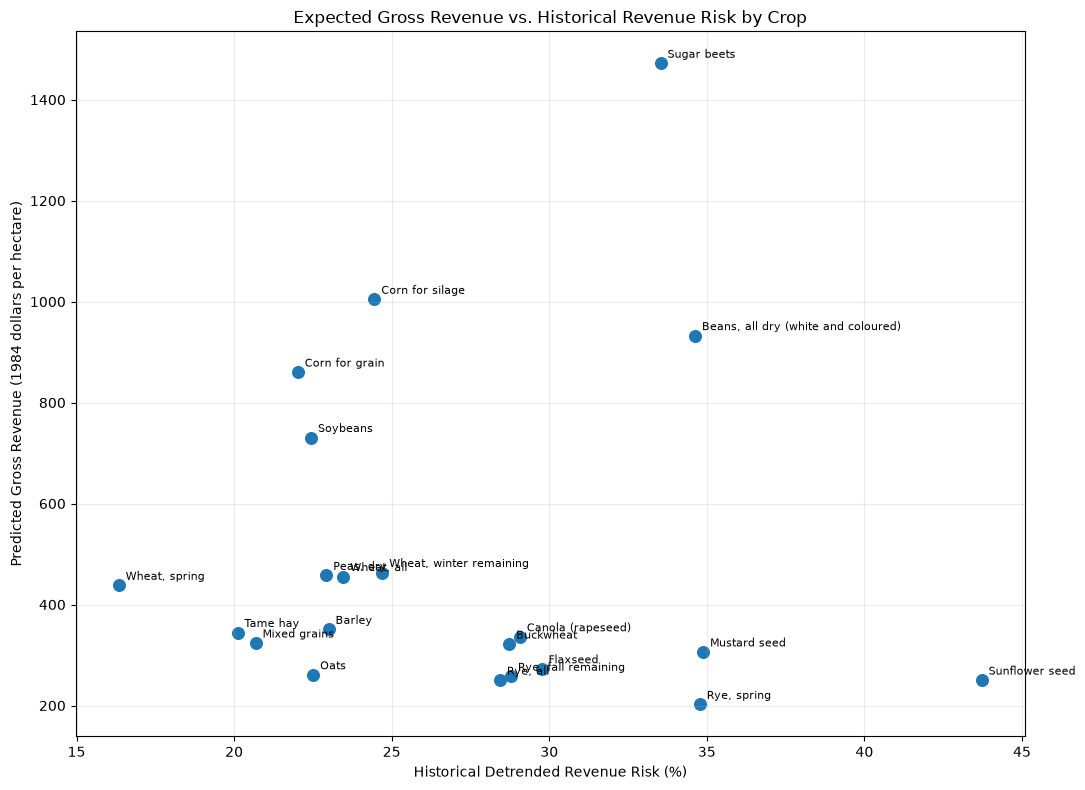

In [167]:
# ============================================================
# Expected Gross Revenue vs Historical Risk
# ============================================================

plt.figure(figsize=(11, 8))

plt.scatter(
    crop_return_risk[
        "Normalized_Risk_%"
    ],
    crop_return_risk[
        "Expected_Revenue_per_ha"
    ],
    s=70
)

for _, row in crop_return_risk.iterrows():

    plt.annotate(
        row["Type of crop"],
        (
            row["Normalized_Risk_%"],
            row[
                "Expected_Revenue_per_ha"
            ]
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(
    "Historical Detrended Revenue Risk (%)"
)

plt.ylabel(
    "Predicted Gross Revenue "
    "(1984 dollars per hectare)"
)

plt.title(
    "Expected Gross Revenue vs. "
    "Historical Revenue Risk by Crop"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Expected Gross Revenue and Historical Risk Findings

The final two-stage system achieved an MAE of $88.07 per hectare and R² of 0.718 when predicting inflation-adjusted gross revenue during the 1982–1984 test period. Revenue prediction was less accurate than yield prediction alone because errors from both the yield and price components contribute to the final revenue estimate. Crop-level normalized revenue MAE ranged from 9.00% for tame hay to 74.60% for dry beans.

Historical revenue risk also varied substantially across crops. After removing crop-province-specific linear revenue trends, normalized historical risk ranged from 16.34% for spring wheat to 43.72% for sunflower seed. Spring wheat, tame hay, mixed grains, corn for grain, soybeans, oats, peas, and barley exhibited comparatively lower historical variability, while sunflower seed, mustard seed, spring rye, dry beans, and sugar beets exhibited greater variability relative to their historical revenue levels.

Expected gross revenue and historical risk reveal important tradeoffs. Sugar beets produced the highest predicted gross revenue at approximately $1,472 per hectare but also exhibited relatively high historical risk of 33.53%. Corn for silage and corn for grain also produced comparatively high expected revenues, at approximately $1,004 and $860 per hectare respectively, while exhibiting lower normalized historical risk of 24.45% and 22.02%. Spring wheat had substantially lower expected revenue of approximately $438 per hectare but the lowest historical normalized risk at 16.34%.

These results demonstrate why crop comparisons should consider both expected return and historical variability rather than revenue alone. They should not be interpreted as direct planting recommendations because the analysis does not incorporate production costs, soil suitability, crop rotation requirements, demand constraints, or individual farm conditions. In addition, crops represented by relatively few test observations, particularly beans and soybeans, have less stable final-period estimates and should be interpreted cautiously.

In [168]:
# ============================================================
# Add Forecast Accuracy to Final Return-Risk Table
# ============================================================

crop_return_risk = (
    crop_return_risk
    .merge(
        revenue_by_crop[
            [
                "Type of crop",
                "Normalized_MAE_%"
            ]
        ].rename(
            columns={
                "Normalized_MAE_%":
                    "Revenue_Forecast_Error_%"
            }
        ),
        on="Type of crop",
        how="left"
    )
)

final_crop_summary = crop_return_risk[
    [
        "Type of crop",
        "Test_Rows",
        "Expected_Revenue_per_ha",
        "Actual_Test_Revenue_per_ha",
        "Revenue_Forecast_Error_%",
        "Normalized_Risk_%"
    ]
].copy()

display(
    final_crop_summary
    .sort_values(
        "Expected_Revenue_per_ha",
        ascending=False
    )
    .round(2)
)

,Type of crop,Test_Rows,Expected_Revenue_per_ha,Actual_Test_Revenue_per_ha,Revenue_Forecast_Error_%,Normalized_Risk_%
15,Sugar beets,9,1471.95,1108.56,33.24,33.53
5,Corn for silage,21,1004.38,922.85,15.18,24.45
1,"Beans, all dry (white and coloured)",3,932.57,705.01,74.60,34.63
4,Corn for grain,12,860.17,799.31,19.64,22.02
14,Soybeans,3,730.74,663.97,16.47,22.44
20,"Wheat, winter remaining",8,463.40,413.39,23.52,24.70
10,"Peas, dry",9,457.65,483.18,18.78,22.93
18,"Wheat, all",24,455.31,434.15,15.89,23.47
19,"Wheat, spring",24,437.96,417.19,15.15,16.34
0,Barley,24,350.68,339.83,15.17,23.00


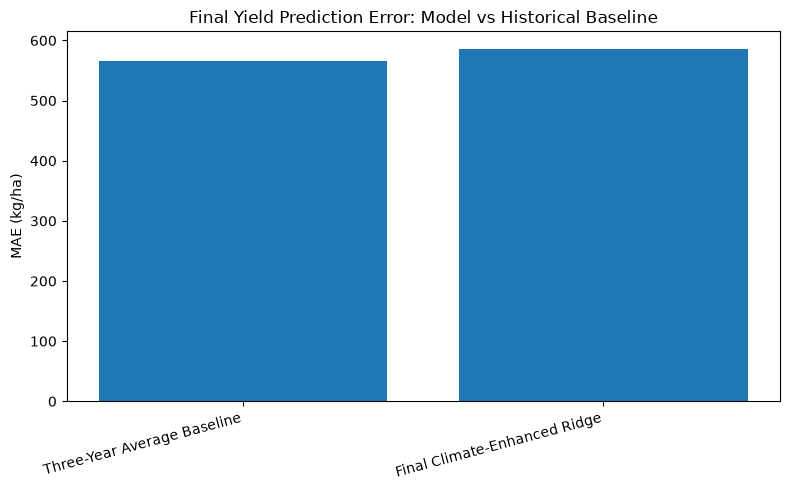

In [169]:
# ============================================================
# Final Yield Model Performance
# ============================================================

yield_plot = final_yield_comparison[
    ["Model", "MAE"]
].sort_values("MAE")

plt.figure(figsize=(8, 5))

plt.bar(
    yield_plot["Model"],
    yield_plot["MAE"]
)

plt.ylabel("MAE (kg/ha)")
plt.title(
    "Final Yield Prediction Error: "
    "Model vs Historical Baseline"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

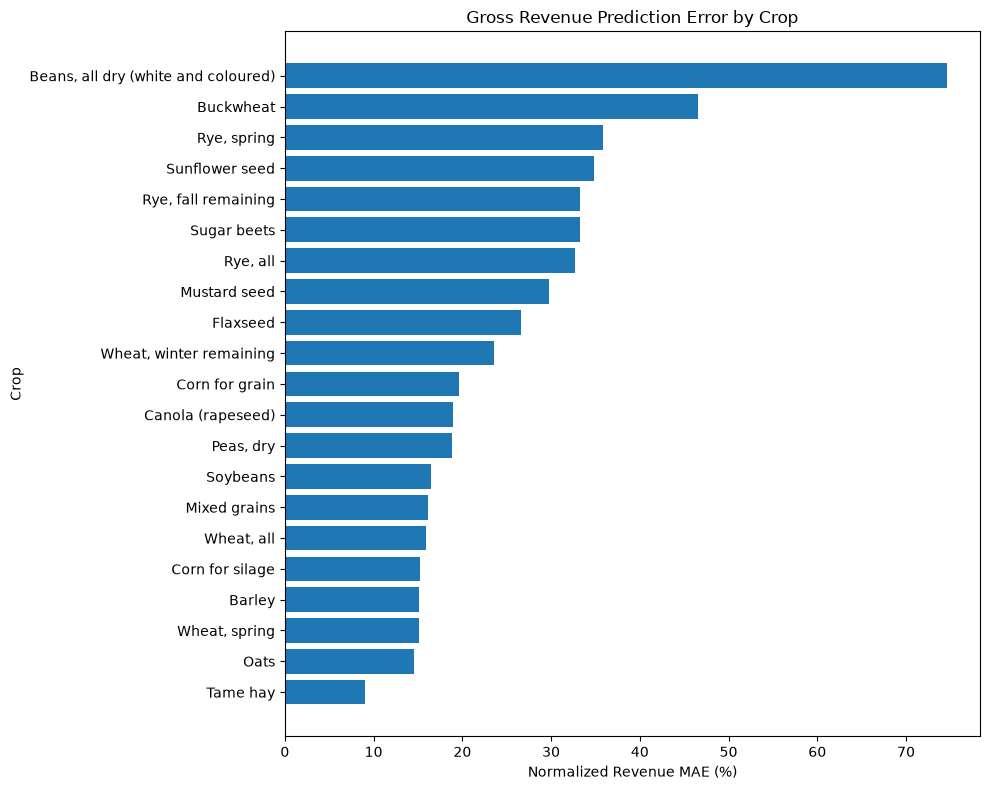

In [170]:
# ============================================================
# Revenue Forecast Error by Crop
# ============================================================

plot_df = (
    revenue_by_crop
    .sort_values(
        "Normalized_MAE_%"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Type of crop"],
    plot_df["Normalized_MAE_%"]
)

plt.xlabel(
    "Normalized Revenue MAE (%)"
)

plt.ylabel("Crop")

plt.title(
    "Gross Revenue Prediction Error by Crop"
)

plt.tight_layout()
plt.show()

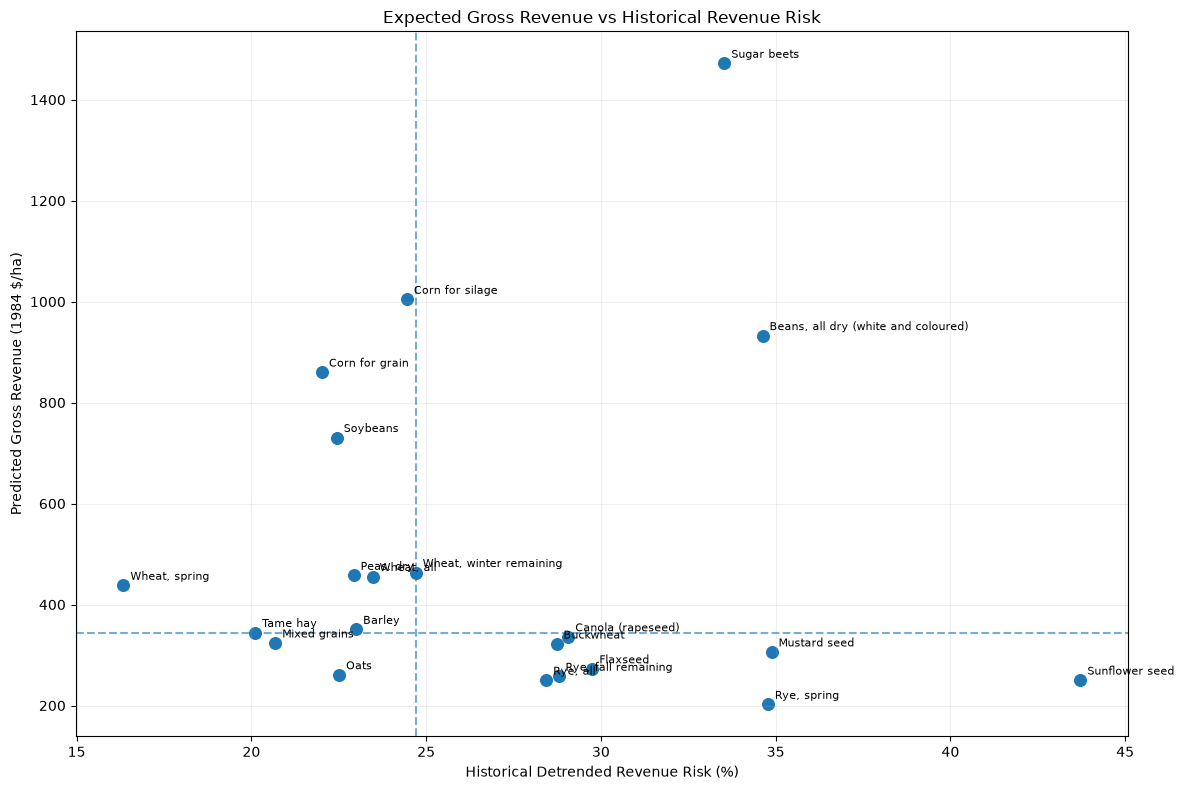

In [171]:
# ============================================================
# Expected Revenue vs Historical Risk
# ============================================================

median_risk = (
    crop_return_risk[
        "Normalized_Risk_%"
    ].median()
)

median_revenue = (
    crop_return_risk[
        "Expected_Revenue_per_ha"
    ].median()
)

plt.figure(figsize=(12, 8))

plt.scatter(
    crop_return_risk[
        "Normalized_Risk_%"
    ],
    crop_return_risk[
        "Expected_Revenue_per_ha"
    ],
    s=70
)

plt.axvline(
    median_risk,
    linestyle="--",
    alpha=0.6
)

plt.axhline(
    median_revenue,
    linestyle="--",
    alpha=0.6
)

for _, row in crop_return_risk.iterrows():

    plt.annotate(
        row["Type of crop"],
        (
            row["Normalized_Risk_%"],
            row[
                "Expected_Revenue_per_ha"
            ]
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(
    "Historical Detrended Revenue Risk (%)"
)

plt.ylabel(
    "Predicted Gross Revenue "
    "(1984 $/ha)"
)

plt.title(
    "Expected Gross Revenue vs "
    "Historical Revenue Risk"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Business Conclusions

This project developed and evaluated a two-stage framework for estimating crop yield, inflation-adjusted farm price, expected gross revenue per hectare, and historical revenue risk using Canadian agricultural and climate data from 1961–1984.

### 1. Historical yield is highly informative, while climate provides additional predictive value

Recent crop-province yield history was one of the strongest sources of predictive information. Adding growing-season climate variables improved Ridge Regression validation MAE by approximately 4.8% compared with the historical-only Ridge specification, demonstrating that temperature and precipitation conditions provide useful additional information during the growing season.

After chronological tuning, the climate-enhanced Ridge model achieved a validation MAE of 579.44 kg/ha and R² of 0.973. On the untouched 1982–1984 test period, it achieved an MAE of 585.85 kg/ha and R² of 0.977.

However, the simple three-year historical yield baseline slightly outperformed the machine-learning model on the final test period. This demonstrates that recent historical agricultural performance is extremely difficult to improve upon consistently and highlights the importance of comparing machine-learning systems with strong simple baselines.

### 2. Inflation adjustment fundamentally changes the interpretation of farm-price trends

Nominal farm prices showed strong positive historical trends across nearly every crop. After adjustment using Canada's all-items CPI, most of these trends became weak or disappeared. This indicates that much of the apparent long-term increase in farm prices reflected general inflation rather than crop-specific real-price growth.

Modeling inflation-adjusted prices therefore produced a more meaningful economic target and prevented models from receiving artificial predictive performance simply by learning historical inflation.

### 3. Simple price persistence outperformed more complex machine-learning approaches

The previous year's inflation-adjusted farm price outperformed Ridge Regression, Random Forest, and Gradient Boosting during validation. Hyperparameter tuning did not reverse this result, so the previous-year real price was retained as the final price forecasting strategy.

On the final test period, this approach achieved an MAE of $29.69 per tonne and R² of 0.673. Price performance varied considerably across crops, demonstrating that market-price uncertainty remains an important limitation of revenue forecasting.

### 4. Revenue forecasting compounds uncertainty from both modeling stages

Combining predicted yield and predicted real farm price produced a final gross-revenue MAE of $88.07 per hectare and R² of 0.718 during 1982–1984.

Revenue accuracy differed substantially across crops. Normalized MAE ranged from 9.00% for tame hay to 74.60% for dry beans. In several cases, large revenue errors corresponded more strongly with difficulty forecasting price than with difficulty estimating yield, demonstrating that production uncertainty is only one component of agricultural revenue uncertainty.

### 5. Expected revenue should be considered together with historical risk

Historical risk was measured using the standard deviation of detrended real gross-revenue residuals and normalized by each crop's historical mean revenue. This preserved the observed joint behavior of yield and price while preventing long-term trends from being mistaken for volatility.

Normalized historical risk ranged from 16.34% for spring wheat to 43.72% for sunflower seed. High expected revenue did not necessarily imply low historical risk. For example, sugar beets had the highest predicted gross revenue but also exhibited relatively high historical variability, while corn for grain combined comparatively high expected revenue with lower historical normalized risk.

The results therefore support evaluating crops along multiple dimensions—including expected gross revenue, historical variability, and forecast reliability—rather than using predicted revenue alone.

## Limitations and Future Work

Several limitations should be considered when interpreting the results.

First, the final modeling period covers 1961–1984. Agricultural technology, crop varieties, management practices, climate conditions, government programs, and commodity markets have changed substantially since this period. The results demonstrate the modeling framework and historical relationships in the available data but should not be treated as current farm forecasts without retraining on modern observations.

Second, the climate-enhanced yield model uses realized May–September weather from the same growing season. It should therefore be interpreted as an in-season yield estimation model rather than a purely pre-plant forecasting system. A production deployment intended for planting decisions would require seasonal weather forecasts or climate scenarios in place of realized future weather.

Third, climate measurements were represented using available weather stations mapped to provinces. This simplifies substantial within-province geographic variation, particularly in large agricultural provinces.

Fourth, Prince Edward Island could not be included in climate-enhanced modeling because the climate dataset did not contain a directly representative station. Historical risk calculations could still use its agricultural observations because climate predictors were not required for that analysis.

Fifth, farm-price forecasting remained substantially more uncertain than yield estimation for several crops. Additional economic predictors such as commodity futures, inventories, exchange rates, international production, input markets, and trade conditions could improve future price models.

Finally, the financial outcome modeled in this project is gross revenue rather than profit. Production costs, labor, fertilizer, machinery, transportation, insurance, land costs, crop rotation requirements, and other farm-specific constraints were unavailable. Consequently, crops with higher predicted gross revenue should not automatically be interpreted as more profitable or preferable planting choices.

Future work should incorporate more recent agricultural and climate data, richer market variables, production-cost information, more spatially detailed weather observations, and probabilistic forecasts that directly quantify uncertainty around future yield, price, and revenue.